In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import trange,tqdm
import matplotlib.pyplot as plt
from math import ceil
import scipy
import scipy.signal
import itertools
import sys, os
import scipy.stats as sts
from scipy.stats import sem
from sklearn.linear_model import Ridge, LogisticRegression
from scipy.stats import pearsonr, sem
import pickle
import numpy.random as npr
import matplotlib.pyplot as plt
import ssm
from ssm.util import find_permutation
import pandas as pd
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
import ast
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import KFold
from joblib import Parallel, delayed
from contextlib import contextmanager
from tqdm import tqdm
from itertools import product

In [2]:
with open('C:/Users/shahe/PycharmProjects/distributed_SD/Data/predicted_trial_SVM_res_04_04.pkl', 'rb') as f:
    data_neural = pickle.load(f)

In [3]:
def map_predicted_labels_to_raw(data_list):
    new_data_list = []
    for df in data_list:
        # Build mappings from labels to raw values
        color_map = (
            df.dropna(subset=['color', 'color_raw'])
              .drop_duplicates(subset=['color'])
              .set_index('color')['color_raw']
              .to_dict()
        )
        direction_map = (
            df.dropna(subset=['direction', 'direction_raw'])
              .drop_duplicates(subset=['direction'])
              .set_index('direction')['direction_raw']
              .to_dict()
        )
        prev_color_map = (
            df.dropna(subset=['previous_color', 'previous_color_raw'])
              .drop_duplicates(subset=['previous_color'])
              .set_index('previous_color')['previous_color_raw']
              .to_dict()
        )
        prev_direction_map = (
            df.dropna(subset=['previous_direction', 'previous_direction_raw'])
              .drop_duplicates(subset=['previous_direction'])
              .set_index('previous_direction')['previous_direction_raw']
              .to_dict()
        )

        # Define which mappings apply to which predicted variables
        mapping_dict = {
            'predicted_color': color_map,
            'predicted_direction': direction_map,
            'predicted_previous_color': prev_color_map,
            'predicted_previous_direction': prev_direction_map,
        }

        # Collect all new columns in a dict
        new_cols = {}
        for col in df.columns:
            for key, mapping in mapping_dict.items():
                if col.startswith(key):
                    new_cols[col + '_raw'] = df[col].map(mapping)

        # Concatenate all at once
        if new_cols:
            df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

        # Optional: defragment memory (creates a clean copy)
        df = df.copy()
        new_data_list.append(df)

    return new_data_list
mapped_data = map_predicted_labels_to_raw(data_neural)
data_neural = mapped_data

In [4]:

# --- helpers ---
def zscore(s: pd.Series) -> pd.Series:
    """Fast z-score that preserves index and avoids divide-by-zero."""
    m = s.mean()
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return (s - m)  # all zeros; fine for downstream use
    return (s - m) / sd


# --- main processing ---
def process_session_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Process a single session DataFrame.
    Cleans and adds derived variables for analysis with zero fragmentation.
    """
    df = df.copy()
    idx = df.index
    new = {}  # collect ALL new columns here (as Series aligned to idx)

    # ---------- Basic columns ----------
    new['intercept'] = pd.Series(1, index=idx)

    color_z  = zscore(df['color_raw'])
    direc_z  = zscore(df['direction_raw'])
    new['color_z_b']     = color_z
    new['direction_z_b'] = direc_z

    new['p_color_z_b']     = color_z.shift(1).fillna(0)
    new['p_direction_z_b'] = direc_z.shift(1).fillna(0)

    new['dist_prev_current_color']  = (color_z - new['p_color_z_b']).abs()
    new['dist_prev_current_motion'] = (direc_z - new['p_direction_z_b']).abs()

    resp = df['chosenResponse'].fillna(0).astype(int)
    new['response']        = resp
    new['prev_response_b'] = resp.shift(1).fillna(0)

    # Context: map {1->1, 0->-1}
    ctx_b = df['rule'].astype(int).map({1: 1, 0: -1}).fillna(-1)
    new['context_b'] = ctx_b

    new['context_color_b']  = color_z * ctx_b
    new['context_motion_b'] = direc_z * ctx_b

    # Use Series.where so we preserve index (avoid np.where)
    rel_b = color_z.where(ctx_b == 1, direc_z)
    irr_b = direc_z.where(ctx_b == 1, color_z)
    new['relevant_b']   = rel_b
    new['irrelevant_b'] = irr_b
    new['prev_rel_b']   = rel_b.shift(1).fillna(0)
    new['prev_irr_b']   = irr_b.shift(1).fillna(0)

    # Cue one-hots (compact dtype)
    cue_dummies = pd.get_dummies(df['cue'], prefix='cue', drop_first=False).astype('int8')
    cue_dummies = cue_dummies.reindex(idx, fill_value=0)

    # ---------- per-area helper ----------
    def add_area(area: str):
        base = 'predicted_'
        need = [
            f'{base}color_{area}_raw', f'{base}direction_{area}_raw',
            f'{base}previous_color_{area}_raw', f'{base}previous_direction_{area}_raw',
            f'{base}response_{area}', f'{base}previous_response_{area}',
            f'{base}context_response_{area}',
        ]
        if not all(c in df.columns for c in need):
            return

        color  = zscore(df[f'{base}color_{area}_raw'])
        direc  = zscore(df[f'{base}direction_{area}_raw'])
        pcolor = zscore(df[f'{base}previous_color_{area}_raw'])
        pdirec = zscore(df[f'{base}previous_direction_{area}_raw'])

        ctx = df[f'{base}context_response_{area}'].map({1: 1, 0: -1})
        prev_ctx = ctx.shift(1)

        # assign as Series (aligned)
        new[f'color_{area}']       = color
        new[f'direction_{area}']   = direc
        new[f'p_color_{area}']     = pcolor
        new[f'p_direction_{area}'] = pdirec

        new[f'decodedResponse_{area}'] = df[f'{base}response_{area}']
        new[f'prev_response_{area}']   = df[f'{base}previous_response_{area}'].fillna(0)

        new[f'context_{area}']      = ctx
        new[f'prev_context_{area}'] = prev_ctx

        new[f'context_color_{area}']  = color * ctx
        new[f'context_motion_{area}'] = direc * ctx

        rel = color.where(ctx == 1, direc)
        irr = direc.where(ctx == 1, color)
        new[f'relevant_{area}']   = rel
        new[f'irrelevant_{area}'] = irr
        new[f'prev_rel_{area}']   = rel.shift(1).fillna(0)
        new[f'prev_irr_{area}']   = irr.shift(1).fillna(0)

    # Add all areas you use
    for area in ['PFC', 'FEF', 'LIP', 'V4', 'MT', 'IT', 'Parietal']:
        add_area(area)

    # ---------- build new_df in ONE concat (no column-by-column inserts) ----------
    series_list = []
    for k, v in new.items():
        s = v if isinstance(v, pd.Series) else pd.Series(v, index=idx)
        if not s.index.equals(idx):
            s = s.reindex(idx)
        series_list.append(s.rename(k))
    new_df = pd.concat(series_list, axis=1)

    # ---------- final join (single concat) ----------
    out = pd.concat([df, new_df, cue_dummies], axis=1)

    # Optional: defragment memory (creates a compact copy)
    return out.copy()


# --- usage example ---
processed_data_neural = [process_session_data(df) for df in data_neural]



In [5]:
# ------------------------------------------------------------
# Assumes `process_session_data(df)` is already defined above.
# ------------------------------------------------------------

AREA_LIST = ['FEF', 'PFC', 'LIP', 'Parietal', 'V4', 'MT', 'IT']

# ---------- Feature builders (edit here to add/remove predictors) ----------

def build_X_behavior(df: pd.DataFrame) -> np.ndarray:
    """Behavior-only design matrix (negated features as in your code)."""
    relevant_b      = -df[['relevant_b']].fillna(0).to_numpy()
    irrelevant_b    = -df[['irrelevant_b']].fillna(0).to_numpy()
    prev_rel_b      = -df[['prev_rel_b']].fillna(0).to_numpy()
    prev_irr_b      = -df[['prev_irr_b']].fillna(0).to_numpy()
    prev_response_b = -df[['prev_response_b']].fillna(0).to_numpy()
    bias            = -df[['intercept']].fillna(0).to_numpy()
    X = np.hstack([
        relevant_b, irrelevant_b,
        prev_rel_b, prev_irr_b,
        prev_response_b,
        bias
    ])
    return X

def build_X_neural(df: pd.DataFrame, area: str) -> np.ndarray:
    """Neural-only design matrix for an area (relevant/irrelevant/prev & prev_response + bias)."""
    relevant      = -df[[f'relevant_{area}']].fillna(0).to_numpy()
    irrelevant    = -df[[f'irrelevant_{area}']].fillna(0).to_numpy()
    prev_rel      = -df[[f'prev_rel_{area}']].fillna(0).to_numpy()
    prev_irr      = -df[[f'prev_irr_{area}']].fillna(0).to_numpy()
    prev_response = -df[[f'prev_response_{area}']].fillna(0).to_numpy()
    bias          = -df[['intercept']].fillna(0).to_numpy()
    X = np.hstack([
        relevant, irrelevant,
        prev_rel, prev_irr,
        prev_response,
        bias
    ])
    return X

def build_X_combined(df: pd.DataFrame, area: str) -> np.ndarray:
    """Combined behavior + neural (bias only once at the end)."""
    # Behavior (without bias)
    relevant_b      = -df[['relevant_b']].fillna(0).to_numpy()
    irrelevant_b    = -df[['irrelevant_b']].fillna(0).to_numpy()
    prev_rel_b      = -df[['prev_rel_b']].fillna(0).to_numpy()
    prev_irr_b      = -df[['prev_irr_b']].fillna(0).to_numpy()
    prev_response_b = -df[['prev_response_b']].fillna(0).to_numpy()

    # Neural (without bias)
    relevant      = -df[[f'relevant_{area}']].fillna(0).to_numpy()
    irrelevant    = -df[[f'irrelevant_{area}']].fillna(0).to_numpy()
    prev_rel      = -df[[f'prev_rel_{area}']].fillna(0).to_numpy()
    prev_irr      = -df[[f'prev_irr_{area}']].fillna(0).to_numpy()
    prev_response = -df[[f'prev_response_{area}']].fillna(0).to_numpy()

    bias          = -df[['intercept']].fillna(0).to_numpy()

    X = np.hstack([
        # behavior
        relevant_b, irrelevant_b, prev_rel_b, prev_irr_b, prev_response_b,
        # neural
        relevant,   irrelevant,   prev_rel,   prev_irr,   prev_response,
        # single bias
        bias
    ])
    return X

# ---------- Utilities ----------

def y_from_df(df: pd.DataFrame) -> np.ndarray:
    """Binary response as (T,1)."""
    return df['chosenResponse'].fillna(0).astype(int).to_numpy().reshape(-1, 1)

def sessions_with_area(processed_sessions, area: str):
    """Filter sessions that contain the required columns for an area."""
    required = {
        f'relevant_{area}', f'irrelevant_{area}',
        f'prev_rel_{area}', f'prev_irr_{area}',
        f'prev_response_{area}',
        'intercept'
    }
    keep = []
    idxs = []
    for i, df in enumerate(processed_sessions):
        if required.issubset(set(df.columns)):
            keep.append(df)
            idxs.append(i)
    return keep, idxs

def prepare_sessionwise(dfs, X_builder, y_builder=y_from_df):
    """Return session-wise inpts, true_choices, and lengths with a builder function."""
    inpts, true_choices, lengths = [], [], []
    for df in dfs:
        X = X_builder(df)
        y = y_builder(df)
        inpts.append(X)
        true_choices.append(y)
        lengths.append(len(df))
    return inpts, true_choices, lengths

# ---------- Driver that produces all variants you asked for ----------

def build_all_glmhmm_inputs(data_neural_raw, areas=AREA_LIST):
    """
    Returns a results dict with:
      - behavior_all: inpts/y/lengths across ALL sessions
      - per area:
          - indices: indices of original sessions that had that area
          - behavior_matched: behavior-only inpts/y/lengths for those sessions
          - neural: neural-only inpts/y/lengths
          - combined: behavior+neural inpts/y/lengths (only sessions with that area's neural)
    """
    # 1) process all sessions once
    processed_sessions = [process_session_data(df) for df in data_neural_raw]

    # 2) behavior-only across ALL sessions (for global comparison)
    beh_inpts_all, beh_y_all, beh_len_all = prepare_sessionwise(
        processed_sessions, build_X_behavior, y_from_df
    )

    results = {
        'behavior_all': {
            'inpts': beh_inpts_all,
            'true_choices': beh_y_all,
            'session_lengths': beh_len_all,
            'indices': list(range(len(processed_sessions)))
        },
        'areas': {}
    }

    # 3) per-area matched behavior/neural/combined
    for area in areas:
        area_sessions, idxs = sessions_with_area(processed_sessions, area)
        if not area_sessions:
            results['areas'][area] = {
                'indices': [],
                'behavior_matched': {'inpts': [], 'true_choices': [], 'session_lengths': []},
                'neural': {'inpts': [], 'true_choices': [], 'session_lengths': []},
                'combined': {'inpts': [], 'true_choices': [], 'session_lengths': []},
            }
            continue

        # behavior-only but matched to the sessions that have this area's neural data
        beh_inpts, beh_y, beh_len = prepare_sessionwise(area_sessions, build_X_behavior, y_from_df)

        # neural-only for this area
        neu_inpts, neu_y, neu_len = prepare_sessionwise(
            area_sessions, lambda df, a=area: build_X_neural(df, a), y_from_df
        )

        # combined behavior + area neural
        com_inpts, com_y, com_len = prepare_sessionwise(
            area_sessions, lambda df, a=area: build_X_combined(df, a), y_from_df
        )

        results['areas'][area] = {
            'indices': idxs,  # original session indices kept for this area
            'behavior_matched': {
                'inpts': beh_inpts,
                'true_choices': beh_y,
                'session_lengths': beh_len
            },
            'neural': {
                'inpts': neu_inpts,
                'true_choices': neu_y,
                'session_lengths': neu_len
            },
            'combined': {
                'inpts': com_inpts,
                'true_choices': com_y,
                'session_lengths': com_len
            },
        }

    return results

# ------------------------------
# Example usage:
# ------------------------------
results = build_all_glmhmm_inputs(data_neural)
# Access examples:
# - Global behavior across all sessions:
#results['behavior_all']['inpts'], results['behavior_all']['true_choices']
# - For LIP:
#     results['areas']['LIP']['indices']                # which sessions are valid for LIP
#     results['areas']['LIP']['behavior_matched']['inpts']
#     results['areas']['LIP']['neural']['inpts']
#     results['areas']['LIP']['combined']['inpts']


In [22]:
LOG2 = np.log(2.0)

# -----------------------------
# MLE fit for a single (fold, K, init)
# -----------------------------
def MLE_hmm_fit(num_states, training_inpts, training_choices, test_inpts, test_choices, seed=None):
    """
    Fit a GLM-HMM and return the fitted model + train/test log-likelihood
    in **bits per trial**.
    training_* and test_* are lists (one per session).
    """
    if seed is not None:
        np.random.seed(seed)

    # Ensure shapes/dtypes
    training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
    test_choices     = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

    num_categories = len(np.unique(np.concatenate(training_choices)))
    input_dim = training_inpts[0].shape[1]

    # 1 state: standard transitions; >1 state: sticky transitions
    if num_states == 1:
        hmm = ssm.HMM(
            K=1,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="standard",
        )
    else:
        hmm = ssm.HMM(
            K=num_states,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="sticky",
            transition_kwargs=dict(alpha=2.0, kappa=0.0),
        )

    train_lls = hmm.fit(
        training_choices,
        inputs=training_inpts,
        method="em",
        num_iters=3000,
        tolerance=1e-3,
    )

    n_train = np.concatenate(training_inpts).shape[0]
    n_test  = np.concatenate(test_inpts).shape[0]

    # Convert from nats/trial → bits/trial
    train_bpt = (train_lls[-1] / n_train) / LOG2
    test_bpt  = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2

    return hmm, train_bpt, test_bpt


# -----------------------------
# TQDM helper for joblib
# -----------------------------
@contextmanager
def tqdm_joblib(tqdm_object):
    from joblib import parallel
    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_callback = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# -----------------------------
# Utilities for model selection
# -----------------------------
def plateau(data_1d, threshold=0.001):
    """
    Given a 1D array of scores over K, return the K at which the last
    improvement above threshold occurs; if none, return 1.
    """
    data_1d = np.asarray(data_1d, dtype=float)
    diffs = np.diff(data_1d)
    idx = np.where(diffs > threshold)[0]
    return int(idx[np.argmax(data_1d[idx + 1])] + 1) if idx.size > 0 else 1

def sign_flip_pvalue(diffs):
    """
    Exact two-sided sign-flip test for the mean of paired differences.
    diffs: per-fold differences (K+1 - K) in bits/trial.
    """
    from itertools import product
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    n = diffs.size
    if n == 0:
        return np.nan
    t_obs = np.abs(np.mean(diffs))
    count = 0
    total = 0
    for signs in product([-1.0, 1.0], repeat=n):
        total += 1
        t = np.abs(np.mean(diffs * np.array(signs)))
        if t >= t_obs - 1e-15:
            count += 1
    return count / total

def holm_bonferroni(pvals, alpha=0.05):
    pvals = np.array(pvals, dtype=float)
    m = np.sum(np.isfinite(pvals))
    if m == 0:
        return np.zeros_like(pvals, dtype=bool), pvals
    order = np.argsort(np.where(np.isfinite(pvals), pvals, np.inf))
    reject = np.zeros_like(pvals, dtype=bool)
    adj_p = np.full_like(pvals, np.nan, dtype=float)
    for rank, idx in enumerate(order, start=1):
        if not np.isfinite(pvals[idx]):
            continue
        threshold = alpha / (m - rank + 1)
        if pvals[idx] <= threshold:
            reject[idx] = True
        adj_p[idx] = max((m - rank + 1) * pvals[idx], 0.0)
    # enforce monotonicity (cosmetic)
    last = -np.inf
    for idx in order:
        if np.isfinite(adj_p[idx]):
            adj_p[idx] = max(adj_p[idx], last)
            last = adj_p[idx]
    return reject, adj_p


# -----------------------------
# Core CV runner for one dataset (behavior / neural / combined)
# -----------------------------
def run_glmhmm_cv(inpts, true_choices, max_states=4, n_splits=5, initializations=5, base_seed=42, n_jobs=-1, desc="GLM-HMM CV"):
    """
    Run K-fold CV over K=1..max_states with multiple random initializations per fold.
    Returns:
        dict with:
            Best_HMM       : (max_states, n_splits) object array of best-per-fold HMMs
            Best_test_LL   : (max_states, n_splits) bits/trial (best init per fold)
            Best_train_LL  : (max_states, n_splits) bits/trial
            AllInits_test_LL: (initializations, max_states, n_splits) bits/trial
            selection      : dict with K* by various criteria
            summary        : means/SEMs per K
    """
    nsess = len(inpts)
    if nsess < 2:
        raise ValueError(f"Need at least 2 sessions for CV; got {nsess}")
    # Adapt n_splits if needed
    n_splits = min(n_splits, nsess)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=base_seed)

    Best_HMM = np.full((max_states, n_splits), None, dtype=object)
    Best_train_LL = np.full((max_states, n_splits), np.nan, dtype=float)
    Best_test_LL = np.full((max_states, n_splits), np.nan, dtype=float)
    AllInits_test_LL = np.full((initializations, max_states, n_splits), np.nan, dtype=float)

    # Build job list
    jobs = []
    for fold_id, (train_idx, test_idx) in enumerate(kf.split(true_choices)):
        training_choices = [true_choices[i] for i in train_idx]
        test_choices     = [true_choices[i] for i in test_idx]
        training_inpts   = [inpts[i] for i in train_idx]
        test_inpts       = [inpts[i] for i in test_idx]
        for K in range(1, max_states + 1):
            for z in range(initializations):
                seed = base_seed * 100_000 + 10_000 * fold_id + 100 * K + z
                jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

    def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
        hmm, tr_ll, te_ll = MLE_hmm_fit(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
        return fold_id, K, z, hmm, tr_ll, te_ll

    with tqdm_joblib(tqdm(total=len(jobs), desc=desc)):
        results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(_run_one)(*args) for args in jobs
        )

    for fold_id, K, z, hmm, tr_ll, te_ll in results:
        AllInits_test_LL[z, K - 1, fold_id] = te_ll
        if np.isnan(Best_test_LL[K - 1, fold_id]) or te_ll > Best_test_LL[K - 1, fold_id]:
            Best_test_LL[K - 1, fold_id] = te_ll
            Best_train_LL[K - 1, fold_id] = tr_ll
            Best_HMM[K - 1, fold_id] = hmm

    # Selection stats over K
    mean_bpt = np.nanmean(Best_test_LL, axis=1)  # (K,)
    sem_bpt  = np.nanstd(Best_test_LL, axis=1, ddof=1) / np.sqrt(
        np.maximum(1, np.sum(np.isfinite(Best_test_LL), axis=1))
    )

    K_max = int(np.nanargmax(mean_bpt)) + 1
    K_plateau = plateau(mean_bpt)

    # 1-SE rule
    best_val = mean_bpt[K_max - 1]
    best_se  = sem_bpt[K_max - 1]
    eligible = np.where(mean_bpt >= (best_val - best_se))[0]
    K_1se = int(eligible[0]) + 1 if eligible.size else K_max

    # Exact sign-flip tests for consecutive pairs
    raw_p = []
    for k in range(max_states - 1):
        diffs = Best_test_LL[k + 1, :] - Best_test_LL[k, :]
        mask = np.isfinite(diffs)
        p = sign_flip_pvalue(diffs[mask]) if np.sum(mask) >= 1 else np.nan
        raw_p.append(p)
    reject_holm, p_adj_holm = holm_bonferroni(raw_p, alpha=0.05)
    sig_pairs = np.where(reject_holm)[0]
    K_last_sig = int(sig_pairs.max() + 2) if sig_pairs.size > 0 else 1

    selection = {
        "K_max": K_max,
        "K_plateau": K_plateau,
        "K_1se": K_1se,
        "K_last_sig": K_last_sig,
        "mean_bpt": mean_bpt,
        "sem_bpt": sem_bpt,
        "raw_p": np.array(raw_p),
        "reject_holm": reject_holm,
        "p_adj_holm": p_adj_holm,
    }

    return {
        "Best_HMM": Best_HMM,
        "Best_test_LL": Best_test_LL,
        "Best_train_LL": Best_train_LL,
        "AllInits_test_LL": AllInits_test_LL,
        "selection": selection,
        "meta": {
            "max_states": max_states,
            "n_splits": n_splits,
            "initializations": initializations,
            "nsessions": nsess,
        }
    }


# -----------------------------
# High-level driver over all areas + behavior
# -----------------------------
def evaluate_all_areas(results_from_builder,
                       areas=("FEF","PFC","LIP","Parietal","V4","MT","IT"),
                       max_states=4, n_splits=5, initializations=5, base_seed=42, n_jobs=-1):
    """
    results_from_builder: dict returned by build_all_glmhmm_inputs(data_neural)
    Returns a dict with CV outcomes for:
        - behavior_all (all sessions)
        - per area: behavior_matched, neural, combined
    """
    out = {"behavior_all": None, "areas": {}}

    # Behavior across ALL sessions
    beh_all = results_from_builder['behavior_all']
    out["behavior_all"] = run_glmhmm_cv(
        beh_all['inpts'], beh_all['true_choices'],
        max_states=max_states, n_splits=n_splits,
        initializations=initializations, base_seed=base_seed,
        n_jobs=n_jobs, desc="CV: Behavior (ALL)"
    )

    # Per area
    for area in areas:
        block = results_from_builder['areas'].get(area, None)
        if block is None or len(block['indices']) == 0:
            out["areas"][area] = {
                "indices": [],
                "behavior_matched": None,
                "neural": None,
                "combined": None,
            }
            continue

        # Behavior matched to this area's sessions
        beh = block['behavior_matched']
        neu = block['neural']
        com = block['combined']

        area_out = {"indices": block['indices']}
        area_out["behavior_matched"] = run_glmhmm_cv(
            beh['inpts'], beh['true_choices'],
            max_states=max_states, n_splits=n_splits,
            initializations=initializations, base_seed=base_seed,
            n_jobs=n_jobs, desc=f"CV: Behavior (matched {area})"
        )
        area_out["neural"] = run_glmhmm_cv(
            neu['inpts'], neu['true_choices'],
            max_states=max_states, n_splits=n_splits,
            initializations=initializations, base_seed=base_seed,
            n_jobs=n_jobs, desc=f"CV: Neural ({area})"
        )
        area_out["combined"] = run_glmhmm_cv(
            com['inpts'], com['true_choices'],
            max_states=max_states, n_splits=n_splits,
            initializations=initializations, base_seed=base_seed,
            n_jobs=n_jobs, desc=f"CV: Combined ({area})"
        )

        out["areas"][area] = area_out

    return out


In [ ]:
# 1) Build session-wise inputs
builder_results = build_all_glmhmm_inputs(data_neural)  # from previous step

# 2) Evaluate across all areas
cv_all = evaluate_all_areas(
    builder_results,
    areas=['FEF','PFC','LIP','Parietal','V4','MT','IT'],
    max_states=8,
    n_splits=3,
    initializations=2,
    base_seed=42,
    n_jobs=-1
)

# Examples of what you get:
# Global behavior (all sessions):
cv_all['behavior_all']['selection']['K_last_sig']   # chosen K by "last significant Δ"
cv_all['behavior_all']['selection']['mean_bpt']     # mean bits/trial by K

# For LIP:
cv_all['areas']['LIP']['indices']                   # kept session indices for LIP
cv_all['areas']['LIP']['neural']['selection']['K_max']
cv_all['areas']['LIP']['combined']['selection']['K_1se']
cv_all['areas']['LIP']['behavior_matched']['selection']['K_plateau']


CV: Behavior (ALL):   0%|          | 0/48 [00:00<?, ?it/s]

CV: Behavior (matched FEF):   0%|          | 0/48 [00:00<?, ?it/s]

CV: Neural (FEF):   0%|          | 0/48 [00:00<?, ?it/s]

In [ ]:
# let's save results
with open('cv_all_results.pkl', 'wb') as f:
    pickle.dump(cv_neural_all_model_slection, f)


In [15]:
with open('C:/Users/shahe/PycharmProjects/Monkey-Project/Behavioural analysis/HMM_GLM_neural_regressors/cv_all_results_neural.pkl', 'rb') as f:
    cv_all = pickle.load(f)


              Dataset  K_max  K_1se  K_last_sig  K_plateau  \
0  Behavior (matched)      4      2           1          2   
1        Neural (LIP)      5      4           1          4   
2            Combined      3      2           1          1   

   mean@K* (bits/trial)  
0             -0.530474  
1             -0.631106  
2             -0.426457  


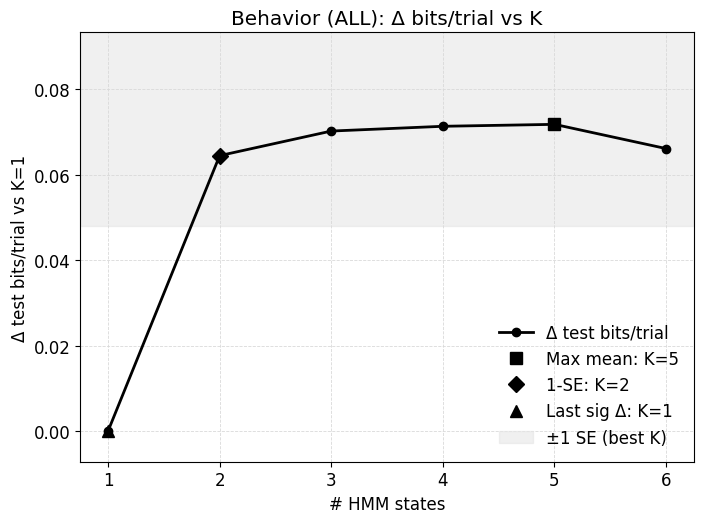

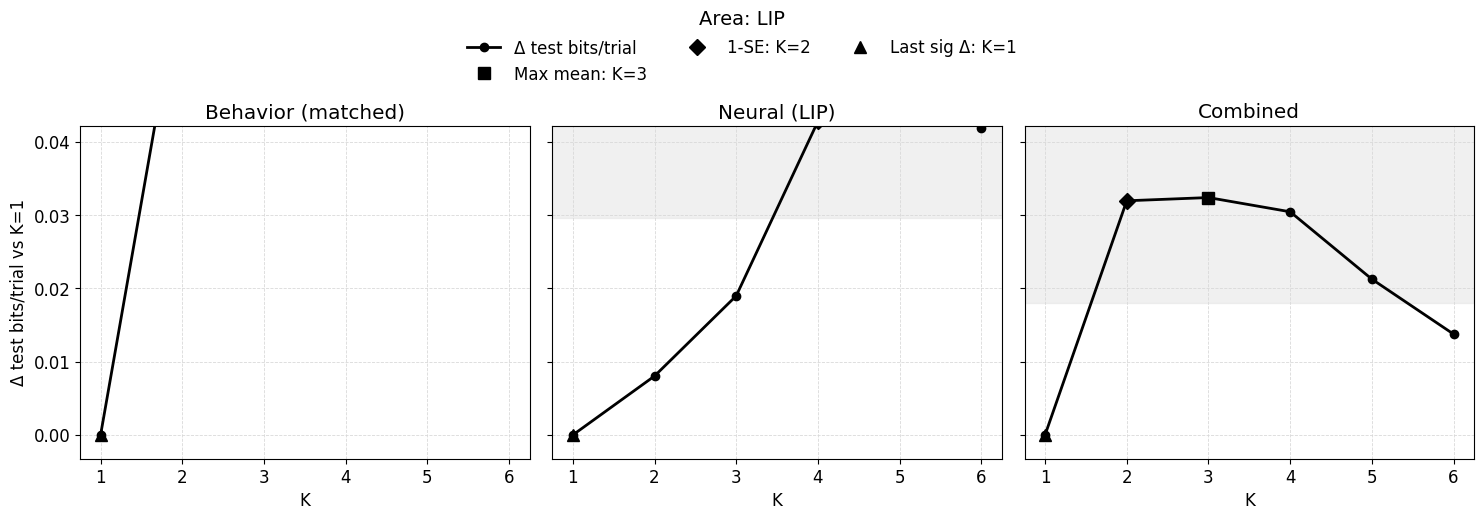

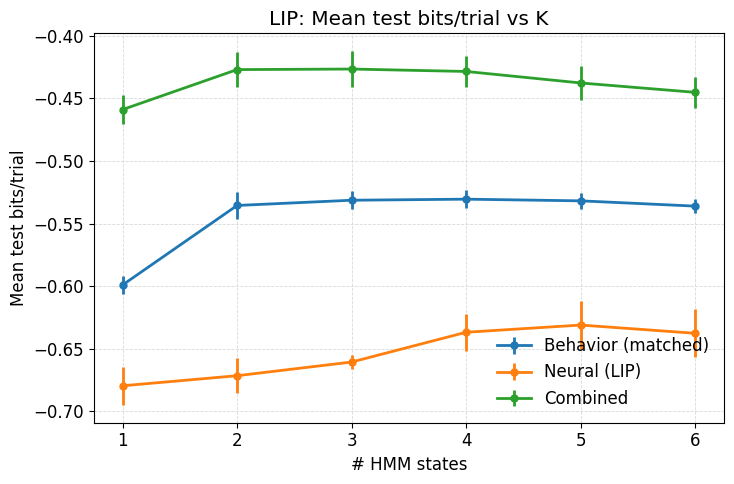

In [16]:
# ---------- helpers ----------
def _summary_from_cvblock(cv_block):
    """Extract Ks, mean_bpt, sem_bpt, delta, and selections from a single cv result block."""
    sel = cv_block["selection"]
    Ks = np.arange(1, cv_block["meta"]["max_states"] + 1)
    mean_bpt = sel["mean_bpt"]
    sem_bpt = sel["sem_bpt"]
    delta = mean_bpt - mean_bpt[0]
    picks = {
        "K_max": sel["K_max"],
        "K_1se": sel["K_1se"],
        "K_last_sig": sel["K_last_sig"],
        "K_plateau": sel["K_plateau"],
        "best_delta": delta[sel["K_max"] - 1],
        "best_se": sem_bpt[sel["K_max"] - 1],
    }
    return Ks, mean_bpt, sem_bpt, delta, picks

def _sig_label_from_p(p):
    if not np.isfinite(p): return "n.s."
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."


# ---------- plot one block (delta vs K) ----------
def plot_cv_block(cv_block, title="Model selection (Δ bits/trial)"):
    Ks, mean_bpt, sem_bpt, delta, picks = _summary_from_cvblock(cv_block)

    # style
    plt.rcParams.update({
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "grid.color": "0.85",
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "font.size": 12,
    })

    fig, ax = plt.subplots(figsize=(7.2, 5.4))

    ax.plot(Ks, delta, marker='o', linestyle='-', linewidth=2, markersize=6, color='black', label='Δ test bits/trial')
    # markers for selections
    ax.plot(picks["K_max"], delta[picks["K_max"] - 1], marker='s', markersize=9, color='black', linestyle='None', label=f'Max mean: K={picks["K_max"]}')
    ax.plot(picks["K_1se"], delta[picks["K_1se"] - 1], marker='D', markersize=8, color='black', linestyle='None', label=f'1-SE: K={picks["K_1se"]}')
    ax.plot(picks["K_last_sig"], delta[picks["K_last_sig"] - 1], marker='^', markersize=9, color='black', linestyle='None', label=f'Last sig Δ: K={picks["K_last_sig"]}')

    # 1-SE band at best K
    ax.axhspan(picks["best_delta"] - picks["best_se"], picks["best_delta"] + picks["best_se"], color='0.9', alpha=0.6, label='±1 SE (best K)')

    # labels & limits
    y_min, y_max = np.nanmin(delta), np.nanmax(delta)
    if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
        y_min, y_max = 0.0, 1.0
    y_range = max(y_max - y_min, 1e-6)
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)
    ax.set_xlabel('# HMM states')
    ax.set_ylabel('Δ test bits/trial vs K=1')
    ax.set_title(title)
    ax.set_xticks(Ks)
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax


# ---------- 3-panel per-area comparison ----------
def plot_area_triptych(area_block, area_name):
    """
    area_block: cv_all['areas'][AREA], which contains three cv blocks:
        - behavior_matched, neural, combined
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
    titles = ['Behavior (matched)', f'Neural ({area_name})', 'Combined']
    keys   = ['behavior_matched', 'neural', 'combined']

    for ax, key, ttl in zip(axes, keys, titles):
        cv_block = area_block.get(key, None)
        if cv_block is None:
            ax.set_axis_off()
            continue
        Ks, mean_bpt, sem_bpt, delta, picks = _summary_from_cvblock(cv_block)

        ax.plot(Ks, delta, marker='o', linestyle='-', linewidth=2, markersize=6, color='black', label='Δ test bits/trial')
        ax.plot(picks["K_max"], delta[picks["K_max"] - 1], marker='s', markersize=9, color='black', linestyle='None', label=f'Max mean: K={picks["K_max"]}')
        ax.plot(picks["K_1se"], delta[picks["K_1se"] - 1], marker='D', markersize=8, color='black', linestyle='None', label=f'1-SE: K={picks["K_1se"]}')
        ax.plot(picks["K_last_sig"], delta[picks["K_last_sig"] - 1], marker='^', markersize=9, color='black', linestyle='None', label=f'Last sig Δ: K={picks["K_last_sig"]}')
        ax.axhspan(picks["best_delta"] - picks["best_se"], picks["best_delta"] + picks["best_se"], color='0.9', alpha=0.6)

        y_min, y_max = np.nanmin(delta), np.nanmax(delta)
        if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
            y_min, y_max = 0.0, 1.0
        y_range = max(y_max - y_min, 1e-6)
        ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

        ax.set_title(ttl)
        ax.set_xlabel('K')
        ax.set_xticks(Ks)
        if key == 'behavior_matched':
            ax.set_ylabel('Δ test bits/trial vs K=1')
        ax.grid(True, linestyle='--', linewidth=0.6, color='0.85')

    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.05))
    fig.suptitle(f'Area: {area_name}', y=1.08, fontsize=14)
    fig.tight_layout()
    return fig, axes


# ---------- overlay mean bits/trial curves (not delta) for a single area ----------
def plot_area_overlay_mean_bpt(area_block, area_name):
    fig, ax = plt.subplots(figsize=(7.5, 5))
    styles = [('behavior_matched', 'Behavior (matched)'), ('neural', f'Neural ({area_name})'), ('combined', 'Combined')]

    for key, label in styles:
        cv_block = area_block.get(key, None)
        if cv_block is None:
            continue
        Ks, mean_bpt, sem_bpt, delta, picks = _summary_from_cvblock(cv_block)
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt='-o', linewidth=2, markersize=5, label=label)

    ax.set_xlabel('# HMM states')
    ax.set_ylabel('Mean test bits/trial')
    ax.set_title(f'{area_name}: Mean test bits/trial vs K')
    ax.grid(True, linestyle='--', linewidth=0.6, color='0.85')
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax


# ---------- simple text table of selected K per dataset ----------
def selection_table_for_area(area_block, area_name):
    rows = []
    for key, label in [('behavior_matched','Behavior (matched)'), ('neural','Neural'), ('combined','Combined')]:
        cv_block = area_block.get(key, None)
        if cv_block is None:
            continue
        sel = cv_block['selection']
        rows.append({
            'Dataset': label if label != 'Neural' else f'Neural ({area_name})',
            'K_max': sel['K_max'],
            'K_1se': sel['K_1se'],
            'K_last_sig': sel['K_last_sig'],
            'K_plateau': sel['K_plateau'],
            'mean@K* (bits/trial)': round(sel['mean_bpt'][sel['K_max'] - 1], 6),
        })
    return pd.DataFrame(rows)


# ======================
# EXAMPLES OF USAGE
# ======================

# 1) Plot behavior across ALL sessions:
fig, ax = plot_cv_block(cv_all['behavior_all'], title="Behavior (ALL): Δ bits/trial vs K")

# 2) Per-area triptych (behavior matched, neural, combined):
area_name = 'LIP'
fig, axes = plot_area_triptych(cv_all['areas'][area_name], area_name)

# 3) Overlay mean bits/trial curves for one area:
fig, ax = plot_area_overlay_mean_bpt(cv_all['areas'][area_name], area_name)

# 4) Selection table to print:
print(selection_table_for_area(cv_all['areas'][area_name], area_name))


              Dataset  K_max  K_1se  K_last_sig  K_plateau  \
0  Behavior (matched)      5      2           1          3   
1        Neural (PFC)      5      4           1          4   
2            Combined      3      2           1          2   

   mean@K* (bits/trial)  
0             -0.528478  
1             -0.663955  
2             -0.436347  


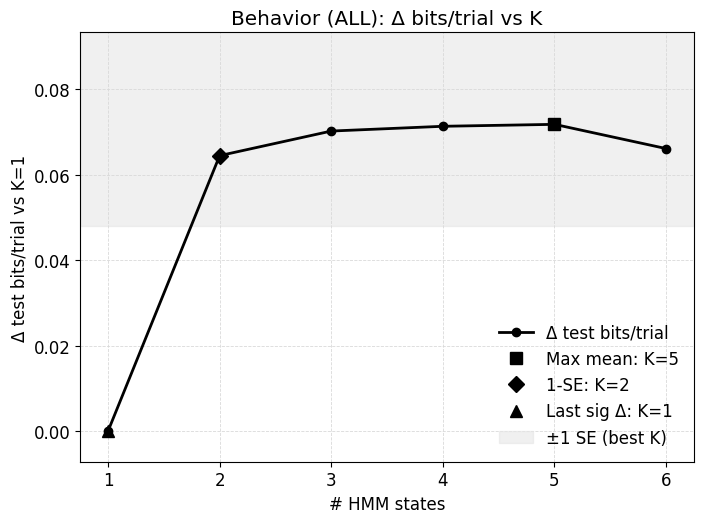

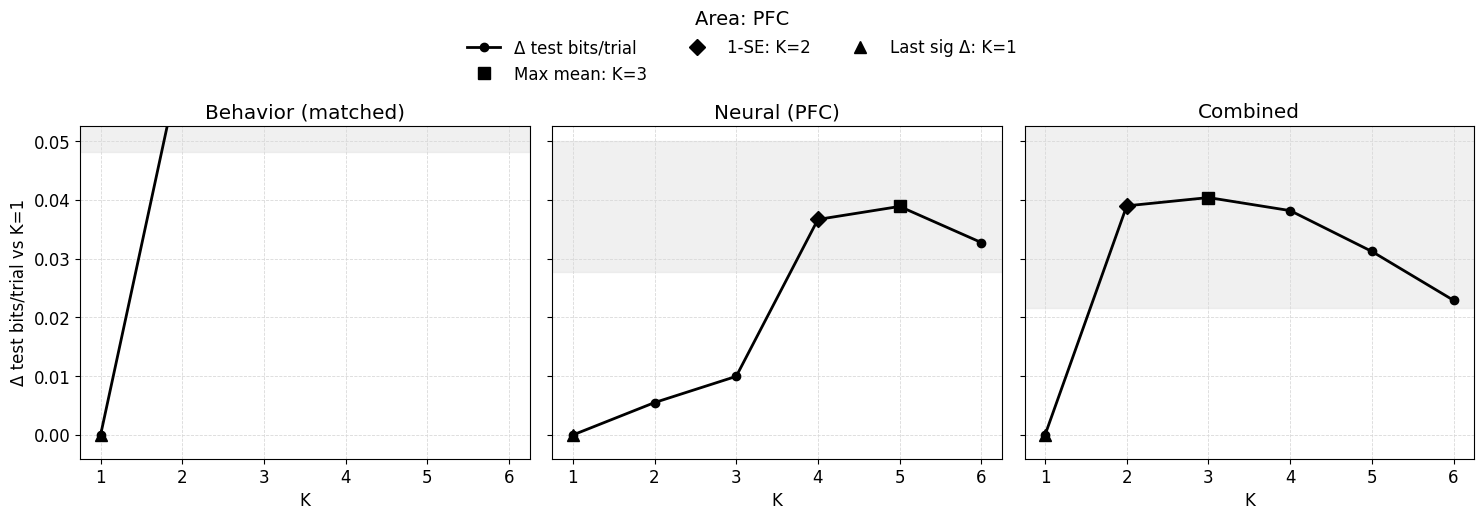

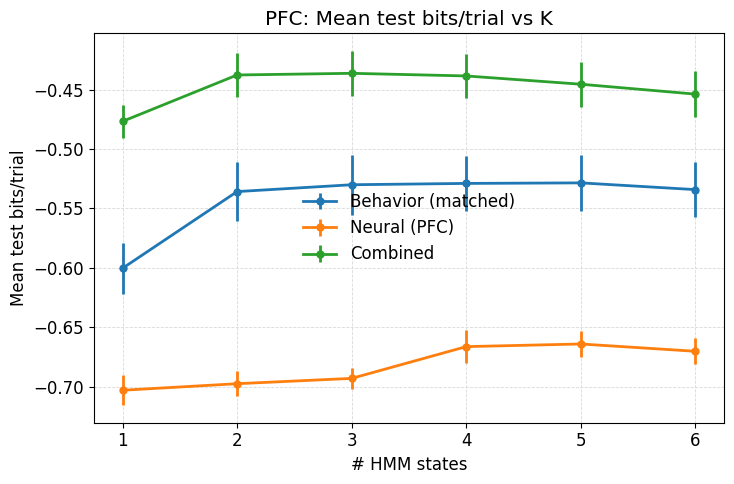

In [17]:
# 1) Plot behavior across ALL sessions:
fig, ax = plot_cv_block(cv_all['behavior_all'], title="Behavior (ALL): Δ bits/trial vs K")

# 2) Per-area triptych (behavior matched, neural, combined):
area_name = 'PFC'
fig, axes = plot_area_triptych(cv_all['areas'][area_name], area_name)

# 3) Overlay mean bits/trial curves for one area:
fig, ax = plot_area_overlay_mean_bpt(cv_all['areas'][area_name], area_name)

# 4) Selection table to print:
print(selection_table_for_area(cv_all['areas'][area_name], area_name))

              Dataset  K_max  K_1se  K_last_sig  K_plateau  \
0  Behavior (matched)      2      2           1          1   
1         Neural (V4)      1      1           1          3   
2            Combined      2      2           1          1   

   mean@K* (bits/trial)  
0             -0.437851  
1             -0.928169  
2             -0.458241  


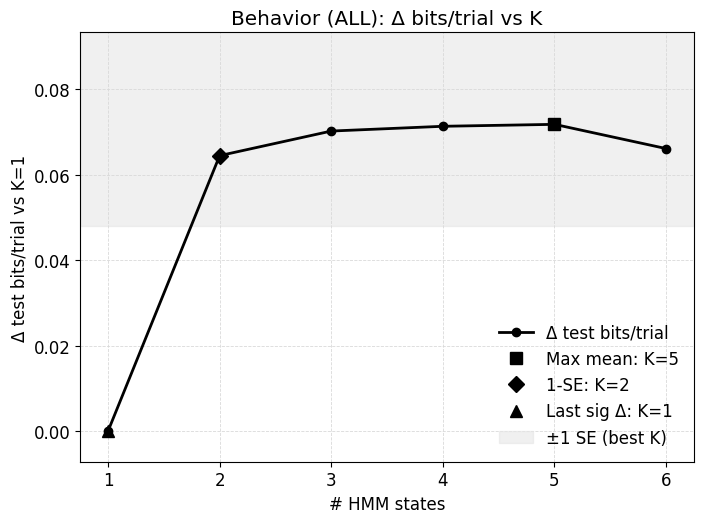

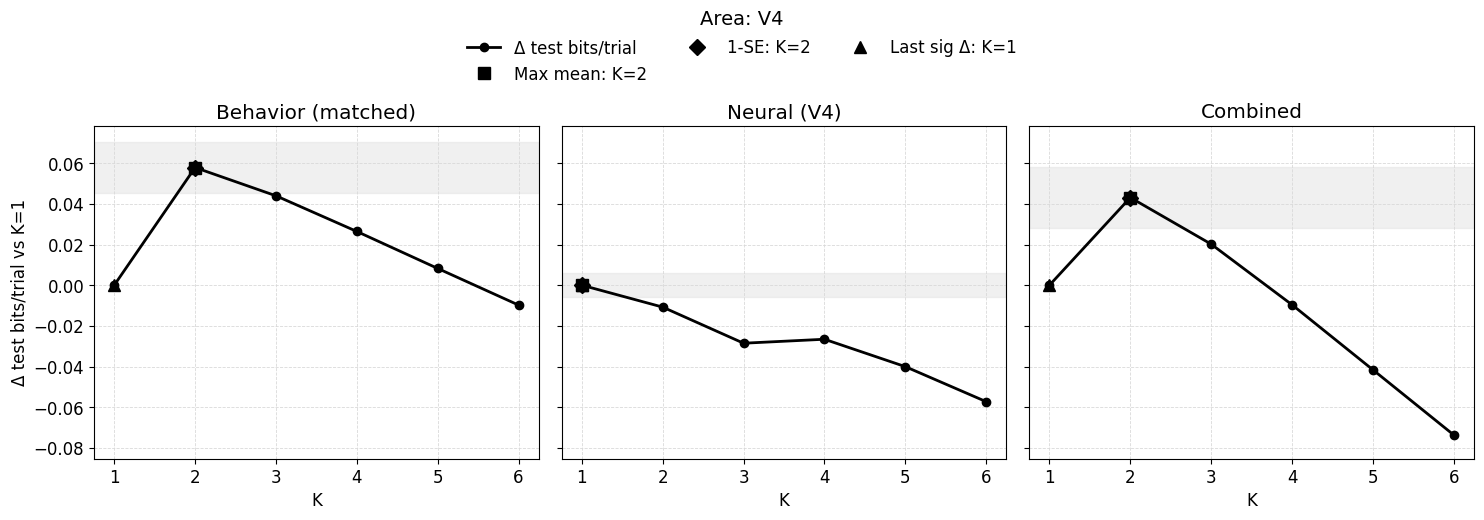

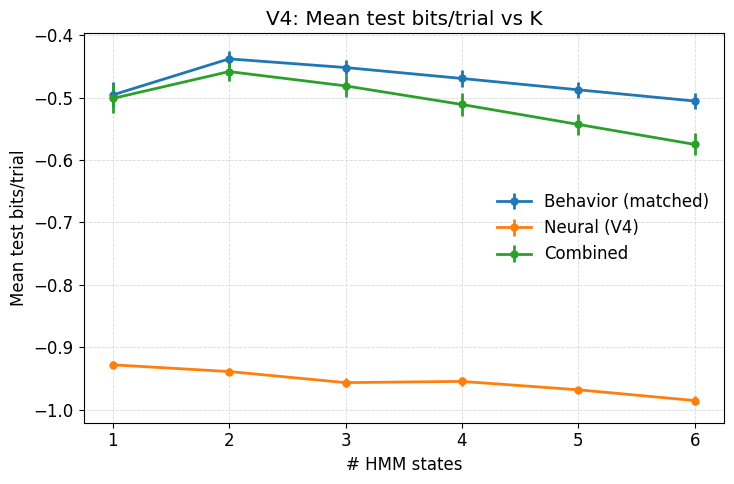

In [18]:
# 1) Plot behavior across ALL sessions:
fig, ax = plot_cv_block(cv_all['behavior_all'], title="Behavior (ALL): Δ bits/trial vs K")

# 2) Per-area triptych (behavior matched, neural, combined):
area_name = 'V4'
fig, axes = plot_area_triptych(cv_all['areas'][area_name], area_name)

# 3) Overlay mean bits/trial curves for one area:
fig, ax = plot_area_overlay_mean_bpt(cv_all['areas'][area_name], area_name)

# 4) Selection table to print:
print(selection_table_for_area(cv_all['areas'][area_name], area_name))

              Dataset  K_max  K_1se  K_last_sig  K_plateau  \
0  Behavior (matched)      2      2           1          1   
1         Neural (MT)      1      1           1          1   
2            Combined      2      1           1          1   

   mean@K* (bits/trial)  
0             -0.425329  
1             -0.875417  
2             -0.438063  


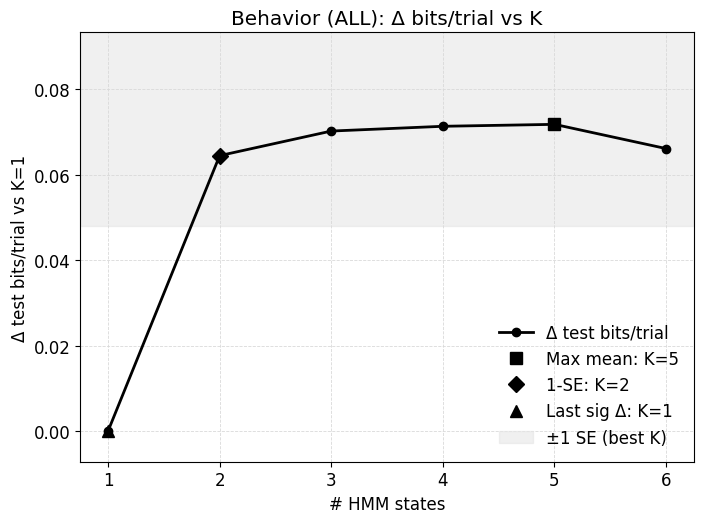

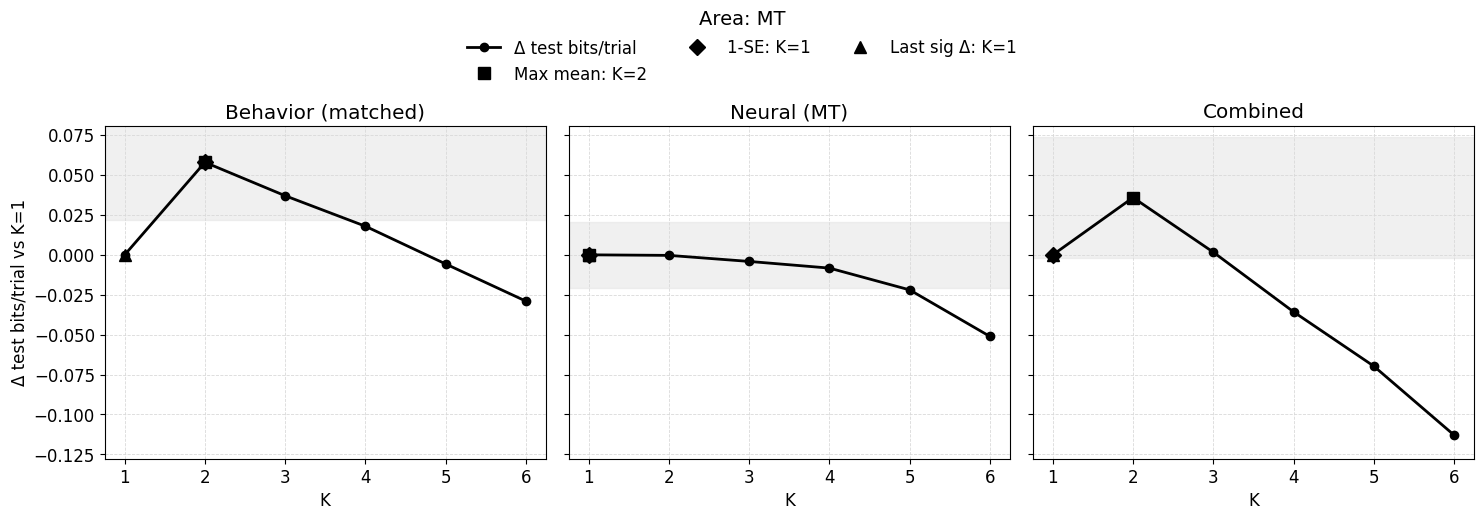

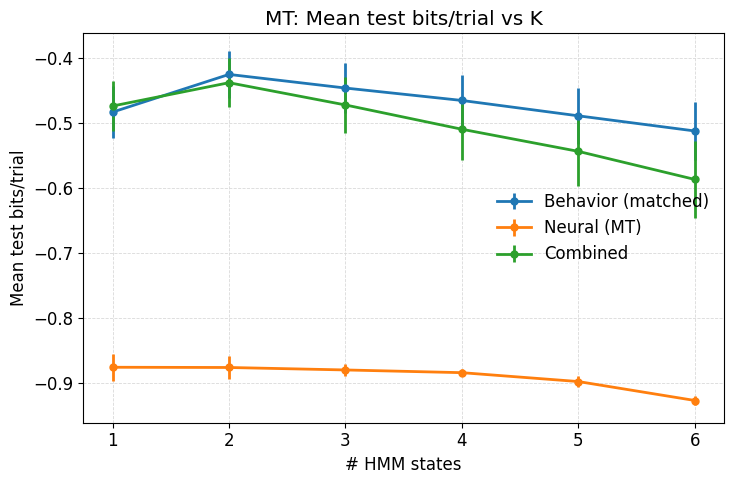

In [19]:
# 1) Plot behavior across ALL sessions:
fig, ax = plot_cv_block(cv_all['behavior_all'], title="Behavior (ALL): Δ bits/trial vs K")

# 2) Per-area triptych (behavior matched, neural, combined):
area_name = 'MT'
fig, axes = plot_area_triptych(cv_all['areas'][area_name], area_name)

# 3) Overlay mean bits/trial curves for one area:
fig, ax = plot_area_overlay_mean_bpt(cv_all['areas'][area_name], area_name)

# 4) Selection table to print:
print(selection_table_for_area(cv_all['areas'][area_name], area_name))

              Dataset  K_max  K_1se  K_last_sig  K_plateau  \
0  Behavior (matched)      2      2           1          1   
1         Neural (IT)      1      1           1          1   
2            Combined      2      1           1          1   

   mean@K* (bits/trial)  
0             -0.574796  
1             -0.973707  
2             -0.611548  


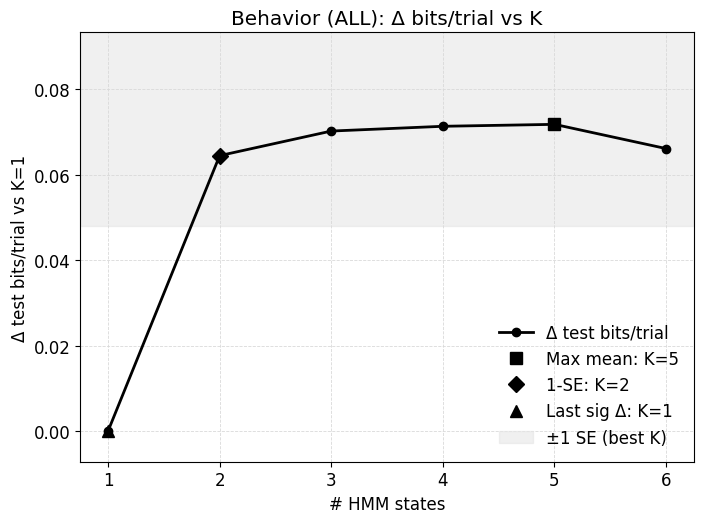

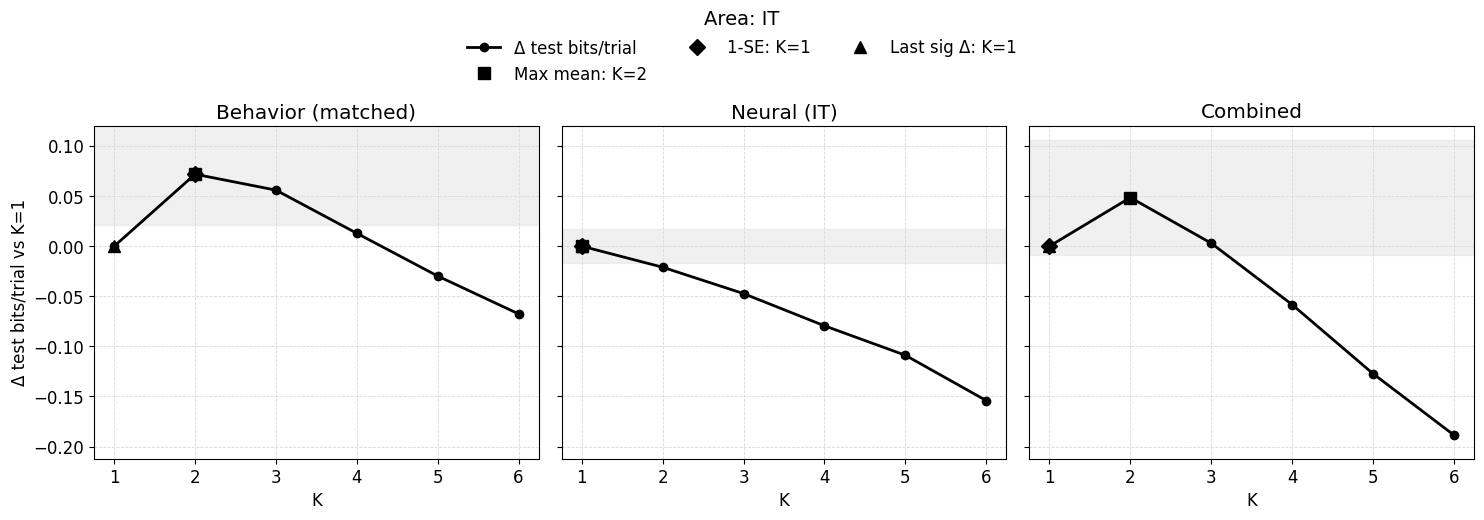

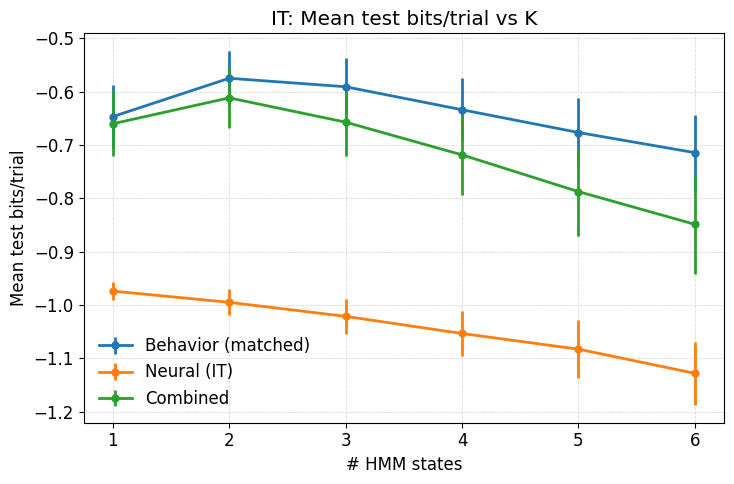

In [20]:
# 1) Plot behavior across ALL sessions:
fig, ax = plot_cv_block(cv_all['behavior_all'], title="Behavior (ALL): Δ bits/trial vs K")

# 2) Per-area triptych (behavior matched, neural, combined):
area_name = 'IT'
fig, axes = plot_area_triptych(cv_all['areas'][area_name], area_name)

# 3) Overlay mean bits/trial curves for one area:
fig, ax = plot_area_overlay_mean_bpt(cv_all['areas'][area_name], area_name)

# 4) Selection table to print:
print(selection_table_for_area(cv_all['areas'][area_name], area_name))

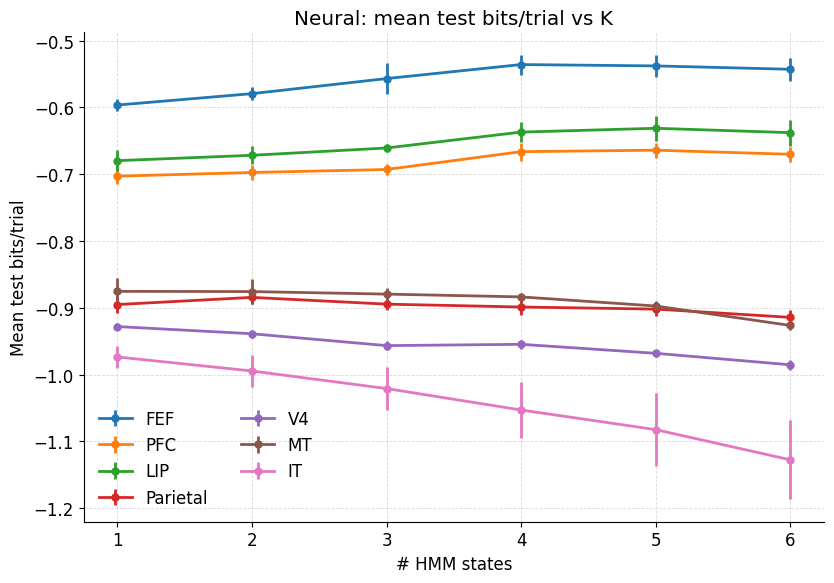

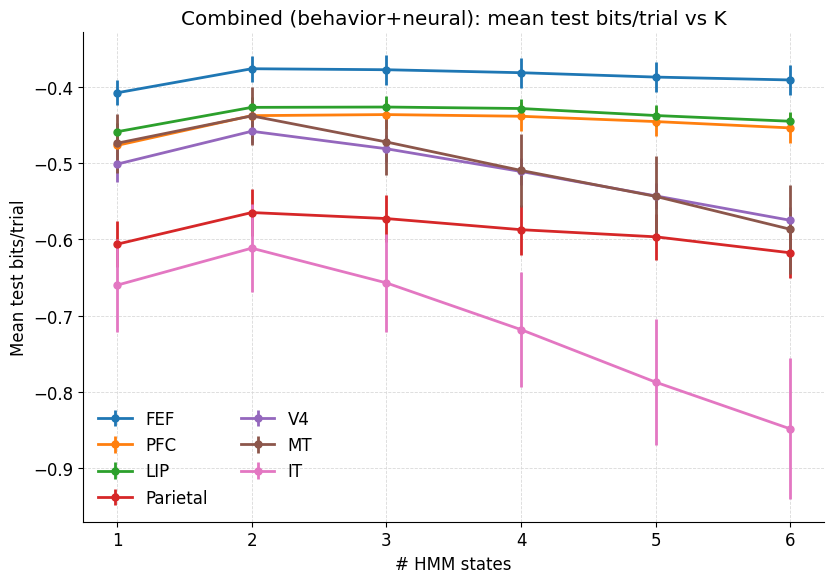

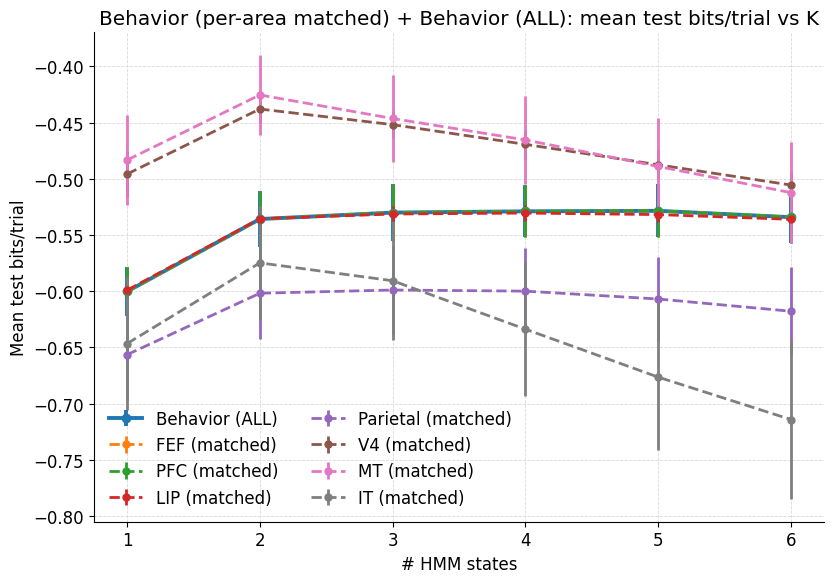

In [21]:
def _get_summary(block):
    """Return Ks, mean_bpt, sem_bpt from a cv result block (or None if missing)."""
    if block is None:
        return None
    sel = block.get("selection", {})
    meta = block.get("meta", {})
    if "mean_bpt" not in sel or "max_states" not in meta:
        return None
    Ks = np.arange(1, meta["max_states"] + 1)
    mean_bpt = np.asarray(sel["mean_bpt"], dtype=float)
    sem_bpt  = np.asarray(sel["sem_bpt"], dtype=float)
    return Ks, mean_bpt, sem_bpt

def _style(ax):
    ax.grid(True, linestyle="--", linewidth=0.6, color="0.85")
    ax.set_xlabel("# HMM states")
    ax.set_ylabel("Mean test bits/trial")
    for spine in ["top","right"]:
        ax.spines[spine].set_visible(False)

def plot_compare_neural(cv_all, areas=None, title="Neural: mean test bits/trial vs K"):
    """
    Overlays mean bits/trial curves for NEURAL across all brain areas.
    """
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0

    for area in areas:
        block = cv_all["areas"].get(area, {}).get("neural", None)
        summary = _get_summary(block)
        if summary is None:  # area missing or no sessions
            continue
        Ks, mean_bpt, sem_bpt = summary
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="-o", linewidth=2, markersize=5, label=area)
        plotted += 1

    _style(ax)
    ax.set_title(title)
    if plotted == 0:
        ax.text(0.5, 0.5, "No neural results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

def plot_compare_combined(cv_all, areas=None, title="Combined (behavior+neural): mean test bits/trial vs K"):
    """
    Overlays mean bits/trial curves for COMBINED across all brain areas.
    """
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0

    for area in areas:
        block = cv_all["areas"].get(area, {}).get("combined", None)
        summary = _get_summary(block)
        if summary is None:
            continue
        Ks, mean_bpt, sem_bpt = summary
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="-o", linewidth=2, markersize=5, label=area)
        plotted += 1

    _style(ax)
    ax.set_title(title)
    if plotted == 0:
        ax.text(0.5, 0.5, "No combined results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

def plot_compare_behavior(cv_all, areas=None,
                          title="Behavior (per-area matched) + Behavior (ALL): mean test bits/trial vs K",
                          include_overall=True):
    """
    Overlays mean bits/trial curves for BEHAVIOR across all areas (matched sessions),
    and also overlays the overall behavior (all sessions) if include_overall=True.
    """
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0

    # Overall behavior (ALL sessions)
    if include_overall and "behavior_all" in cv_all:
        block_all = cv_all["behavior_all"]
        summary = _get_summary(block_all)
        if summary is not None:
            Ks, mean_bpt, sem_bpt = summary
            # thicker line for overall
            ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="-o", linewidth=2.8, markersize=6,
                        label="Behavior (ALL)")

    # Per-area matched behavior
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("behavior_matched", None)
        summary = _get_summary(block)
        if summary is None:
            continue
        Ks, mean_bpt, sem_bpt = summary
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="--o", linewidth=2, markersize=5,
                    label=f"{area} (matched)")
        plotted += 1

    _style(ax)
    ax.set_title(title)
    if plotted == 0 and not include_overall:
        ax.text(0.5, 0.5, "No behavior results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax
# Choose your areas (optional). Default uses all in cv_all['areas'] keys.
areas = ['FEF','PFC','LIP','Parietal','V4','MT','IT']

# 1) Neural comparison across areas
fig_neu, ax_neu = plot_compare_neural(cv_all, areas)

# 2) Combined comparison across areas
fig_com, ax_com = plot_compare_combined(cv_all, areas)

# 3) Behavior comparison across areas (per-area matched) + overall behavior
fig_beh, ax_beh = plot_compare_behavior(cv_all, areas, include_overall=True)

# Optionally save:
fig_neu.savefig("compare_neural_across_areas.png", dpi=200, bbox_inches="tight")
fig_com.savefig("compare_combined_across_areas.png", dpi=200, bbox_inches="tight")
fig_beh.savefig("compare_behavior_across_areas.png", dpi=200, bbox_inches="tight")


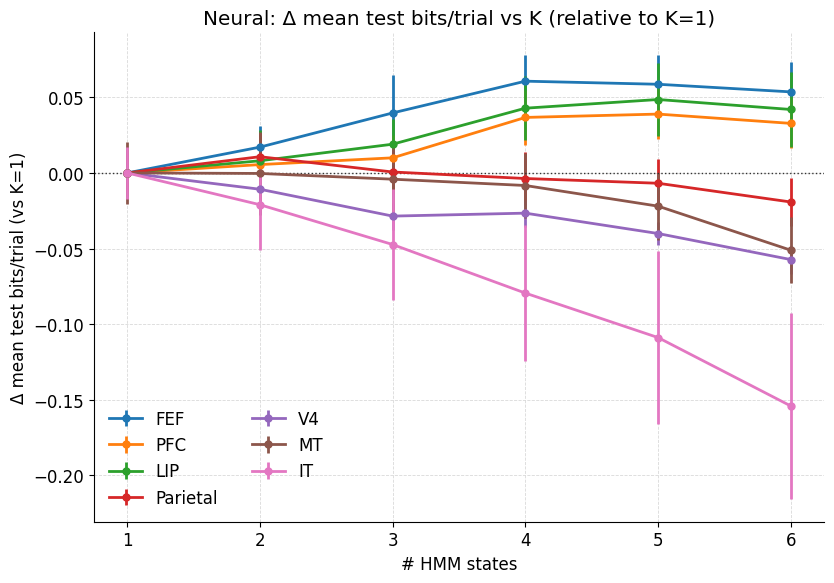

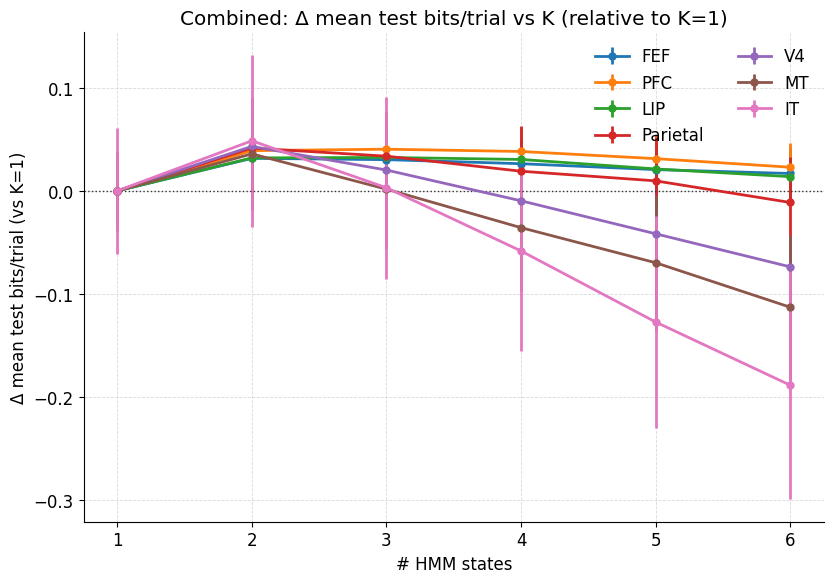

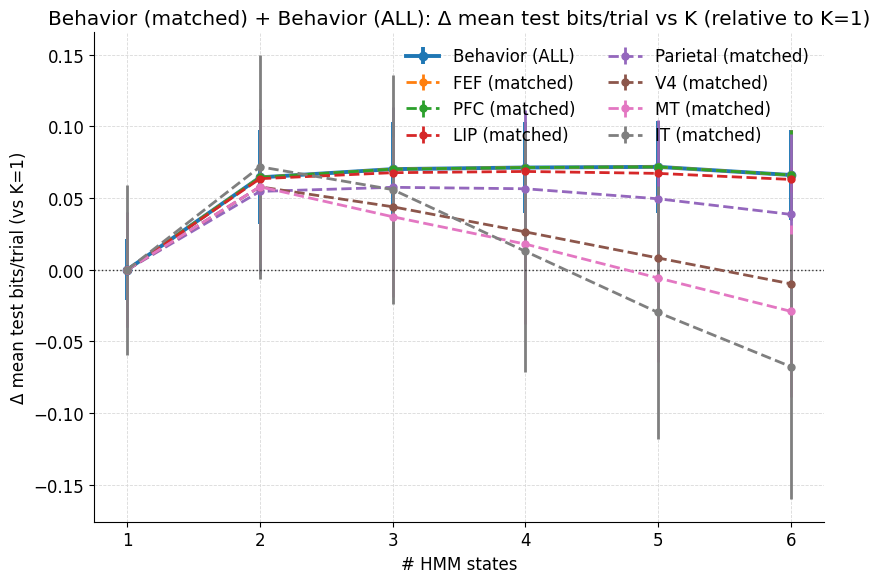

In [22]:
def _get_summary(block):
    """Return Ks, mean_bpt, sem_bpt from a cv result block (or None if missing)."""
    if block is None:
        return None
    sel = block.get("selection", {})
    meta = block.get("meta", {})
    if "mean_bpt" not in sel or "max_states" not in meta:
        return None
    Ks = np.arange(1, meta["max_states"] + 1)
    mean_bpt = np.asarray(sel["mean_bpt"], dtype=float)
    sem_bpt  = np.asarray(sel["sem_bpt"], dtype=float)
    return Ks, mean_bpt, sem_bpt

def _get_delta_summary(block):
    """
    Return Ks, delta_mean_bpt, delta_sem_bpt where delta is relative to K=1.
    SEM propagated conservatively via quadrature: sem_delta = sqrt(sem_k^2 + sem_1^2).
    """
    s = _get_summary(block)
    if s is None:
        return None
    Ks, mean_bpt, sem_bpt = s
    if len(Ks) == 0 or Ks[0] != 1:
        return None
    base_mean = mean_bpt[0]
    base_sem  = sem_bpt[0]
    delta_mean = mean_bpt - base_mean
    delta_sem  = np.sqrt(sem_bpt**2 + base_sem**2)
    # Force the baseline point to exact zero with its SEM
    delta_mean[0] = 0.0
    delta_sem[0]  = base_sem
    return Ks, delta_mean, delta_sem

def _style(ax, ylabel="Mean test bits/trial"):
    ax.grid(True, linestyle="--", linewidth=0.6, color="0.85")
    ax.set_xlabel("# HMM states")
    ax.set_ylabel(ylabel)
    for spine in ["top","right"]:
        ax.spines[spine].set_visible(False)

# ----- ORIGINAL PLOTS (unchanged) -----
def plot_compare_neural(cv_all, areas=None, title="Neural: mean test bits/trial vs K"):
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("neural", None)
        summary = _get_summary(block)
        if summary is None:
            continue
        Ks, mean_bpt, sem_bpt = summary
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="-o", linewidth=2, markersize=5, label=area)
        plotted += 1
    _style(ax)
    ax.set_title(title)
    if plotted == 0:
        ax.text(0.5, 0.5, "No neural results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

def plot_compare_combined(cv_all, areas=None, title="Combined (behavior+neural): mean test bits/trial vs K"):
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("combined", None)
        summary = _get_summary(block)
        if summary is None:
            continue
        Ks, mean_bpt, sem_bpt = summary
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="-o", linewidth=2, markersize=5, label=area)
        plotted += 1
    _style(ax)
    ax.set_title(title)
    if plotted == 0:
        ax.text(0.5, 0.5, "No combined results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

def plot_compare_behavior(cv_all, areas=None,
                          title="Behavior (per-area matched) + Behavior (ALL): mean test bits/trial vs K",
                          include_overall=True):
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0
    if include_overall and "behavior_all" in cv_all:
        block_all = cv_all["behavior_all"]
        summary = _get_summary(block_all)
        if summary is not None:
            Ks, mean_bpt, sem_bpt = summary
            ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="-o", linewidth=2.8, markersize=6,
                        label="Behavior (ALL)")
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("behavior_matched", None)
        summary = _get_summary(block)
        if summary is None:
            continue
        Ks, mean_bpt, sem_bpt = summary
        ax.errorbar(Ks, mean_bpt, yerr=sem_bpt, fmt="--o", linewidth=2, markersize=5,
                    label=f"{area} (matched)")
        plotted += 1
    _style(ax)
    ax.set_title(title)
    if plotted == 0 and not include_overall:
        ax.text(0.5, 0.5, "No behavior results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

# ----- NEW Δ(LL) PLOTS RELATIVE TO K=1 -----
def plot_compare_neural_delta(cv_all, areas=None, title="Neural: Δ mean test bits/trial vs K (relative to K=1)"):
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("neural", None)
        ds = _get_delta_summary(block)
        if ds is None:
            continue
        Ks, dmean, dsem = ds
        ax.errorbar(Ks, dmean, yerr=dsem, fmt="-o", linewidth=2, markersize=5, label=area)
        plotted += 1
    _style(ax, ylabel="Δ mean test bits/trial (vs K=1)")
    ax.axhline(0, color="0.2", linewidth=1, linestyle=":")
    ax.set_title(title)
    if plotted == 0:
        ax.text(0.5, 0.5, "No neural results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

def plot_compare_combined_delta(cv_all, areas=None, title="Combined: Δ mean test bits/trial vs K (relative to K=1)"):
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("combined", None)
        ds = _get_delta_summary(block)
        if ds is None:
            continue
        Ks, dmean, dsem = ds
        ax.errorbar(Ks, dmean, yerr=dsem, fmt="-o", linewidth=2, markersize=5, label=area)
        plotted += 1
    _style(ax, ylabel="Δ mean test bits/trial (vs K=1)")
    ax.axhline(0, color="0.2", linewidth=1, linestyle=":")
    ax.set_title(title)
    if plotted == 0:
        ax.text(0.5, 0.5, "No combined results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

def plot_compare_behavior_delta(cv_all, areas=None,
                                title="Behavior (matched) + Behavior (ALL): Δ mean test bits/trial vs K (relative to K=1)",
                                include_overall=True):
    if areas is None:
        areas = list(cv_all["areas"].keys())
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plotted = 0

    # Overall behavior (ALL sessions), delta
    if include_overall and "behavior_all" in cv_all:
        block_all = cv_all["behavior_all"]
        ds = _get_delta_summary(block_all)
        if ds is not None:
            Ks, dmean, dsem = ds
            ax.errorbar(Ks, dmean, yerr=dsem, fmt="-o", linewidth=2.8, markersize=6,
                        label="Behavior (ALL)")

    # Per-area matched behavior, delta
    for area in areas:
        block = cv_all["areas"].get(area, {}).get("behavior_matched", None)
        ds = _get_delta_summary(block)
        if ds is None:
            continue
        Ks, dmean, dsem = ds
        ax.errorbar(Ks, dmean, yerr=dsem, fmt="--o", linewidth=2, markersize=5,
                    label=f"{area} (matched)")
        plotted += 1

    _style(ax, ylabel="Δ mean test bits/trial (vs K=1)")
    ax.axhline(0, color="0.2", linewidth=1, linestyle=":")
    ax.set_title(title)
    if plotted == 0 and not include_overall:
        ax.text(0.5, 0.5, "No behavior results to display.", transform=ax.transAxes, ha="center")
    else:
        ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

# ----- Usage -----
areas = ['FEF','PFC','LIP','Parietal','V4','MT','IT']

# Δ relative to K=1
fig_neu_d, ax_neu_d = plot_compare_neural_delta(cv_all, areas)
fig_com_d, ax_com_d = plot_compare_combined_delta(cv_all, areas)
fig_beh_d, ax_beh_d = plot_compare_behavior_delta(cv_all, areas, include_overall=True)

# Optionally save:
fig_neu_d.savefig("compare_neural_across_areas_deltaK1.png", dpi=200, bbox_inches="tight")
fig_com_d.savefig("compare_combined_across_areas_deltaK1.png", dpi=200, bbox_inches="tight")
fig_beh_d.savefig("compare_behavior_across_areas_deltaK1.png", dpi=200, bbox_inches="tight")


# ACCURACY

In [6]:
def _run_accuracy_grid(inpts, true_choices, K_grid=(1,2,3,4),
                       n_splits=5, n_inits=5, num_iters=3000, tolerance=1e-3,
                       prior_sigma=2.0, prior_alpha=2.0, prior_kappa=0.0,
                       base_seed=0, quiet=True):
    """
    Run accuracy CV across K for one dataset (inpts/true_choices lists).
    Returns: dict {K: cv_result_dict} where cv_result_dict has acc_mean, acc_std, etc.
    """
    if inpts is None or true_choices is None or len(inpts) == 0:
        return {}
    out = {}
    for K in K_grid:
        if not quiet:
            print(f"\n=== CV accuracy for K={K} ===")
        res = cv_glmhmm_bpt_select_best_acc(
            inpts, true_choices,
            n_splits=n_splits,
            K=K,
            prior_sigma=prior_sigma,
            prior_alpha=prior_alpha,
            prior_kappa=prior_kappa,
            num_iters=num_iters,
            tolerance=tolerance,
            n_inits=n_inits,
            base_seed=base_seed,
            print_per_fold=(not quiet),
        )
        out[K] = res
    return out

def run_accuracy_for_all(results_builder,        # from build_all_glmhmm_inputs(...)
                         areas=('FEF','PFC','LIP','Parietal','V4','MT','IT'),
                         K_grid=(1,2,3,4),
                         n_splits=5, n_inits=5, num_iters=3000, tolerance=1e-3,
                         prior_sigma=2.0, prior_alpha=2.0, prior_kappa=0.0,
                         base_seed=0, quiet=True):
    """
    Compute predictive accuracy (CV over sessions, best init by held-out bits/trial)
    for:
      - Behavior across ALL sessions
      - For each area: behavior_matched, neural, combined
    Returns nested dict with accuracy curves vs K for each.
    """
    out = {"behavior_all": None, "areas": {}}

    # Behavior (ALL sessions)
    beh_all = results_builder['behavior_all']
    out['behavior_all'] = _run_accuracy_grid(
        beh_all['inpts'], beh_all['true_choices'],
        K_grid=K_grid, n_splits=n_splits, n_inits=n_inits,
        num_iters=num_iters, tolerance=tolerance,
        prior_sigma=prior_sigma, prior_alpha=prior_alpha, prior_kappa=prior_kappa,
        base_seed=base_seed, quiet=quiet
    )

    # Per-area datasets
    for area in areas:
        block = results_builder['areas'].get(area, None)
        area_out = {"behavior_matched": {}, "neural": {}, "combined": {}, "indices": []}
        if block is None or len(block['indices']) == 0:
            out['areas'][area] = area_out
            continue

        area_out['indices'] = block['indices']

        # Matched behavior
        beh = block['behavior_matched']
        area_out['behavior_matched'] = _run_accuracy_grid(
            beh['inpts'], beh['true_choices'],
            K_grid=K_grid, n_splits=n_splits, n_inits=n_inits,
            num_iters=num_iters, tolerance=tolerance,
            prior_sigma=prior_sigma, prior_alpha=prior_alpha, prior_kappa=prior_kappa,
            base_seed=base_seed, quiet=quiet
        )

        # Neural-only
        neu = block['neural']
        area_out['neural'] = _run_accuracy_grid(
            neu['inpts'], neu['true_choices'],
            K_grid=K_grid, n_splits=n_splits, n_inits=n_inits,
            num_iters=num_iters, tolerance=tolerance,
            prior_sigma=prior_sigma, prior_alpha=prior_alpha, prior_kappa=prior_kappa,
            base_seed=base_seed, quiet=quiet
        )

        # Combined
        com = block['combined']
        area_out['combined'] = _run_accuracy_grid(
            com['inpts'], com['true_choices'],
            K_grid=K_grid, n_splits=n_splits, n_inits=n_inits,
            num_iters=num_iters, tolerance=tolerance,
            prior_sigma=prior_sigma, prior_alpha=prior_alpha, prior_kappa=prior_kappa,
            base_seed=base_seed, quiet=quiet
        )

        out['areas'][area] = area_out

    return out

# ---------- helpers to flatten accuracy curves to DataFrames ----------
def accuracy_table_from_results(res_by_K):
    """
    Given {K: cv_result_dict} produce a tidy DataFrame with columns:
    ['K','acc_mean','acc_std','bpt_mean','bpt_std']
    """
    rows = []
    for K, d in sorted(res_by_K.items()):
        rows.append({
            "K": int(K),
            "acc_mean": d.get("acc_mean", np.nan),
            "acc_std":  d.get("acc_std",  np.nan),
            "bpt_mean": d.get("bpt_mean", np.nan),
            "bpt_std":  d.get("bpt_std",  np.nan),
        })
    return pd.DataFrame(rows)

def build_all_accuracy_tables(acc_all, areas=('FEF','PFC','LIP','Parietal','V4','MT','IT')):
    """
    Create DataFrames:
      - behavior_all_df
      - per-area dict with behavior_matched_df, neural_df, combined_df
    """
    behavior_all_df = accuracy_table_from_results(acc_all["behavior_all"])

    per_area = {}
    for area in areas:
        block = acc_all["areas"].get(area, None)
        if block is None or 'indices' not in block:
            continue
        per_area[area] = {
            "behavior_matched_df": accuracy_table_from_results(block["behavior_matched"]),
            "neural_df":           accuracy_table_from_results(block["neural"]),
            "combined_df":         accuracy_table_from_results(block["combined"]),
            "indices":             block["indices"],
        }
    return behavior_all_df, per_area

import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import ssm

LN2 = np.log(2.0)


# ---------- Fit (standard for K=1, sticky for K>1) ----------
def fit_glmhmm_logits(
    inpts_train, true_choices_train,
    *,
    K=2,
    prior_sigma=2.0,
    prior_alpha=2.0,
    prior_kappa=0.0,
    num_iters=300,
    tolerance=1e-3,
    seed=0,
):
    """Fit a GLM-HMM on lists of sessions (inputs + choices)."""
    inpts_train = [np.asarray(X) for X in inpts_train]
    true_choices_train = [np.asarray(y).reshape(-1, 1).astype(int) for y in true_choices_train]

    M, D, C = inpts_train[0].shape[1], 1, 2
    rng = np.random.default_rng(seed)

    if K == 1:
        hmm = ssm.HMM(
            K=1, D=D, M=M,
            observations="input_driven_obs",
            observation_kwargs=dict(C=C, prior_sigma=prior_sigma),
            transitions="standard",
            rng=rng,
        )
    else:
        hmm = ssm.HMM(
            K=K, D=D, M=M,
            observations="input_driven_obs",
            observation_kwargs=dict(C=C, prior_sigma=prior_sigma),
            transitions="sticky",
            transition_kwargs=dict(alpha=prior_alpha, kappa=prior_kappa),
            rng=rng,
        )

    hmm.fit(true_choices_train, inputs=inpts_train, method="em",
            num_iters=num_iters, tolerance=tolerance)
    return hmm


# ---------- Evaluate held-out bits per trial ----------
def heldout_bits_per_trial(hmm, inpts_test, true_choices_test):
    """Compute normalized log-likelihood (bits per trial) on held-out sessions."""
    total_ll, total_T = 0.0, 0
    for Xs, ys in zip(inpts_test, true_choices_test):
        Xs = np.asarray(Xs)
        ys = np.asarray(ys).reshape(-1, 1).astype(int)
        mask = np.ones_like(ys, dtype=bool)
        ll = hmm.log_probability([ys], inputs=[Xs], masks=[mask], tags=[None])
        total_ll += float(ll)
        total_T  += int(ys.shape[0])
    if total_T == 0:
        return np.nan
    return (total_ll / total_T) / LN2  # bits/trial


# ---------- Predict state-marginalized probabilities for accuracy ----------
def predict_probs_logits_marginalized(hmm, inpts_test, true_choices_test):
    """Return concatenated p(y=1|x) and true labels across test sessions."""
    probs_all, y_all = [], []
    for Xs, ys in zip(inpts_test, true_choices_test):
        Xs = np.asarray(Xs)
        ys = np.asarray(ys).reshape(-1, 1).astype(int)
        mask = np.ones_like(ys, dtype=bool)

        Ez = hmm.expected_states(data=ys, input=Xs, mask=mask)
        Ez = Ez[0] if isinstance(Ez, tuple) else Ez  # (T,K)

        # logits: (T,K,C) → stable softmax
        logits = hmm.observations.calculate_logits(input=Xs)
        logits -= logits.max(axis=2, keepdims=True)
        probs = np.exp(logits)
        probs /= probs.sum(axis=2, keepdims=True)

        p1_k = probs[:, :, 1]            # (T,K)
        p1   = np.sum(Ez * p1_k, axis=1) # (T,)
        probs_all.append(p1)
        y_all.append(ys.ravel())
    return np.concatenate(probs_all), np.concatenate(y_all)


# ---------- CV with many inits; pick best by held-out bits/trial; report accuracy ----------
def cv_glmhmm_bpt_select_best_acc(
    inpts, true_choices,
    *,
    n_splits=5,
    K=2,
    prior_sigma=2.0,
    prior_alpha=2.0,
    prior_kappa=0.0,
    num_iters=3000,
    tolerance=1e-3,
    n_inits=5,
    base_seed=0,
    print_per_fold=True,
):
    """
    Session-block CV:
      - For each fold, fit n_inits models with different seeds.
      - Select the model with the highest held-out bits/trial.
      - Compute accuracy using that selected model on the same held-out sessions.
    """
    inpts = [np.asarray(X) for X in inpts]
    true_choices = [np.asarray(y).reshape(-1, 1).astype(int) for y in true_choices]

    n_sessions = len(inpts)
    if n_sessions != len(true_choices):
        raise ValueError("inpts and true_choices must have the same number of sessions.")
    n_splits = min(n_splits, n_sessions)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=base_seed)

    acc_folds = []
    bpt_folds_best = []
    per_init_bpt = np.full((n_inits, n_splits), np.nan, dtype=float)
    best_models = [None] * n_splits

    for f, (tr_idx, te_idx) in enumerate(kf.split(range(n_sessions)), 1):
        in_tr   = [inpts[i] for i in tr_idx]
        ch_tr   = [true_choices[i] for i in tr_idx]
        in_te   = [inpts[i] for i in te_idx]
        ch_te   = [true_choices[i] for i in te_idx]

        best_bpt = -np.inf
        best_hmm = None

        # Many inits → pick best by held-out bits/trial
        for z in range(n_inits):
            seed = base_seed + 10_000 * f + z
            hmm = fit_glmhmm_logits(
                in_tr, ch_tr, K=K,
                prior_sigma=prior_sigma, prior_alpha=prior_alpha, prior_kappa=prior_kappa,
                num_iters=num_iters, tolerance=tolerance, seed=seed
            )
            bpt = heldout_bits_per_trial(hmm, in_te, ch_te)
            per_init_bpt[z, f-1] = bpt
            if np.isfinite(bpt) and bpt > best_bpt:
                best_bpt = bpt
                best_hmm = hmm

        # Use the best model to compute accuracy on held-out sessions
        probs, y_true = predict_probs_logits_marginalized(best_hmm, in_te, ch_te)
        yhat = (probs >= 0.5).astype(int)
        acc  = accuracy_score(y_true, yhat)

        acc_folds.append(acc)
        bpt_folds_best.append(best_bpt)
        best_models[f-1] = best_hmm

        if print_per_fold:
            n_te = int(sum(len(s) for s in ch_te))
            print(f"Fold {f}/{n_splits} | N={n_te} | best BPT={best_bpt:.6f} | Acc={acc:.3f}")

    res = {
        "acc_folds": acc_folds,
        "acc_mean": float(np.nanmean(acc_folds)),
        "acc_std":  float(np.nanstd(acc_folds)),
        "best_bpt_folds": bpt_folds_best,
        "bpt_mean": float(np.nanmean(bpt_folds_best)),
        "bpt_std":  float(np.nanstd(bpt_folds_best)),
        "per_init_bpt": per_init_bpt,   # shape (n_inits, n_splits)
        "best_models": best_models,     # HMM object per fold
    }

    print("\n=== CV (select best init by held-out bits/trial) ===")
    print(f"Accuracy:  {res['acc_mean']:.3f} ± {res['acc_std']:.3f}")
    print(f"Bits/trial (best per fold): {res['bpt_mean']:.6f} ± {res['bpt_std']:.6f}")
    return res


# ---------------- Example call ----------------
# cv_out = cv_glmhmm_bpt_select_best_acc(
#     inpts, true_choices,
#     n_splits=3,
#     K=2,
#     prior_sigma=2.0,
#     prior_alpha=2.0,
#     prior_kappa=0.0,
#     num_iters=3000,
#     tolerance=1e-3,
#     n_inits=8,
#     base_seed=0,
#     print_per_fold=True,
# )


In [8]:
K_grid = (1,2,3,4,5,6)

In [ ]:
# You already have:
#   results = build_all_glmhmm_inputs(data_neural)
# (if you don't: run that first)

K_grid = (1,2,3,4,5,6)

# 1) Run accuracy CV for all datasets
acc_all = run_accuracy_for_all(
    results_builder=results,
    areas=('FEF','PFC','LIP','Parietal','V4','MT','IT'),
    K_grid=K_grid,
    n_splits=5,
    n_inits=5,
    num_iters=3000,
    tolerance=1e-3,
    base_seed=0,
    quiet=True
)


In [7]:
# let's opne the following:

with open ('C:/Users/shahe/PycharmProjects/Monkey-Project/Behavioural analysis/HMM_GLM_neural_regressors/cv_all_accuracy_results.pkl', 'rb') as f:
    cv_all = pickle.load(f)


In [9]:
acc_all = cv_all['acc_all']

In [10]:

# 2) Build tidy tables (easy to print / save / plot)
behavior_all_df, per_area_tables = build_all_accuracy_tables(acc_all)

print("Behavior (ALL) accuracy:")
print(behavior_all_df)

print("\nExample: LIP tables")
lip_tbls = per_area_tables.get('LIP', None)
if lip_tbls is not None:
    print("LIP - Behavior (matched):")
    print(lip_tbls["behavior_matched_df"])
    print("LIP - Neural:")
    print(lip_tbls["neural_df"])
    print("LIP - Combined:")
    print(lip_tbls["combined_df"])


Behavior (ALL) accuracy:
   K  acc_mean   acc_std  bpt_mean   bpt_std
0  1  0.841606  0.004164 -0.606755  0.013427
1  2  0.895151  0.005680 -0.563200  0.010504
2  3  0.927718  0.002057 -0.593604  0.011557
3  4  0.924940  0.009246 -0.635605  0.010617
4  5  0.928328  0.010779 -0.696804  0.014080
5  6  0.930895  0.007193 -0.778741  0.019249

Example: LIP tables
LIP - Behavior (matched):
   K  acc_mean   acc_std  bpt_mean   bpt_std
0  1  0.839856  0.012485 -0.610564  0.019128
1  2  0.893800  0.009520 -0.567461  0.016777
2  3  0.923357  0.010722 -0.596364  0.012288
3  4  0.936530  0.021177 -0.639734  0.014290
4  5  0.941950  0.011649 -0.699734  0.012799
5  6  0.942828  0.010339 -0.777997  0.013111
LIP - Neural:
   K  acc_mean   acc_std  bpt_mean   bpt_std
0  1  0.791991  0.012482 -0.687168  0.021171
1  2  0.797855  0.013662 -0.696119  0.025237
2  3  0.839984  0.057658 -0.722298  0.028631
3  4  0.884837  0.049505 -0.764793  0.012314
4  5  0.928895  0.009925 -0.806563  0.037558
5  6  0.934198

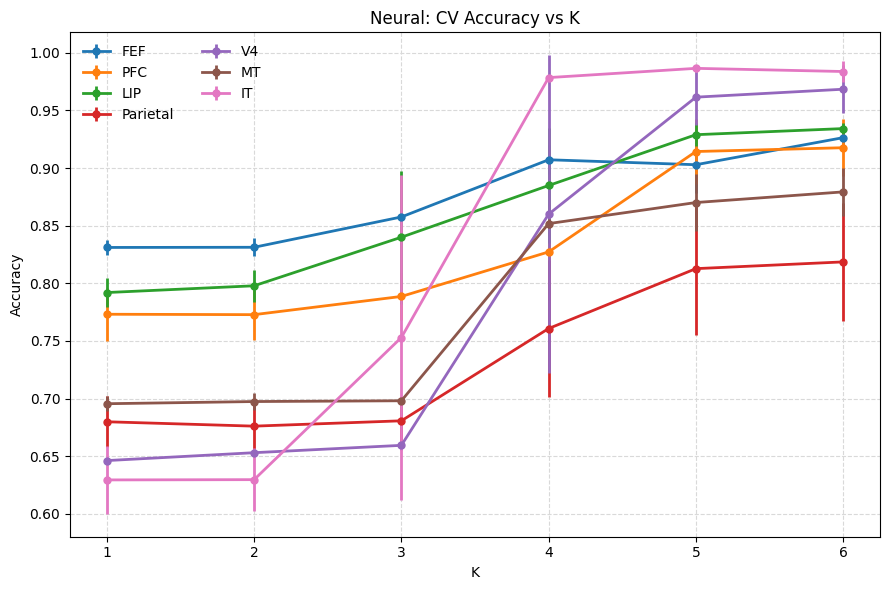

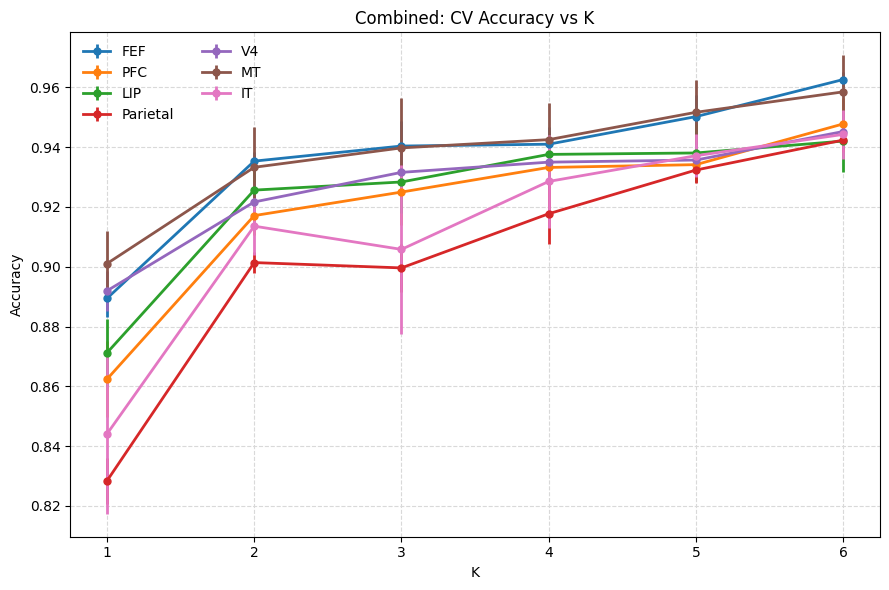

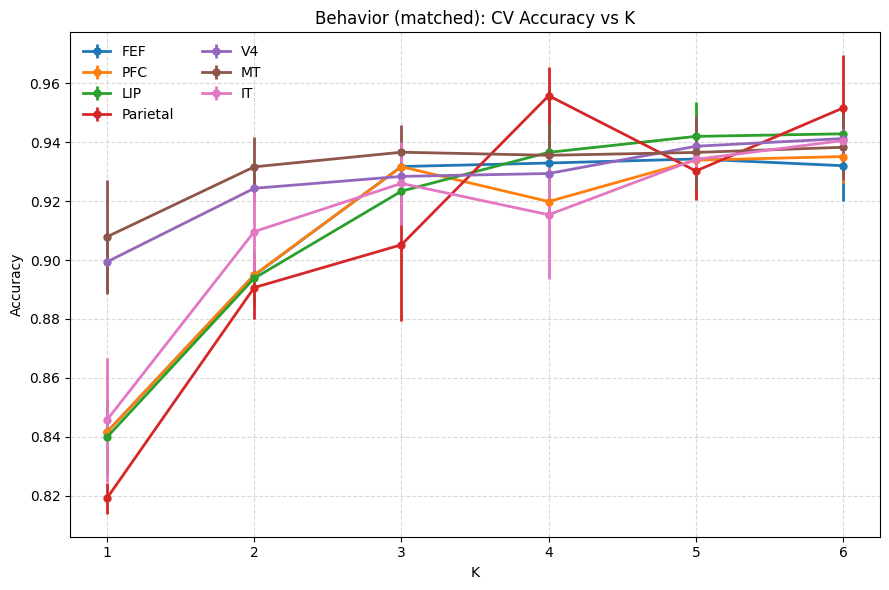

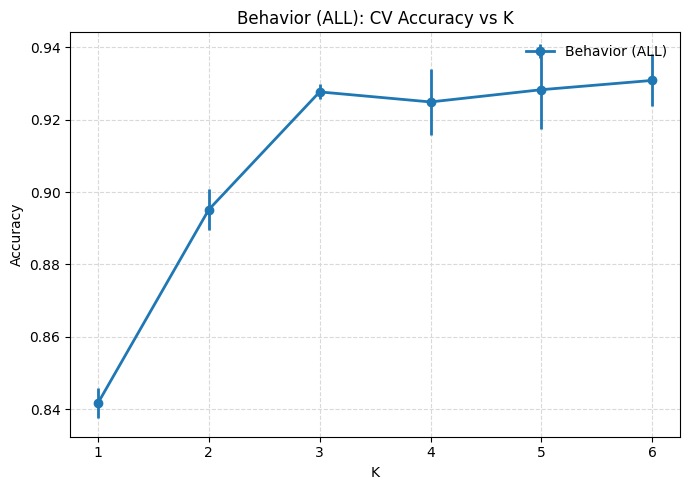

In [11]:
def plot_compare_accuracy(acc_all, which='neural', areas=None, title=None):
    """
    which: 'neural' | 'combined' | 'behavior_matched' | 'behavior_all'
    """
    if which == 'behavior_all':
        df = accuracy_table_from_results(acc_all['behavior_all'])
        fig, ax = plt.subplots(figsize=(7,5))
        ax.errorbar(df['K'], df['acc_mean'], yerr=df['acc_std'], fmt='-o', linewidth=2, markersize=6, label='Behavior (ALL)')
        ax.set_xlabel('K'); ax.set_ylabel('Accuracy'); ax.grid(True, linestyle='--', color='0.85')
        ax.set_title(title or 'Behavior (ALL): CV Accuracy vs K')
        ax.legend(frameon=False); plt.tight_layout()
        return fig, ax

    if areas is None:
        areas = list(acc_all['areas'].keys())

    fig, ax = plt.subplots(figsize=(9,6))
    for area in areas:
        block = acc_all['areas'].get(area, {})
        resK = block.get(which, {})
        if not resK:
            continue
        df = accuracy_table_from_results(resK)
        ax.errorbar(df['K'], df['acc_mean'], yerr=df['acc_std'], fmt='-o', linewidth=2, markersize=5, label=area)

    ax.set_xlabel('K'); ax.set_ylabel('Accuracy'); ax.grid(True, linestyle='--', color='0.85')
    ttl = {
        'neural': 'Neural: CV Accuracy vs K',
        'combined': 'Combined: CV Accuracy vs K',
        'behavior_matched': 'Behavior (matched): CV Accuracy vs K',
    }.get(which, which)
    ax.set_title(title or ttl)
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

# Examples:
fig1, ax1 = plot_compare_accuracy(acc_all, which='neural', areas=('FEF','PFC','LIP','Parietal','V4','MT','IT'))
fig2, ax2 = plot_compare_accuracy(acc_all, which='combined')
fig3, ax3 = plot_compare_accuracy(acc_all, which='behavior_matched')
fig4, ax4 = plot_compare_accuracy(acc_all, which='behavior_all')


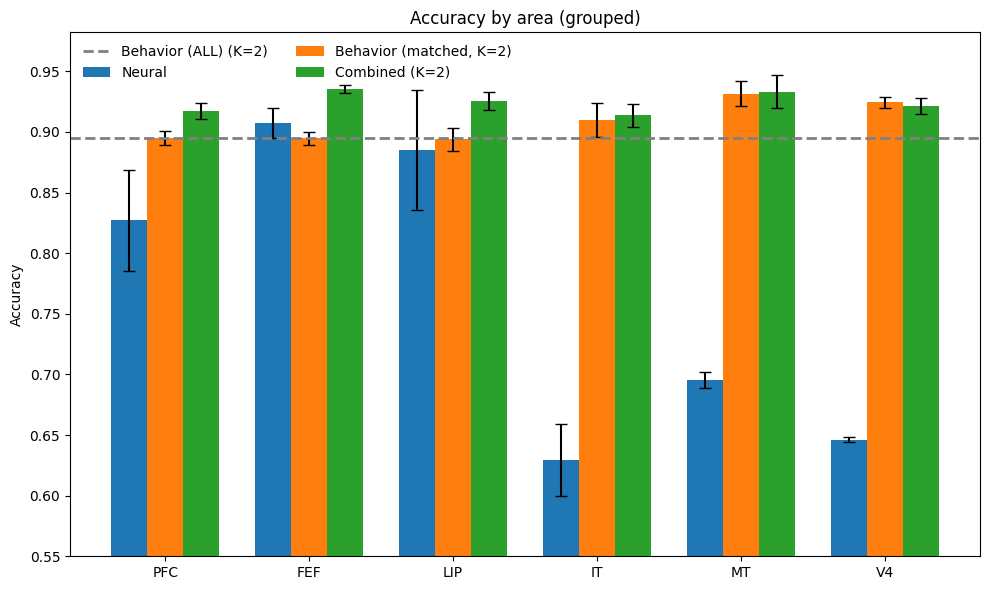

In [16]:
def plot_accuracy_bars(acc_all, areas=None, title="Accuracy by area (grouped)"):
    """
    Makes a grouped bar plot:
      - x-axis: areas
      - Bars per area: Neural, Behavior (matched), Combined
      - Neural uses K=4 for PFC/FEF/LIP and K=1 for IT/MT/V4 (configurable below)
      - Behavior (matched) uses K=2
      - Combined uses K=2
      - Adds a grey horizontal line for Behavior (ALL), preferring K=2 if present, else best K.
      
    Expects:
      acc_all['areas'][area]['neural'|'behavior_matched'|'combined'] -> results object
      acc_all['behavior_all'] -> results object
    And a function:
      accuracy_table_from_results(results) -> DataFrame with columns ['K', 'acc_mean', 'acc_std']
    """
    # Default area order if none provided
    if areas is None:
        # If you want a specific canonical order, set it here:
        preferred = ['PFC', 'FEF', 'LIP', 'IT', 'MT', 'V4']
        available = list(acc_all.get('areas', {}).keys())
        areas = [a for a in preferred if a in available] or available

    # Neural K per area mapping per your spec
    neural_k_map = {
        'PFC': 4,
        'FEF': 4,
        'LIP': 4,
        'IT' : 1,
        'MT' : 1,
        'V4' : 1,
    }

    def _pick_row_by_K(df, K_target):
        """Return (mean, std, K_used) for requested K; if missing, fallback to best (highest mean)."""
        if df.empty:
            return np.nan, 0.0, K_target
        # Try exact K
        row = df.loc[df['K'] == K_target]
        if len(row) == 1:
            r = row.iloc[0]
            return float(r['acc_mean']), float(r['acc_std']), int(r['K'])
        # Fallback: choose K with highest mean accuracy
        r = df.sort_values('acc_mean', ascending=False).iloc[0]
        return float(r['acc_mean']), float(r['acc_std']), int(r['K'])

    def _extract(acc_block, which_key):
        """Return DataFrame (may be empty) from acc_all['areas'][area][which_key]."""
        if not acc_block:
            return None
        resK = acc_block.get(which_key, {})
        try:
            df = accuracy_table_from_results(resK)
        except Exception:
            return None
        return df

    # Build values
    neural_means, neural_stds = [], []
    behM_means, behM_stds = [], []
    comb_means, comb_stds = [], []

    used_neural_K = {}  # track which K actually used per area (for sanity/debug)
    for area in areas:
        block = acc_all.get('areas', {}).get(area, {})

        # Neural
        df_neu = _extract(block, 'neural')
        if df_neu is None:
            nm, ns, k_used = np.nan, 0.0, None
        else:
            k_req = neural_k_map.get(area, 4)  # default to 4-state if unknown
            nm, ns, k_used = _pick_row_by_K(df_neu, k_req)
        neural_means.append(nm); neural_stds.append(ns); used_neural_K[area] = k_used

        # Behavior matched (K=2)
        df_bm = _extract(block, 'behavior_matched')
        if df_bm is None:
            bm, bs, _ = np.nan, 0.0, None
        else:
            bm, bs, _ = _pick_row_by_K(df_bm, 2)
        behM_means.append(bm); behM_stds.append(bs)

        # Combined (K=2)
        df_comb = _extract(block, 'combined')
        if df_comb is None:
            cm, cs, _ = np.nan, 0.0, None
        else:
            cm, cs, _ = _pick_row_by_K(df_comb, 2)
        comb_means.append(cm); comb_stds.append(cs)

    # Behavior ALL line (prefer K=2, else best)
    try:
        df_all = accuracy_table_from_results(acc_all.get('behavior_all', {}))
        if (df_all is not None) and (not df_all.empty):
            if (df_all['K'] == 2).any():
                all_mean, all_std, all_K = _pick_row_by_K(df_all, 2)
            else:
                all_mean, all_std, all_K = _pick_row_by_K(df_all, int(df_all.iloc[0]['K']))
        else:
            all_mean, all_std, all_K = np.nan, 0.0, None
    except Exception:
        all_mean, all_std, all_K = np.nan, 0.0, None

    # Plot
    x = np.arange(len(areas))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width, neural_means, width, yerr=neural_stds, capsize=4, label='Neural')
    bars2 = ax.bar(x,         behM_means,  width, yerr=behM_stds,  capsize=4, label='Behavior (matched, K=2)')
    bars3 = ax.bar(x + width, comb_means,  width, yerr=comb_stds,  capsize=4, label='Combined (K=2)')

    # Horizontal line for Behavior (ALL)
    if not np.isnan(all_mean):
        ax.axhline(all_mean, linestyle='--', color='0.5', linewidth=2,
                   label=f'Behavior (ALL){f" (K={all_K})" if all_K is not None else ""}')

    ax.set_xticks(x)
    ax.set_xticklabels(areas, rotation=0)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_ylim(0.55, 1.05 * max(max(neural_means), max(behM_means), max(comb_means), all_mean if not np.isnan(all_mean) else 0))
    
    #ax.grid(True, axis='y', linestyle='--', color='0.85')
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    return fig, ax

# Example usage with your `acc_all`:
fig, ax = plot_accuracy_bars(acc_all, areas=['PFC','FEF','LIP','IT','MT','V4'])


In [ ]:
### best option, different initializations and best model selected for each fold with different random seeds, use of bits per trial, all strandard tranistion
LOG2 = np.log(2.0)

def MLE_hmm_fit(num_states, training_inpts, training_choices, test_inpts, test_choices, seed=None):
    """
    Fit a GLM-HMM and return the fitted model + train/test log-likelihood
    in **bits per trial**.
    """
    if seed is not None:
        np.random.seed(seed)

    # Ensure shapes/dtypes
    training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
    test_choices     = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

    num_categories = len(np.unique(np.concatenate(training_choices)))
    input_dim = training_inpts[0].shape[1]

    # for 1 state use standard transitions
    if num_states == 1:
        hmm = ssm.HMM(
            K=1,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="standard",
        )
    else:
        # for >1 state use sticky transitions
        hmm = ssm.HMM(
            K=num_states,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="sticky",
            transition_kwargs=dict(alpha=2.0, kappa=0.0),  # hyperparameters
        )

    
    train_lls = hmm.fit(
            training_choices,
            inputs=training_inpts,
            method="em",
            num_iters=3000,
            tolerance=1e-3,
        )

    n_train = np.concatenate(training_inpts).shape[0]
    n_test  = np.concatenate(test_inpts).shape[0]

    # Convert from nats/trial → bits/trial
    train_bpt = (train_lls[-1] / n_train) / LOG2
    test_bpt  = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2

    return hmm, train_bpt, test_bpt



# -----------------------------
# TQDM helper for joblib
# -----------------------------
@contextmanager
def tqdm_joblib(tqdm_object):
    from joblib import parallel

    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# -----------------------------
# Cross-validated sweep
# -----------------------------
# User-provided:
# true_choices : list of arrays, one per session
# inpts        : list of arrays, one per session
# (Optional) data: list of DataFrames per session (not used anymore)

max_states = 4
nKfold = 5
initializations = 5  # many inits per (fold, K)
kf = KFold(n_splits=nKfold, shuffle=True, random_state=42)

# Pre-allocate containers for the "best-per-fold" models and LLs
Best_HMM = np.full((max_states, nKfold), None, dtype=object)
Best_train_LL = np.full((max_states, nKfold), np.nan, dtype=float)
Best_test_LL = np.full((max_states, nKfold), np.nan, dtype=float)

# Also store all-inits test LLs if you want to inspect dispersion later
AllInits_test_LL = np.full((initializations, max_states, nKfold), np.nan, dtype=float)

# Prepare all jobs: each job = (fold, K, init_seed, train/test splits)
jobs = []
for fold_id, (train_index, test_index) in enumerate(kf.split(true_choices)):
    training_choices = [true_choices[i] for i in train_index]
    test_choices = [true_choices[i] for i in test_index]
    training_inpts = [inpts[i] for i in train_index]
    test_inpts = [inpts[i] for i in test_index]

    # set deterministic seeds per (fold, K, init)
    for K in range(1, max_states + 1):
        for z in range(initializations):
            seed = 10_000 * fold_id + 100 * K + z
            jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

# Run all fits in parallel
def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
    hmm, tr_ll, te_ll = MLE_hmm_fit(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
    return fold_id, K, z, hmm, tr_ll, te_ll

with tqdm_joblib(tqdm(total=len(jobs), desc="Fitting GLM-HMMs (CV × K × inits)")):
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(_run_one)(*args) for args in jobs
    )

# Collect results and pick the best init per (fold, K) by test LL
for fold_id, K, z, hmm, tr_ll, te_ll in results:
    AllInits_test_LL[z, K - 1, fold_id] = te_ll
    # If this is the best so far for (K, fold), update
    if np.isnan(Best_test_LL[K - 1, fold_id]) or te_ll > Best_test_LL[K - 1, fold_id]:
        Best_test_LL[K - 1, fold_id] = te_ll
        Best_train_LL[K - 1, fold_id] = tr_ll
        Best_HMM[K - 1, fold_id] = hmm

# -----------------------------
# Model selection over K
# -----------------------------
def plateau(data_1d, threshold=0.001):
    """
    Given a 1D array of scores over K, return the K at which the last
    improvement above threshold occurs; if none, return 1.
    """
    diffs = np.diff(data_1d)
    ind = np.where(diffs > threshold)[0]
    return ind[np.argmax(data_1d[ind + 1])] + 1 if len(ind) > 0 else 1

# Average test LL across folds for each K using the best-inits
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1)  # shape: (max_states,)
selected_num_states = plateau(mean_test_LL_by_K)

# Example: retrieve the best model per fold at the selected K
Kstar = selected_num_states
HMMs_per_fold = [Best_HMM[Kstar - 1, f] for f in range(nKfold)]
TestLL_per_fold = Best_test_LL[Kstar - 1, :]
TrainLL_per_fold = Best_train_LL[Kstar - 1, :]

# If you want a single representative model (e.g., best fold at K*):
best_fold_idx = int(np.nanargmax(TestLL_per_fold))
Best_overall_HMM = HMMs_per_fold[best_fold_idx]




In [15]:
len(results['behavior_all']['inpts'])

45

In [2]:
# Now try reading it
with open('C:/Users/shahe/PycharmProjects/distributed_SD/Data/filtered_mocol_categorization_bin_0.05.pkl', 'rb') as f:
    data = pickle.load(f)

# Now, you can work with loaded_data
print(data.keys())

dict_keys(['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron'])


In [3]:
for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        def clean(val):
            if isinstance(val, np.ndarray):
                return str(val[0]) if len(val) > 0 else None
            return str(val) if val is not None else None

        df['chosenResponse'] = df['chosenResponse'].apply(clean)
        df['expectedResponse'] = df['expectedResponse'].apply(clean)
        df['color'] = df['color']/90
        df['direction'] = df['direction']/90
        data['trial'][i] = df  # Save cleaned DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")


for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        # Map values
        df['chosenResponse'] = df['chosenResponse'].map({'L': 1, 'R': 0})
        df['expectedResponse'] = df['expectedResponse'].map({'L': 1, 'R': 0})
        data['trial'][i] = df  # Save updated DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")

for i, df in enumerate(data['trial']):
    if 'rule' in df.columns:
        # Extract the string from the array and map it to numeric
        df['rule'] = df['rule'].apply(
            lambda x: 1 if isinstance(x, (list, np.ndarray)) and 'color' in x else
                      -1 if isinstance(x, (list, np.ndarray)) and 'motion' in x else
                      np.nan  # fallback for unexpected format
        )
        data['trial'][i] = df  # Update cleaned DataFrame

In [4]:
data = data['trial']

In [8]:
def process_session_data(df):
    """
    Process a single session DataFrame.
    Cleans and adds derived variables for analysis.
    """
    df = df.copy()
    scaler = StandardScaler()

    # Basic columns
    df['intercept'] = 1

    # Standardize variables

    df['color_z'] = df['color']
    df['direction_z'] = df['direction']
    # z score
    #df['color_z'] = scaler.fit_transform(df[['color_z']])
    #df['direction_z'] = scaler.fit_transform(df[['direction_z']])


    # Previous trial variables
    df['p_color_z'] = df['color_z'].shift(1)
    df['p_direction_z'] = df['direction_z'].shift(1)

    # Map 'L' and 'R' to 1 and 0
    df['chosenResponse'] = df['chosenResponse']

    # relevant stimulus when rule is 1 --> color and when rule is -1 --> motion
    df['relevant_stim'] = df.apply(
        lambda row: row['color_z'] if row['rule'] == 1 else row['direction_z'], axis=1
    )
    df['irrelevant_stim'] = df.apply(
        lambda row: row['direction_z'] if row['rule'] == 1 else row['color_z'], axis=1
    )

    df['prev_relevant_stim'] = df['relevant_stim'].shift(1)
    df['prev_irrelevant_stim'] = df['irrelevant_stim'].shift(1)




    df['prev_response'] = df['chosenResponse'].shift(1)

    # Map and encode rule
    df['context']  = df['rule']
    df['prob_color'] = np.where(df['context'] == 1, 1, 0)
    df['prob_motion'] = np.where(df['context'] == 0, 1, 0)

    df['prev_context'] = df['context'].shift(1)

    df['context_color'] = df['color_z'] * df['context']
    df['context_motion'] = df['direction_z'] * df['context']
    df['prev_context_color'] = df['prev_context'] * df['p_color_z']
    df['prev_context_motion'] = df['prev_context'] * df['p_direction_z']


    # zcroe
    #df['context_color'] = scaler.fit_transform(df[['context_color']])
    #df['context_motion'] = scaler.fit_transform(df[['context_motion']])


    df['dist_prev_current_color'] = abs(df['color_z'] - df['p_color_z'])
    df['dist_prev_current_motion'] = abs(df['direction_z'] - df['p_direction_z'])

    
    # ---------------- Add correctness stimulus classification ----------------
    # ---------------- Add correctness stimulus classification ----------------
    conditions = [
        (df['color_z'] >= 0) & (df['direction_z'] >= 0),  # both 'L'
        (df['color_z'] < 0) & (df['direction_z'] < 0),    # both 'R'
        (df['color_z'] >= 0) & (df['direction_z'] < 0),   # color L, motion R
        (df['color_z'] < 0) & (df['direction_z'] >= 0)    # color R, motion L
    ]
    values = ['LL', 'RR', 'LR', 'RL']
    df['correctness_stim_type'] = np.select(conditions, values, default='NaN').astype(object)

    cue_dummies = pd.get_dummies(df['cue'], prefix='cue', drop_first=False)
    df = pd.concat([df, cue_dummies], axis=1)  # <- add this line

    # ---------------- Add is_correct ----------------
    # 1 if chosenResponse == expectedResponse
    # 0 if not equal
    # 2 if expectedResponse is NaN
    is_nan_exp = df['expectedResponse'].isna()
    matches = df['chosenResponse'] == df['expectedResponse']
    df['is_correct'] = np.select([is_nan_exp, matches], [2, 1], default=0).astype(int)

    # probability correct and incorect
    df['prob_correct'] = np.where(df['is_correct'] == 1, 1, 0)
    df['prob_incorrect'] = np.where(df['is_correct'] == 0, 1, 0)
    df['prob_neurtral'] = np.where(df['is_correct'] == 2, 1, 0)


    
    # Keep only trials that are correct AND not bad timing
    # Keep only correct trials and those with a defined expected response
    #good_mask = (df['correct'] == 1) & (df['expectedResponse'].notna())
    
    
    # Apply filter
    #df_filtered = df[good_mask].reset_index(drop=True)
    #df_hmm_glm = df['badTimingTrials'] == 0 #&(~df['expectedResponse'].isna())]
    good_mask = df['badTimingTrials'] == 0
    #good_mask = df['expectedResponse'].notna() # df['correct'] == 1 #) & 
    
    # Apply filter
    df_filtered = df[good_mask].reset_index(drop=True)
        # Scale reactionTime
    df_filtered['reactionTime_z'] = scaler.fit_transform(df_filtered[['reactionTime']])
    
    df_filtered['RTxprev_Response'] = df_filtered['reactionTime_z'] * df_filtered['prev_response']
    df_filtered['RTxprev_Response'] =  scaler.fit_transform(df_filtered[['RTxprev_Response']])
    
    
    # Return the filtered DataFrame
    return df_filtered

def prepare_data_for_glmhmm_sessionwise(data):
    """
    Prepares input features and responses for HMM-GLM model fitting.
    Returns separate input arrays per session (no concatenation).
    """
    inpts = []
    true_choices = []
    session_lengths = []

    for df in data:
        # Extract features
        color         = -df[['color_z']].fillna(0).to_numpy()
        motion        = -df[['direction_z']].fillna(0).to_numpy()
        p_color       = -df[['p_color_z']].fillna(0).to_numpy()
        dist_prev_c   = -df[['dist_prev_current_color']].fillna(0).to_numpy()
        p_motion      = -df[['p_direction_z']].fillna(0).to_numpy()
        dist_prev_m   = -df[['dist_prev_current_motion']].fillna(0).to_numpy()
        prev_response = -df[['prev_response']].fillna(0).to_numpy()
        RT            = -df[['reactionTime_z']].fillna(0).to_numpy()
        context      = -df[['context']].fillna(0).to_numpy()
        context_color = -df[['context_color']].fillna(0).to_numpy()
        context_motion = -df[['context_motion']].fillna(0).to_numpy()

        RTxprev_response = -df[['RTxprev_Response']].fillna(0).to_numpy()
        bias          = -df[['intercept']].fillna(0).to_numpy()

        relevant_stim = -df[['relevant_stim']].fillna(0).to_numpy()
        irrelevant_stim = -df[['irrelevant_stim']].fillna(0).to_numpy()

        prev_relevant_stim = -df[['prev_relevant_stim']].fillna(0).to_numpy()
        prev_irrelevant_stim = -df[['prev_irrelevant_stim']].fillna(0).to_numpy()
        prev_context_color = -df[['prev_context_color']].fillna(0).to_numpy()
        prev_context_motion = -df[['prev_context_motion']].fillna(0).to_numpy()


        cue_cols = [col for col in df.columns if col.startswith('cue_')]
        cue_dummies = -df[cue_cols].astype(int).to_numpy()

        # Combine features into design matrix
        X = np.hstack([
            #color,
            #motion,
            #p_color,
            #dist_prev_c,
            #p_motion,
            #dist_prev_m,
            relevant_stim,
            irrelevant_stim,
            prev_relevant_stim,
            prev_irrelevant_stim,
            prev_response,
            #cue_dummies,
            #context,
            #RTxprev_response,
            bias
        ])

        # Response
        y = df['chosenResponse'].fillna(0).astype(int).to_numpy().reshape(-1, 1)

        # Append per-session arrays
        inpts.append(X)
        true_choices.append(y)
        session_lengths.append(len(df))

    return inpts, true_choices, session_lengths
# Process each session individually
processed_data = [process_session_data(df) for df in data]

# Prepare data for fitting
inpts, true_choices, session_lengths = prepare_data_for_glmhmm_sessionwise(processed_data)

# Check
print("Number of sessions:", len(inpts))             # ✅ should equal number of sessions
print("Trials per session:", session_lengths)
num_states = 2
obs_dim = 1
input_dim = inpts[0].shape[1]  # Number of features in the input

num_categories = 2
N_iters = 3000  # Increased iterations to give more time
tolerance = 10**-0.15# Relax the tolerance a little bit

# Initialize with a less sticky transition matrix
new_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", transitions="sticky")


Number of sessions: 45
Trials per session: [1151, 1338, 1082, 1222, 1381, 1440, 721, 1457, 1511, 1096, 1457, 1289, 969, 1321, 1110, 891, 1404, 1227, 1576, 1597, 1291, 1228, 1322, 1338, 986, 1577, 1336, 1493, 1298, 1789, 1579, 1510, 883, 1601, 1224, 1164, 1303, 1084, 1186, 1084, 1148, 1212, 1198, 1020, 1272]


In [90]:


# Initialize GLM-HMM model
num_states = 1
obs_dim = 1
N_iters = 3000
tolerance = 10**-2

new_glmhmm = ssm.HMM(num_states, obs_dim, input_dim,
                     observations="input_driven_obs", transitions="standard")


  0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
# Fit HMM-GLM (no lengths needed)
fit_ll = new_glmhmm.fit(true_choices, inputs=inpts, method="em", num_iters=N_iters, tolerance=tolerance)

In [19]:
data = processed_data  # Use the processed data for fitting


## OPtinal number of state with different inits and best model slected for each fold with different random seeds, use of bits per trial, all strandard tranistion

In [93]:
# -----------------------------
# Core fitter (no accuracies)
# -----------------------------


LOG2 = np.log(2.0)

def MLE_hmm_fit(num_states, training_inpts, training_choices, test_inpts, test_choices, seed=None):
    """
    Fit a GLM-HMM and return the fitted model + train/test log-likelihood
    in **bits per trial**.
    """
    if seed is not None:
        np.random.seed(seed)

    # Ensure shapes/dtypes
    training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
    test_choices     = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

    num_categories = len(np.unique(np.concatenate(training_choices)))
    input_dim = training_inpts[0].shape[1]

    hmm = ssm.HMM(
        K=num_states,
        D=1,
        M=input_dim,
        observations="input_driven_obs",
        observation_kwargs=dict(C=num_categories),
        transitions="standard",
    )

    train_lls = hmm.fit(
        training_choices,
        inputs=training_inpts,
        method="em",
        num_iters=3000,
        tolerance=1e-1,
    )

    n_train = np.concatenate(training_inpts).shape[0]
    n_test  = np.concatenate(test_inpts).shape[0]

    # Convert from nats/trial → bits/trial
    train_bpt = (train_lls[-1] / n_train) / LOG2
    test_bpt  = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2

    return hmm, train_bpt, test_bpt



# -----------------------------
# TQDM helper for joblib
# -----------------------------
@contextmanager
def tqdm_joblib(tqdm_object):
    from joblib import parallel

    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# -----------------------------
# Cross-validated sweep
# -----------------------------
# User-provided:
# true_choices : list of arrays, one per session
# inpts        : list of arrays, one per session
# (Optional) data: list of DataFrames per session (not used anymore)

max_states = 4
nKfold = 3
initializations = 2  # many inits per (fold, K)
kf = KFold(n_splits=nKfold, shuffle=True, random_state=42)

# Pre-allocate containers for the "best-per-fold" models and LLs
Best_HMM = np.full((max_states, nKfold), None, dtype=object)
Best_train_LL = np.full((max_states, nKfold), np.nan, dtype=float)
Best_test_LL = np.full((max_states, nKfold), np.nan, dtype=float)

# Also store all-inits test LLs if you want to inspect dispersion later
AllInits_test_LL = np.full((initializations, max_states, nKfold), np.nan, dtype=float)

# Prepare all jobs: each job = (fold, K, init_seed, train/test splits)
jobs = []
for fold_id, (train_index, test_index) in enumerate(kf.split(true_choices)):
    training_choices = [true_choices[i] for i in train_index]
    test_choices = [true_choices[i] for i in test_index]
    training_inpts = [inpts[i] for i in train_index]
    test_inpts = [inpts[i] for i in test_index]

    # set deterministic seeds per (fold, K, init)
    for K in range(1, max_states + 1):
        for z in range(initializations):
            seed = 10_000 * fold_id + 100 * K + z
            jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

# Run all fits in parallel
def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
    hmm, tr_ll, te_ll = MLE_hmm_fit(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
    return fold_id, K, z, hmm, tr_ll, te_ll

with tqdm_joblib(tqdm(total=len(jobs), desc="Fitting GLM-HMMs (CV × K × inits)")):
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(_run_one)(*args) for args in jobs
    )

# Collect results and pick the best init per (fold, K) by test LL
for fold_id, K, z, hmm, tr_ll, te_ll in results:
    AllInits_test_LL[z, K - 1, fold_id] = te_ll
    # If this is the best so far for (K, fold), update
    if np.isnan(Best_test_LL[K - 1, fold_id]) or te_ll > Best_test_LL[K - 1, fold_id]:
        Best_test_LL[K - 1, fold_id] = te_ll
        Best_train_LL[K - 1, fold_id] = tr_ll
        Best_HMM[K - 1, fold_id] = hmm

# -----------------------------
# Model selection over K
# -----------------------------
def plateau(data_1d, threshold=0.001):
    """
    Given a 1D array of scores over K, return the K at which the last
    improvement above threshold occurs; if none, return 1.
    """
    diffs = np.diff(data_1d)
    ind = np.where(diffs > threshold)[0]
    return ind[np.argmax(data_1d[ind + 1])] + 1 if len(ind) > 0 else 1

# Average test LL across folds for each K using the best-inits
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1)  # shape: (max_states,)
selected_num_states = plateau(mean_test_LL_by_K)

# Example: retrieve the best model per fold at the selected K
Kstar = selected_num_states
HMMs_per_fold = [Best_HMM[Kstar - 1, f] for f in range(nKfold)]
TestLL_per_fold = Best_test_LL[Kstar - 1, :]
TrainLL_per_fold = Best_train_LL[Kstar - 1, :]

# If you want a single representative model (e.g., best fold at K*):
best_fold_idx = int(np.nanargmax(TestLL_per_fold))
Best_overall_HMM = HMMs_per_fold[best_fold_idx]

# At this point:
# - Best_HMM[K-1, fold] is the best-initialization model for that (K, fold)
# - Best_test_LL[K-1, fold] is its normalized test LL
# - selected_num_states is your chosen K
# - Best_overall_HMM is the single best model at K*


Fitting GLM-HMMs (CV × K × inits): 100%|███████████████████████████████████████████████| 24/24 [00:53<00:00,  2.24s/it]


In [35]:
Best_test_LL

array([[-0.61295428, -0.6330878 , -0.56004857],
       [-0.5563654 , -0.56663673, -0.48779592],
       [-0.54911209, -0.56179998, -0.4823226 ],
       [-0.54802401, -0.55309671, -0.47532254]])

In [94]:
np.mean(Best_test_LL, axis=1)

array([-0.71363606, -0.67946337, -0.68031842, -0.68427671])

In [95]:
mean_test_LL_by_K

array([-0.71363606, -0.67946337, -0.68031842, -0.68427671])

C:\Users\shahe\AppData\Local\Temp\ipykernel_7172\4173979296.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-o" (-> color='r'). The keyword argument will take precedence.
  axG.plot(np.arange(1, max_states + 1), delta_LL, 'r-o', label='Δ test log-likelihood', color='black')


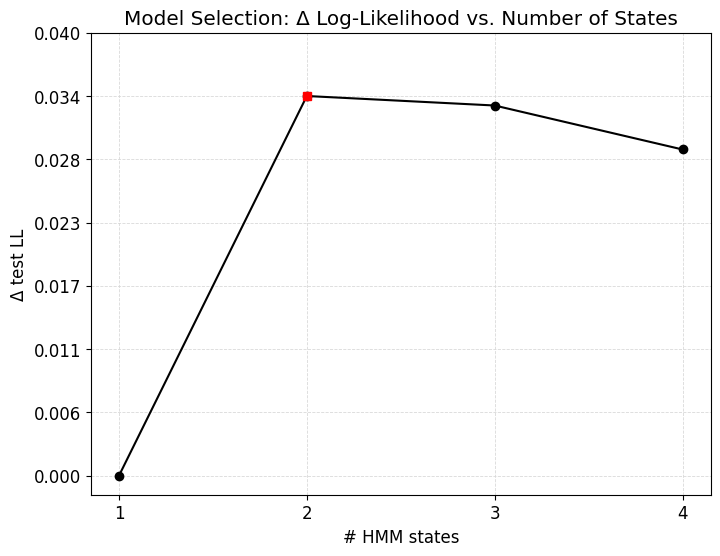

<Figure size 640x480 with 0 Axes>

Optimal number of states based on Δ test LL: 2


In [96]:
### selecting the max positive difference, not the ideal one

# mean test log-likelihood across folds for each K, using the best init per fold
# shape: (max_states,)
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1) # axis 1 is the correct for mean over folds to plot vs the number of states

# Δ test LL relative to K=1
delta_LL = mean_test_LL_by_K - mean_test_LL_by_K[0]

# pick optimal K as the index of the largest non-negative improvement (Δ)
positive_diffs = delta_LL.copy()
positive_diffs[~np.isfinite(positive_diffs)] = -np.inf  # guard against NaNs
positive_diffs[positive_diffs < 0] = -np.inf            # ignore negative gains
max_positive_idx = int(np.argmax(positive_diffs))       # 0-based index for K
optimal_num_states = max_positive_idx + 1               # convert to 1..K

# ---- Plot ----
fig, axG = plt.subplots(figsize=(8, 6))
axG.plot(np.arange(1, max_states + 1), delta_LL, 'r-o', label='Δ test log-likelihood', color='black')

# highlight optimal K
axG.plot(optimal_num_states, delta_LL[max_positive_idx], 'rs', label='Optimal state')

axG.set_xlabel('# HMM states')
axG.set_ylabel('Δ test LL', color='black')
axG.set_title('Model Selection: Δ Log-Likelihood vs. Number of States')

axG.set_xticks(np.arange(1, max_states + 1))

# y-ticks formatting
y_min = np.nanmin(delta_LL)
y_max = np.nanmax(delta_LL)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_tick_step = (y_max - y_min) / 6.0 if y_max > y_min else 1.0
y_ticks = np.arange(y_min, y_max + y_tick_step, y_tick_step)
axG.set_yticks(y_ticks)
axG.set_yticklabels([f'{y:.3f}' for y in y_ticks])
axG.tick_params(axis='y', colors='black')


plt.show()

axG.legend()

plt.tight_layout()
plt.show()

print(f"Optimal number of states based on Δ test LL: {optimal_num_states}")



Consecutive K comparisons (paired t-test on test LL across folds):
  K vs K+1  p_ttest
0      1→2   0.0049
1      2→3   0.0149
2      3→4   0.1361


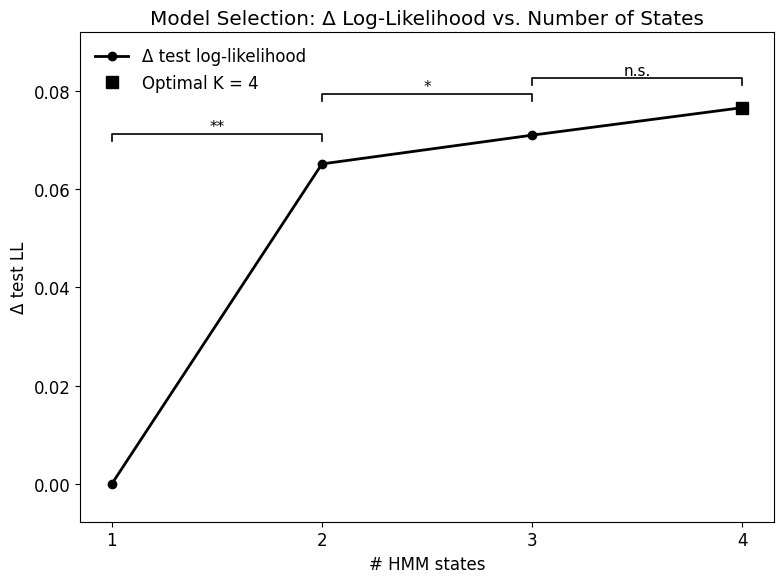

Optimal number of states (max mean test LL): 4


In [42]:
# ------------------------------------------------------------
# Inputs expected to already exist in your session:
#   - Best_test_LL: array shape (max_states, n_folds) with best-per-fold test LL
#   - max_states: int
# ------------------------------------------------------------

# ---- Compute Δ test LL vs K ----
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1)              # (K,)
delta_LL = mean_test_LL_by_K - mean_test_LL_by_K[0]               # Δ vs K=1

# Pick optimal K = argmax(mean test LL)  (threshold-free default)
optimal_num_states = int(np.nanargmax(mean_test_LL_by_K)) + 1

# ---- Paired tests between consecutive K and K+1 over folds ----
p_values_ttest = []
for k in range(max_states - 1):
    data_K  = Best_test_LL[k, :]
    data_K1 = Best_test_LL[k + 1, :]
    mask = np.isfinite(data_K) & np.isfinite(data_K1)
    if np.sum(mask) > 1:
        _, p_t = ttest_rel(data_K[mask], data_K1[mask])
    else:
        p_t = np.nan
    p_values_ttest.append(p_t)

# Table (optional print)
df_stats = pd.DataFrame({
    "K vs K+1": [f"{k+1}→{k+2}" for k in range(max_states - 1)],
    "p_ttest": p_values_ttest
})
print("\nConsecutive K comparisons (paired t-test on test LL across folds):")
print(df_stats.round(4))

# ---- Nice black styling ----
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.8",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.size": 12,
})

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ curve in black
ax.plot(Ks, delta_LL, marker='o', linestyle='-', linewidth=2, markersize=6, color='black', label='Δ test log-likelihood')

# Highlight optimal K (filled square)
ax.plot(optimal_num_states, delta_LL[optimal_num_states - 1],
        marker='s', markersize=9, linestyle='None', color='black', label=f'Optimal K = {optimal_num_states}')

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test LL')
ax.set_title('Model Selection: Δ Log-Likelihood vs. Number of States')

ax.set_xticks(Ks)

# y-ticks formatting and safe range
y_min = np.nanmin(delta_LL)
y_max = np.nanmax(delta_LL)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.2 * y_range)

# ---- Significance brackets & labels (black) ----
def sig_label(p):
    if not np.isfinite(p): return "n.s."
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
    ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom', fontsize=11, color='black')

base_offset = 0.06 * y_range    # baseline above the pair
stack_step  = 0.03 * y_range    # slight stagger to avoid overlaps
h_bracket   = 0.02 * y_range

for k, p in enumerate(p_values_ttest):
    x1, x2 = k + 1, k + 2
    pair_top = np.nanmax([delta_LL[k], delta_LL[k + 1]])
    y = pair_top + base_offset + (k % 2) * stack_step
    add_sig_bracket(ax, x1, x2, y, h_bracket, sig_label(p))
ax.grid(False)  # Turn off grid for cleaner look

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Optimal number of states (max mean test LL): {optimal_num_states}")


In [40]:
# Inputs:
# Best_test_LL: shape (max_states, n_folds), values are **bits per trial**
# max_states: int

mean_bpt = np.nanmean(Best_test_LL, axis=1)
sem_bpt  = np.nanstd(Best_test_LL, axis=1, ddof=1) / np.sqrt(np.sum(np.isfinite(Best_test_LL), axis=1))

# Threshold-free default: max mean bits/trial
K_max = int(np.nanargmax(mean_bpt)) + 1
best_val = mean_bpt[K_max - 1]
best_se  = sem_bpt[K_max - 1]

# 1-SE rule: smallest K within one SE of best
eligible = np.where(mean_bpt >= (best_val - best_se))[0]
K_1se = int(eligible[0]) + 1

# Paired tests between consecutive K and K+1
p_ttest = []
p_wilco = []
for k in range(max_states - 1):
    a = Best_test_LL[k,   :]
    b = Best_test_LL[k+1, :]
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) > 1:
        _, pt = ttest_rel(a[mask], b[mask])
        try:
            _, pw = wilcoxon(a[mask], b[mask])
        except ValueError:
            pw = np.nan
    else:
        pt, pw = np.nan, np.nan
    p_ttest.append(pt); p_wilco.append(pw)

# Evidence in bits for K vs K+1 (multiply mean Δ bits/trial by mean test trials per fold if you want totals)
# If you know per-fold test trial counts, replace with that; here we approximate using relative bits/trial only.
delta_consec = mean_bpt[1:] - mean_bpt[:-1]  # Δ bits/trial for K→K+1

print("Mean test bits/trial by K:", mean_bpt)
print("SEM by K:", sem_bpt)
print(f"Default (max mean bpt) K*: {K_max}")
print(f"1-SE rule K*: {K_1se}")
for k,(pt,pw,db) in enumerate(zip(p_ttest, p_wilco, delta_consec), start=1):
    print(f"K={k}→{k+1}: Δ={db:.6f} bits/trial, p_t={pt:.4g}, p_w={pw:.4g}")


Mean test bits/trial by K: [-0.60203022 -0.53693268 -0.53107822 -0.52548109]
SEM by K: [0.0217806  0.02474666 0.02465143 0.02512199]
Default (max mean bpt) K*: 4
1-SE rule K*: 2
K=1→2: Δ=0.065098 bits/trial, p_t=0.004897, p_w=0.25
K=2→3: Δ=0.005854 bits/trial, p_t=0.01492, p_w=0.25
K=3→4: Δ=0.005597 bits/trial, p_t=0.1361, p_w=0.25



Consecutive K comparisons (Δ bits/trial across folds):
  Pair (K→K+1)  Δ bits/trial  p (sign-flip)  reject Holm (α=0.05)  p_adj Holm
0          1→2      0.065098           0.25                 False        0.75
1          2→3      0.005854           0.25                 False        0.75
2          3→4      0.005597           0.25                 False        0.75

Selections:
  • Max mean bits/trial: K* = 4
  • 1-SE rule:           K* = 2
  • Last significant Δ:  K* = 1 (Holm-corrected)


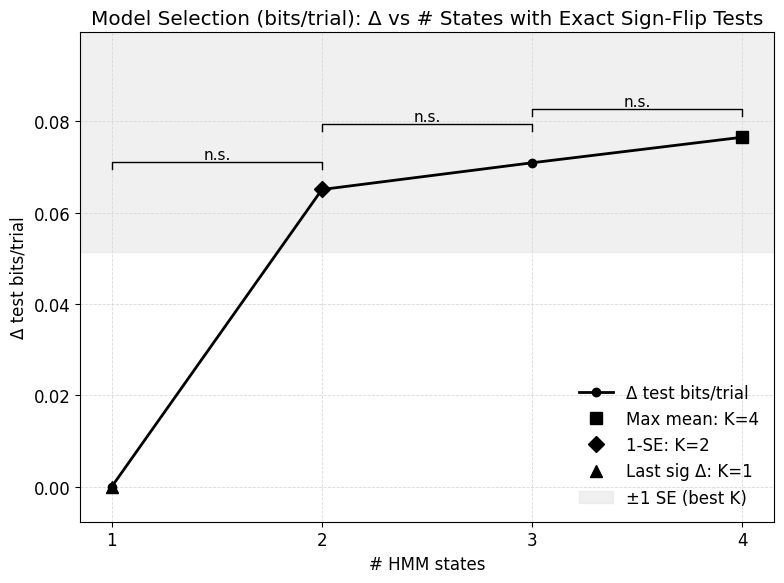

In [41]:
# ------------------------------------------------------------
# Inputs expected in scope from your pipeline:
#   - Best_test_LL: shape (max_states, n_folds), values are bits/trial (best init per fold)
#   - max_states: int
#   - nKfold: int (number of folds)
# ------------------------------------------------------------

# ---------- Helper: exact sign-flip permutation test (two-sided) ----------
def sign_flip_pvalue(diffs):
    """
    Exact two-sided sign-flip test for mean of paired differences.
    Works well for tiny sample sizes (e.g., 3 folds).
    diffs: 1D array of per-fold differences (K+1 - K) in bits/trial.
    Returns: p-value in [0,1].
    """
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    n = diffs.size
    if n == 0:
        return np.nan
    # observed statistic: absolute mean
    t_obs = np.abs(np.mean(diffs))
    # enumerate all 2^n sign flips
    # (for n>20 you'd Monte Carlo, but here n is tiny)
    count = 0
    total = 0
    for signs in product([-1.0, 1.0], repeat=n):
        total += 1
        t = np.abs(np.mean(diffs * np.array(signs)))
        if t >= t_obs - 1e-15:
            count += 1
    return count / total

# ---------- Stats over K ----------
mean_bpt = np.nanmean(Best_test_LL, axis=1)                  # (K,)
sem_bpt  = np.nanstd(Best_test_LL, axis=1, ddof=1) / np.sqrt(
    np.sum(np.isfinite(Best_test_LL), axis=1)
)

# Δ bits/trial vs K=1 (for plotting)
delta_bpt = mean_bpt - mean_bpt[0]

# Default (threshold-free): K with max mean bits/trial
K_max = int(np.nanargmax(mean_bpt)) + 1
best_val = mean_bpt[K_max - 1]
best_se  = sem_bpt[K_max - 1]

# 1-SE rule: smallest K whose mean ≥ (best − SE_best)
eligible = np.where(mean_bpt >= (best_val - best_se))[0]
K_1se = int(eligible[0]) + 1 if eligible.size else K_max

# Exact sign-flip tests for consecutive pairs (K -> K+1)
raw_p = []
for k in range(max_states - 1):
    diffs = Best_test_LL[k + 1, :] - Best_test_LL[k, :]  # per-fold Δ bits/trial
    mask = np.isfinite(diffs)
    if np.sum(mask) >= 1:  # need at least 1 fold with finite values
        p = sign_flip_pvalue(diffs[mask])
    else:
        p = np.nan
    raw_p.append(p)

# Holm–Bonferroni correction (more powerful than Bonferroni)
def holm_bonferroni(pvals):
    """
    Returns boolean array 'reject' after Holm correction at alpha=0.05,
    plus adjusted p-values.
    """
    pvals = np.array(pvals, dtype=float)
    m = np.sum(np.isfinite(pvals))
    if m == 0:
        return np.zeros_like(pvals, dtype=bool), pvals
    order = np.argsort(np.where(np.isfinite(pvals), pvals, np.inf))
    reject = np.zeros_like(pvals, dtype=bool)
    adj_p = np.full_like(pvals, np.nan, dtype=float)
    alpha = 0.05
    # step-down procedure
    for rank, idx in enumerate(order, start=1):
        if not np.isfinite(pvals[idx]):
            continue
        threshold = alpha / (m - rank + 1)
        if pvals[idx] <= threshold:
            reject[idx] = True
        # adjusted p-value (Holm) for reporting
        adj_p[idx] = max( (m - rank + 1) * pvals[idx], 0.0 )
    # enforce monotonicity on adjusted p's in sorted order
    # (optional cosmetic; not required for reject decisions)
    last = -np.inf
    for idx in order:
        if np.isfinite(adj_p[idx]):
            adj_p[idx] = max(adj_p[idx], last)
            last = adj_p[idx]
    return reject, adj_p

reject_holm, p_adj_holm = holm_bonferroni(raw_p)

# Choose K by "last significant improvement": pick the largest K such that K-1 -> K is significant
# Then prefer that K; if none significant, pick K=1 (or fall back to 1-SE)
sig_pairs = np.where(reject_holm)[0]  # indices of pairs K->K+1 that are significant
if sig_pairs.size > 0:
    K_last_sig = int(sig_pairs.max() + 2)   # pair index k corresponds to K=k+1
else:
    K_last_sig = 1

# ---------- Report ----------
df_tests = pd.DataFrame({
    "Pair (K→K+1)": [f"{k+1}→{k+2}" for k in range(max_states - 1)],
    "Δ bits/trial": np.round(mean_bpt[1:] - mean_bpt[:-1], 6),
    "p (sign-flip)": np.round(raw_p, 6),
    "reject Holm (α=0.05)": reject_holm,
    "p_adj Holm": np.round(p_adj_holm, 6),
})
print("\nConsecutive K comparisons (Δ bits/trial across folds):")
print(df_tests)

print(f"\nSelections:")
print(f"  • Max mean bits/trial: K* = {K_max}")
print(f"  • 1-SE rule:           K* = {K_1se}")
print(f"  • Last significant Δ:  K* = {K_last_sig} (Holm-corrected)")

# ---------- Plot in black with significance + 1-SE band ----------
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ vs K=1 curve
ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
        color='black', label='Δ test bits/trial')

# Mark selections
ax.plot(K_max,  delta_bpt[K_max - 1],  marker='s', markersize=9, color='black', linestyle='None',
        label=f'Max mean: K={K_max}')
ax.plot(K_1se,  delta_bpt[K_1se - 1],  marker='D', markersize=8, color='black', linestyle='None',
        label=f'1-SE: K={K_1se}')
ax.plot(K_last_sig, delta_bpt[K_last_sig - 1], marker='^', markersize=9, color='black', linestyle='None',
        label=f'Last sig Δ: K={K_last_sig}')

# 1-SE shaded band around best K’s mean (horizontal band at Δ for best K)
best_delta = delta_bpt[K_max - 1]
ax.axhspan(best_delta - best_se, best_delta + best_se, color='0.9', alpha=0.6, label='±1 SE (best K)')

# y-range
y_min = np.nanmin(delta_bpt)
y_max = np.nanmax(delta_bpt)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test bits/trial')
ax.set_title('Model Selection (bits/trial): Δ vs # States with Exact Sign-Flip Tests')
ax.set_xticks(Ks)

# significance helpers
def sig_label_from_p(p):
    if not np.isfinite(p): return "n.s."
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def add_sig_bracket(ax, x1, x2, y, h, text, weight=False):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.3 if weight else 1.0, c='black')
    ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom', fontsize=11, color='black')

# draw brackets between consecutive K’s using *adjusted* p-values for labeling
base_offset = 0.06 * y_range
stack_step  = 0.03 * y_range
h_bracket   = 0.02 * y_range
for k in range(max_states - 1):
    x1, x2 = k + 1, k + 2
    pair_top = np.nanmax([delta_bpt[k], delta_bpt[k + 1]])
    y = pair_top + base_offset + (k % 2) * stack_step
    lbl = sig_label_from_p(p_adj_holm[k])  # label by Holm-adjusted p
    add_sig_bracket(ax, x1, x2, y, h_bracket, lbl, weight=reject_holm[k])

ax.legend(frameon=False)
plt.tight_layout()
plt.show()


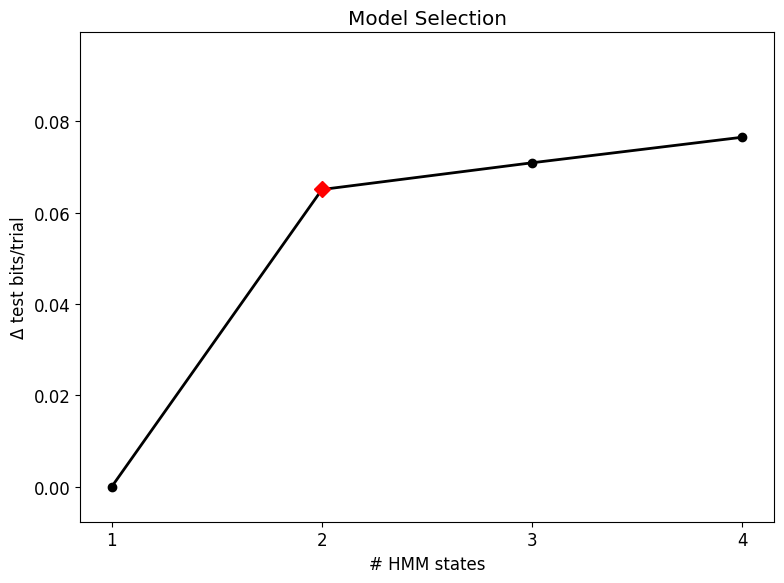

In [54]:
### Plot to be used

fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ vs K=1 curve
ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
        color='black', label='Δ test bits/trial')

# Mark selections

ax.plot(K_1se,  delta_bpt[K_1se - 1],  marker='D', markersize=8, color='red', linestyle='None',
        label=f'1-SE: K={K_1se}')



# y-range
y_min = np.nanmin(delta_bpt)
y_max = np.nanmax(delta_bpt)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test bits/trial')
ax.set_title('Model Selection')
ax.set_xticks(Ks)
ax.grid(False)  # Turn off grid for cleaner look



#ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### standard for 1 state and sticky with hyperparamters for the other states

In [99]:
def run_glmhmm_cv_model_selection(
    true_choices,
    inpts,
    *,
    max_states=4,
    n_splits=3,
    initializations=2,
    prior_sigma=2.0,
    prior_alpha=2.0,
    prior_kappa=0.0,
    num_iters=3000,
    tolerance=1e-1,
    n_jobs=-1,
    random_state=42,
):
    """
    Cross-validated GLM-HMM fit over #states (K=1..max_states), with multiple
    random initializations per (fold,K). Uses:
      - K=1: transitions="standard"
      - K>1: transitions="sticky" with (alpha=prior_alpha, kappa=prior_kappa)
    Observation model uses "input_driven_obs" with Gaussian prior_sigma on weights.

    Performance is reported in **bits per trial**.

    Parameters
    ----------
    true_choices : list of np.ndarray
        One array per session, shape (T_i,) or (T_i,1), integer categories.
    inpts : list of np.ndarray
        One array per session, shape (T_i, M), inputs for GLM.
    max_states : int
    n_splits : int
    initializations : int
    prior_sigma : float
        Prior std for GLM weights (observations).
    prior_alpha : float
        Sticky transition Dirichlet concentration.
    prior_kappa : float
        Sticky self-transition boost.
    num_iters : int
        EM iterations.
    tolerance : float
        EM tolerance.
    n_jobs : int
        Parallel jobs for joblib.
    random_state : int

    Returns
    -------
    results : dict
        {
          "Best_HMM":            (max_states, n_splits) object array of best models per (K, fold),
          "Best_train_bpt":      (max_states, n_splits) float array, best train bits/trial,
          "Best_test_bpt":       (max_states, n_splits) float array, best test bits/trial,
          "AllInits_test_bpt":   (initializations, max_states, n_splits) float array,
          "mean_test_bpt_by_K":  (max_states,) float array,
          "selected_num_states": int (plateau selection),
          "Kstar_models":        list of HMMs (best per fold at K*),
          "Kstar_train_bpt":     (n_splits,) float array,
          "Kstar_test_bpt":      (n_splits,) float array,
          "Best_overall_HMM":    HMM (best fold at K*),
        }
    """
    LOG2 = np.log(2.0)

    def _fit_single_init(K, training_inpts, training_choices, test_inpts, test_choices, seed=None):
        # Shapes/dtypes
        training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
        test_choices = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

        num_categories = int(len(np.unique(np.concatenate(training_choices))))
        input_dim = int(training_inpts[0].shape[1])

        if seed is not None:
            np.random.seed(seed)

        # Build HMM
        if K == 1:
            hmm = ssm.HMM(
                K=1,
                D=1,
                M=input_dim,
                observations="input_driven_obs",
                observation_kwargs=dict(C=num_categories, prior_sigma=prior_sigma),
                transitions="standard",
            )
        else:
            hmm = ssm.HMM(
                K=K,
                D=1,
                M=input_dim,
                observations="input_driven_obs",
                observation_kwargs=dict(C=num_categories, prior_sigma=prior_sigma),
                transitions="standard",
                #transition_kwargs=dict(alpha=prior_alpha, kappa=prior_kappa),
            )

        # Fit
        train_lls = hmm.fit(
            training_choices,
            inputs=training_inpts,
            method="em",
            num_iters=num_iters,
            tolerance=tolerance,
        )

        # Bits per trial
        n_train = int(np.concatenate(training_inpts).shape[0])
        n_test = int(np.concatenate(test_inpts).shape[0])
        train_bpt = (train_lls[-1] / n_train) / LOG2
        test_bpt = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2
        return hmm, train_bpt, test_bpt

    @contextmanager
    def tqdm_joblib(tqdm_object):
        from joblib import parallel

        class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
            def __call__(self, *args, **kwargs):
                tqdm_object.update(n=self.batch_size)
                return super().__call__(*args, **kwargs)

        old_callback = parallel.BatchCompletionCallBack
        parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
        try:
            yield tqdm_object
        finally:
            parallel.BatchCompletionCallBack = old_callback
            tqdm_object.close()

    # CV setup
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Allocate outputs
    Best_HMM = np.full((max_states, n_splits), None, dtype=object)
    Best_train_bpt = np.full((max_states, n_splits), np.nan, dtype=float)
    Best_test_bpt = np.full((max_states, n_splits), np.nan, dtype=float)
    AllInits_test_bpt = np.full((initializations, max_states, n_splits), np.nan, dtype=float)

    # Prepare jobs
    jobs = []
    splits = list(kf.split(true_choices))
    for fold_id, (train_index, test_index) in enumerate(splits):
        training_choices = [true_choices[i] for i in train_index]
        test_choices = [true_choices[i] for i in test_index]
        training_inpts = [inpts[i] for i in train_index]
        test_inpts = [inpts[i] for i in test_index]

        for K in range(1, max_states + 1):
            for z in range(initializations):
                seed = 10_000 * fold_id + 100 * K + z
                jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

    # Run
    def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
        hmm, tr_bpt, te_bpt = _fit_single_init(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
        return fold_id, K, z, hmm, tr_bpt, te_bpt

    with tqdm_joblib(tqdm(total=len(jobs), desc="Fitting GLM-HMMs (CV × K × inits)")):
        results = Parallel(n_jobs=n_jobs, verbose=0)(delayed(_run_one)(*args) for args in jobs)

    # Collect best init per (K, fold)
    for fold_id, K, z, hmm, tr_bpt, te_bpt in results:
        AllInits_test_bpt[z, K - 1, fold_id] = te_bpt
        if np.isnan(Best_test_bpt[K - 1, fold_id]) or te_bpt > Best_test_bpt[K - 1, fold_id]:
            Best_test_bpt[K - 1, fold_id] = te_bpt
            Best_train_bpt[K - 1, fold_id] = tr_bpt
            Best_HMM[K - 1, fold_id] = hmm

    # Model selection (plateau helper)
    def _plateau(x, threshold=0.001):
        diffs = np.diff(x)
        ind = np.where(diffs > threshold)[0]
        return ind[np.argmax(x[ind + 1])] + 1 if len(ind) > 0 else 1

    mean_test_bpt_by_K = np.nanmean(Best_test_bpt, axis=1)  # (max_states,)
    selected_num_states = _plateau(mean_test_bpt_by_K)

    Kstar = selected_num_states
    Kstar_models = [Best_HMM[Kstar - 1, f] for f in range(n_splits)]
    Kstar_test_bpt = Best_test_bpt[Kstar - 1, :]
    Kstar_train_bpt = Best_train_bpt[Kstar - 1, :]
    best_fold_idx = int(np.nanargmax(Kstar_test_bpt))
    Best_overall_HMM = Kstar_models[best_fold_idx]

    return {
        "Best_HMM": Best_HMM,
        "Best_train_bpt": Best_train_bpt,
        "Best_test_bpt": Best_test_bpt,
        "AllInits_test_bpt": AllInits_test_bpt,
        "mean_test_bpt_by_K": mean_test_bpt_by_K,
        "selected_num_states": int(selected_num_states),
        "Kstar_models": Kstar_models,
        "Kstar_train_bpt": Kstar_train_bpt,
        "Kstar_test_bpt": Kstar_test_bpt,
        "Best_overall_HMM": Best_overall_HMM,
    }



In [103]:
import ssm 

# ---- Hyperparameters you provide ----
prior_sigma = 2.0   # Prior std for GLM weights (observations)
prior_alpha = 2.0   # Sticky transition prior strength
prior_kappa = 0.0   # Extra self-transition boost (you set to 0)

LOG2 = np.log(2.0)

def MLE_hmm_fit(num_states, training_inpts, training_choices, test_inpts, test_choices, seed=None):
    """
    Fit a GLM-HMM and return the fitted model + train/test log-likelihood
    in **bits per trial**.

    Transitions:
      - K=1: standard transitions
      - K>1: sticky transitions with (alpha=prior_alpha, kappa=prior_kappa)

    Observations:
      - input_driven_obs with C categories and Gaussian prior on GLM weights with prior_sigma
    """
    if seed is not None:
        np.random.seed(seed)

    # Ensure shapes/dtypes
    training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
    test_choices     = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

    num_categories = int(len(np.unique(np.concatenate(training_choices))))
    input_dim = int(training_inpts[0].shape[1])

    # ----- Build HMM depending on K -----
    if num_states == 1:
        hmm = ssm.HMM(
            K=1,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories, prior_sigma=prior_sigma),
            transitions="standard",
        )
    else:
        hmm = ssm.HMM(
            K=num_states,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories, prior_sigma=prior_sigma),
            transitions="standard",
            #transition_kwargs=dict(alpha=prior_alpha, kappa=prior_kappa),
        )

    # ----- Fit -----
    train_lls = hmm.fit(
        training_choices,
        inputs=training_inpts,
        method="em",
        num_iters=3000,
        tolerance=1e-1,
    )

    # ----- Bits per trial -----
    n_train = int(np.concatenate(training_inpts).shape[0])
    n_test  = int(np.concatenate(test_inpts).shape[0])

    train_bpt = (train_lls[-1] / n_train) / LOG2
    test_bpt  = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2

    return hmm, train_bpt, test_bpt




# -----------------------------
# TQDM helper for joblib
# -----------------------------
@contextmanager
def tqdm_joblib(tqdm_object):
    from joblib import parallel

    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# -----------------------------
# Cross-validated sweep
# -----------------------------
# User-provided:
# true_choices : list of arrays, one per session
# inpts        : list of arrays, one per session
# (Optional) data: list of DataFrames per session (not used anymore)

max_states = 4
nKfold = 3
initializations = 2  # many inits per (fold, K)
kf = KFold(n_splits=nKfold, shuffle=True, random_state=42)

# Pre-allocate containers for the "best-per-fold" models and LLs
Best_HMM = np.full((max_states, nKfold), None, dtype=object)
Best_train_LL = np.full((max_states, nKfold), np.nan, dtype=float)
Best_test_LL = np.full((max_states, nKfold), np.nan, dtype=float)

# Also store all-inits test LLs if you want to inspect dispersion later
AllInits_test_LL = np.full((initializations, max_states, nKfold), np.nan, dtype=float)

# Prepare all jobs: each job = (fold, K, init_seed, train/test splits)
jobs = []
for fold_id, (train_index, test_index) in enumerate(kf.split(true_choices)):
    training_choices = [true_choices[i] for i in train_index]
    test_choices = [true_choices[i] for i in test_index]
    training_inpts = [inpts[i] for i in train_index]
    test_inpts = [inpts[i] for i in test_index]

    # set deterministic seeds per (fold, K, init)
    for K in range(1, max_states + 1):
        for z in range(initializations):
            seed = 10_000 * fold_id + 100 * K + z
            jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

# Run all fits in parallel
def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
    hmm, tr_ll, te_ll = MLE_hmm_fit(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
    return fold_id, K, z, hmm, tr_ll, te_ll

with tqdm_joblib(tqdm(total=len(jobs), desc="Fitting GLM-HMMs (CV × K × inits)")):
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(_run_one)(*args) for args in jobs
    )

# Collect results and pick the best init per (fold, K) by test LL
for fold_id, K, z, hmm, tr_ll, te_ll in results:
    AllInits_test_LL[z, K - 1, fold_id] = te_ll
    # If this is the best so far for (K, fold), update
    if np.isnan(Best_test_LL[K - 1, fold_id]) or te_ll > Best_test_LL[K - 1, fold_id]:
        Best_test_LL[K - 1, fold_id] = te_ll
        Best_train_LL[K - 1, fold_id] = tr_ll
        Best_HMM[K - 1, fold_id] = hmm

# -----------------------------
# Model selection over K
# -----------------------------
def plateau(data_1d, threshold=0.001):
    """
    Given a 1D array of scores over K, return the K at which the last
    improvement above threshold occurs; if none, return 1.
    """
    diffs = np.diff(data_1d)
    ind = np.where(diffs > threshold)[0]
    return ind[np.argmax(data_1d[ind + 1])] + 1 if len(ind) > 0 else 1

# Average test LL across folds for each K using the best-inits
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1)  # shape: (max_states,)
selected_num_states = plateau(mean_test_LL_by_K)

# Example: retrieve the best model per fold at the selected K
Kstar = selected_num_states
HMMs_per_fold = [Best_HMM[Kstar - 1, f] for f in range(nKfold)]
TestLL_per_fold = Best_test_LL[Kstar - 1, :]
TrainLL_per_fold = Best_train_LL[Kstar - 1, :]

# If you want a single representative model (e.g., best fold at K*):
best_fold_idx = int(np.nanargmax(TestLL_per_fold))
Best_overall_HMM = HMMs_per_fold[best_fold_idx]

# At this point:
# - Best_HMM[K-1, fold] is the best-initialization model for that (K, fold)
# - Best_test_LL[K-1, fold] is its normalized test LL
# - selected_num_states is your chosen K
# - Best_overall_HMM is the single best model at K*

Fitting GLM-HMMs (CV × K × inits): 100%|███████████████████████████████████████████████| 24/24 [00:10<00:00,  2.26it/s]


In [92]:

def plot_glmhmm_model_selection(
    Best_test_LL: np.ndarray,
    *,
    alpha: float = 0.05,
    title: str = "Model Selection (bits/trial): Δ vs # States with Exact Sign-Flip Tests",
    show: bool = True,
):
    """
    Plot Δ test bits/trial vs number of states with exact sign-flip tests and Holm–Bonferroni correction.

    Parameters
    ----------
    Best_test_LL : np.ndarray
        Shape (max_states, n_folds). Test performance in **bits per trial** for the
        best init per (K, fold).
    alpha : float, optional
        Familywise error rate for Holm–Bonferroni correction (default 0.05).
    title : str, optional
        Plot title.
    show : bool, optional
        Whether to call plt.show().

    Returns
    -------
    result : dict
        {
            'mean_bpt': np.ndarray,          # (max_states,)
            'sem_bpt': np.ndarray,           # (max_states,)
            'delta_bpt': np.ndarray,         # (max_states,) Δ vs K=1
            'K_max': int,                    # argmax mean bits/trial
            'K_1se': int,                    # 1-SE rule selection
            'K_last_sig': int,               # last significant Δ after Holm
            'df_tests': pd.DataFrame,        # per-pair stats table
            'fig': matplotlib.figure.Figure,
            'ax': matplotlib.axes.Axes,
        }
    """

    Best_test_LL = np.asarray(Best_test_LL, dtype=float)
    if Best_test_LL.ndim != 2:
        raise ValueError("Best_test_LL must be 2D (max_states, n_folds).")

    max_states, n_folds = Best_test_LL.shape
    Ks = np.arange(1, max_states + 1)

    # ---------- Helper: exact sign-flip permutation test (two-sided) ----------
    def sign_flip_pvalue(diffs):
        """
        Exact two-sided sign-flip test for mean of paired differences.
        Works well for tiny sample sizes (e.g., 3 folds).
        diffs: 1D array of per-fold differences (K+1 - K) in bits/trial.
        Returns: p-value in [0,1].
        """
        diffs = np.asarray(diffs, dtype=float)
        diffs = diffs[np.isfinite(diffs)]
        n = diffs.size
        if n == 0:
            return np.nan
        t_obs = np.abs(np.mean(diffs))
        count = 0
        total = 0
        for signs in product([-1.0, 1.0], repeat=n):
            total += 1
            t = np.abs(np.mean(diffs * np.array(signs)))
            if t >= t_obs - 1e-15:
                count += 1
        return count / total

    # ---------- Helper: Holm–Bonferroni ----------
    def holm_bonferroni(pvals, alpha=0.05):
        pvals = np.array(pvals, dtype=float)
        m = np.sum(np.isfinite(pvals))
        if m == 0:
            return np.zeros_like(pvals, dtype=bool), pvals
        order = np.argsort(np.where(np.isfinite(pvals), pvals, np.inf))
        reject = np.zeros_like(pvals, dtype=bool)
        adj_p = np.full_like(pvals, np.nan, dtype=float)

        # step-down
        for rank, idx in enumerate(order, start=1):
            if not np.isfinite(pvals[idx]):
                continue
            threshold = alpha / (m - rank + 1)
            if pvals[idx] <= threshold:
                reject[idx] = True
            adj_p[idx] = max((m - rank + 1) * pvals[idx], 0.0)

        # monotone adjusted p-values (optional cosmetic)
        last = -np.inf
        for idx in order:
            if np.isfinite(adj_p[idx]):
                adj_p[idx] = max(adj_p[idx], last)
                last = adj_p[idx]
        return reject, adj_p

    # ---------- Stats over K ----------
    mean_bpt = np.nanmean(Best_test_LL, axis=1)  # (K,)
    sem_bpt = np.nanstd(Best_test_LL, axis=1, ddof=1) / np.sqrt(
        np.sum(np.isfinite(Best_test_LL), axis=1)
    )

    # Δ vs K=1
    delta_bpt = mean_bpt - mean_bpt[0]

    # Selections
    K_max = int(np.nanargmax(mean_bpt)) + 1
    best_val = mean_bpt[K_max - 1]
    best_se = sem_bpt[K_max - 1]
    eligible = np.where(mean_bpt >= (best_val - best_se))[0]
    K_1se = int(eligible[0]) + 1 if eligible.size else K_max

    # Sign-flip tests for consecutive pairs
    raw_p = []
    for k in range(max_states - 1):
        diffs = Best_test_LL[k + 1, :] - Best_test_LL[k, :]
        mask = np.isfinite(diffs)
        p = sign_flip_pvalue(diffs[mask]) if np.sum(mask) >= 1 else np.nan
        raw_p.append(p)

    reject_holm, p_adj_holm = holm_bonferroni(raw_p, alpha=alpha)
    sig_pairs = np.where(reject_holm)[0]
    K_last_sig = int(sig_pairs.max() + 2) if sig_pairs.size > 0 else 1

    # Table
    df_tests = pd.DataFrame({
        "Pair (K→K+1)": [f"{k+1}→{k+2}" for k in range(max_states - 1)],
        "Δ bits/trial": np.round(mean_bpt[1:] - mean_bpt[:-1], 6),
        "p (sign-flip)": np.round(raw_p, 6),
        "reject Holm (α=%.3g)" % alpha: reject_holm,
        "p_adj Holm": np.round(p_adj_holm, 6),
    })

    # ---------- Plot (black) ----------
    plt.rcParams.update({
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "grid.color": "0.85",
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "font.size": 12,
    })

    fig, ax = plt.subplots(figsize=(8, 6))

    # Δ curve
    ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
            color='black', label='Δ test bits/trial')

    # Mark selections
    ax.plot(K_max, delta_bpt[K_max - 1],
            marker='s', markersize=9, color='black', linestyle='None',
            label=f'Max mean: K={K_max}')
    ax.plot(K_1se, delta_bpt[K_1se - 1],
            marker='D', markersize=8, color='black', linestyle='None',
            label=f'1-SE: K={K_1se}')
    ax.plot(K_last_sig, delta_bpt[K_last_sig - 1],
            marker='^', markersize=9, color='black', linestyle='None',
            label=f'Last sig Δ: K={K_last_sig}')

    # 1-SE shaded band (around best K’s Δ)
    best_delta = delta_bpt[K_max - 1]
    ax.axhspan(best_delta - best_se, best_delta + best_se, color='0.9', alpha=0.6, label='±1 SE (best K)')

    # y-range and ticks
    y_min = np.nanmin(delta_bpt)
    y_max = np.nanmax(delta_bpt)
    if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
        y_min, y_max = 0.0, 1.0
    y_range = max(y_max - y_min, 1e-6)
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

    ax.set_xlabel('# HMM states')
    ax.set_ylabel('Δ test bits/trial')
    ax.set_title(title)
    ax.set_xticks(Ks)

    # significance helpers
    def sig_label_from_p(p):
        if not np.isfinite(p): return "n.s."
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "n.s."

    def add_sig_bracket(ax, x1, x2, y, h, text, weight=False):
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.3 if weight else 1.0, c='black')
        ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom', fontsize=11, color='black')

    # brackets between consecutive K’s using Holm-adjusted p’s
    base_offset = 0.06 * y_range
    stack_step  = 0.03 * y_range
    h_bracket   = 0.02 * y_range
    for k in range(max_states - 1):
        x1, x2 = k + 1, k + 2
        pair_top = np.nanmax([delta_bpt[k], delta_bpt[k + 1]])
        y = pair_top + base_offset + (k % 2) * stack_step
        lbl = sig_label_from_p(p_adj_holm[k])
        add_sig_bracket(ax, x1, x2, y, h_bracket, lbl, weight=reject_holm[k])

    ax.legend(frameon=False)
    plt.tight_layout()
    if show:
        plt.show()

    return {
        "mean_bpt": mean_bpt,
        "sem_bpt": sem_bpt,
        "delta_bpt": delta_bpt,
        "K_max": K_max,
        "K_1se": K_1se,
        "K_last_sig": K_last_sig,
        "df_tests": df_tests,
        "fig": fig,
        "ax": ax,
    }


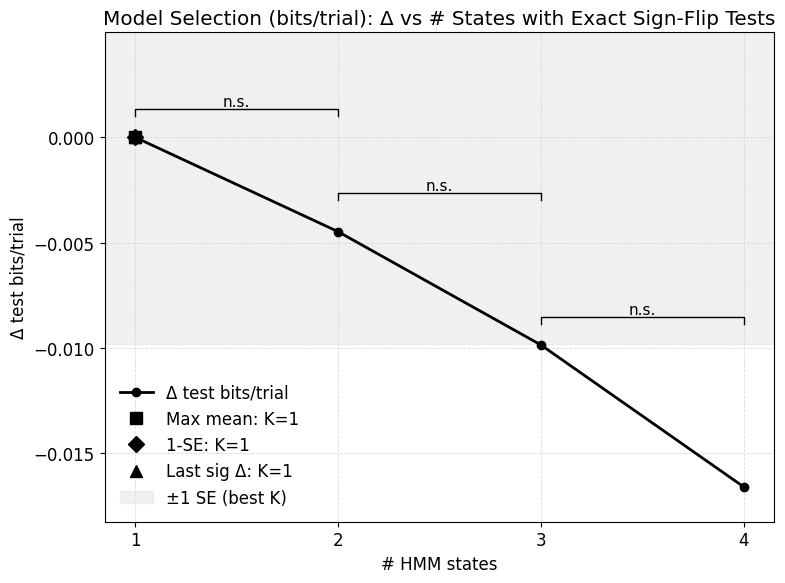

K_max: 1
K_1se: 1
K_last_sig: 1
  Pair (K→K+1)  Δ bits/trial  p (sign-flip)  reject Holm (α=0.05)  p_adj Holm
0          1→2     -0.004474           0.25                 False        0.75
1          2→3     -0.005374           0.25                 False        0.75
2          3→4     -0.006733           0.25                 False        0.75


In [98]:
out = plot_glmhmm_model_selection(Best_test_LL, alpha=0.05, show=True)
print("K_max:", out["K_max"])
print("K_1se:", out["K_1se"])
print("K_last_sig:", out["K_last_sig"])
print(out["df_tests"])


In [110]:

LOG2 = np.log(2.0)

def MLE_hmm_fit(num_states, training_inpts, training_choices, test_inpts, test_choices, seed=None):
    """
    Fit a GLM-HMM and return the fitted model + train/test log-likelihood
    in **bits per trial**.
    """
    if seed is not None:
        np.random.seed(seed)

    # Ensure shapes/dtypes
    training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
    test_choices     = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

    num_categories = len(np.unique(np.concatenate(training_choices)))
    input_dim = training_inpts[0].shape[1]

    hmm = ssm.HMM(
        K=num_states,
        D=1,
        M=input_dim,
        observations="input_driven_obs",
        observation_kwargs=dict(C=num_categories),
        transitions="standard",
    )

    train_lls = hmm.fit(
        training_choices,
        inputs=training_inpts,
        method="em",
        num_iters=3000,
        tolerance=1e-1,
    )

    n_train = np.concatenate(training_inpts).shape[0]
    n_test  = np.concatenate(test_inpts).shape[0]

    # Convert from nats/trial → bits/trial
    train_bpt = (train_lls[-1] / n_train) / LOG2
    test_bpt  = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2

    return hmm, train_bpt, test_bpt



# -----------------------------
# TQDM helper for joblib
# -----------------------------
@contextmanager
def tqdm_joblib(tqdm_object):
    from joblib import parallel

    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# -----------------------------
# Cross-validated sweep
# -----------------------------
# User-provided:
# true_choices : list of arrays, one per session
# inpts        : list of arrays, one per session
# (Optional) data: list of DataFrames per session (not used anymore)

max_states = 4
nKfold = 3
initializations = 2  # many inits per (fold, K)
kf = KFold(n_splits=nKfold, shuffle=True, random_state=42)

# Pre-allocate containers for the "best-per-fold" models and LLs
Best_HMM = np.full((max_states, nKfold), None, dtype=object)
Best_train_LL = np.full((max_states, nKfold), np.nan, dtype=float)
Best_test_LL = np.full((max_states, nKfold), np.nan, dtype=float)

# Also store all-inits test LLs if you want to inspect dispersion later
AllInits_test_LL = np.full((initializations, max_states, nKfold), np.nan, dtype=float)

# Prepare all jobs: each job = (fold, K, init_seed, train/test splits)
jobs = []
for fold_id, (train_index, test_index) in enumerate(kf.split(true_choices)):
    training_choices = [true_choices[i] for i in train_index]
    test_choices = [true_choices[i] for i in test_index]
    training_inpts = [inpts[i] for i in train_index]
    test_inpts = [inpts[i] for i in test_index]

    # set deterministic seeds per (fold, K, init)
    for K in range(1, max_states + 1):
        for z in range(initializations):
            seed = 10_000 * fold_id + 100 * K + z
            jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

# Run all fits in parallel
def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
    hmm, tr_ll, te_ll = MLE_hmm_fit(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
    return fold_id, K, z, hmm, tr_ll, te_ll

with tqdm_joblib(tqdm(total=len(jobs), desc="Fitting GLM-HMMs (CV × K × inits)")):
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(_run_one)(*args) for args in jobs
    )

# Collect results and pick the best init per (fold, K) by test LL
for fold_id, K, z, hmm, tr_ll, te_ll in results:
    AllInits_test_LL[z, K - 1, fold_id] = te_ll
    # If this is the best so far for (K, fold), update
    if np.isnan(Best_test_LL[K - 1, fold_id]) or te_ll > Best_test_LL[K - 1, fold_id]:
        Best_test_LL[K - 1, fold_id] = te_ll
        Best_train_LL[K - 1, fold_id] = tr_ll
        Best_HMM[K - 1, fold_id] = hmm

# -----------------------------
# Model selection over K
# -----------------------------
def plateau(data_1d, threshold=0.001):
    """
    Given a 1D array of scores over K, return the K at which the last
    improvement above threshold occurs; if none, return 1.
    """
    diffs = np.diff(data_1d)
    ind = np.where(diffs > threshold)[0]
    return ind[np.argmax(data_1d[ind + 1])] + 1 if len(ind) > 0 else 1

# Average test LL across folds for each K using the best-inits
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1)  # shape: (max_states,)
selected_num_states = plateau(mean_test_LL_by_K)

# Example: retrieve the best model per fold at the selected K
Kstar = selected_num_states
HMMs_per_fold = [Best_HMM[Kstar - 1, f] for f in range(nKfold)]
TestLL_per_fold = Best_test_LL[Kstar - 1, :]
TrainLL_per_fold = Best_train_LL[Kstar - 1, :]

# If you want a single representative model (e.g., best fold at K*):
best_fold_idx = int(np.nanargmax(TestLL_per_fold))
Best_overall_HMM = HMMs_per_fold[best_fold_idx]

# At this point:
# - Best_HMM[K-1, fold] is the best-initialization model for that (K, fold)
# - Best_test_LL[K-1, fold] is its normalized test LL
# - selected_num_states is your chosen K
# - Best_overall_HMM is the single best model at K*

Fitting GLM-HMMs (CV × K × inits): 100%|███████████████████████████████████████████████| 24/24 [01:01<00:00,  2.56s/it]



Consecutive K comparisons (Δ bits/trial across folds):
  Pair (K→K+1)  Δ bits/trial  p (sign-flip)  reject Holm (α=0.05)  p_adj Holm
0          1→2      0.034173           0.25                 False        0.75
1          2→3     -0.000855           0.75                 False        1.50
2          3→4     -0.003958           0.75                 False        1.50

Selections:
  • Max mean bits/trial: K* = 2
  • 1-SE rule:           K* = 2
  • Last significant Δ:  K* = 1 (Holm-corrected)


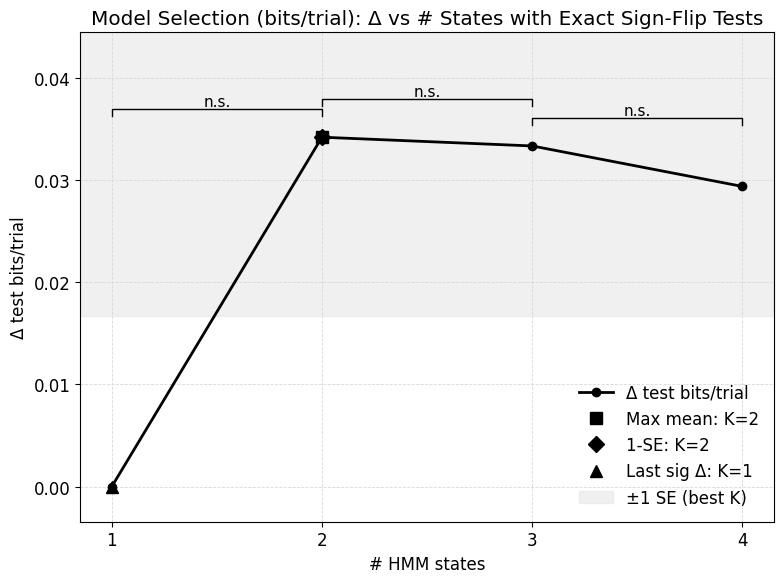

In [111]:
# ------------------------------------------------------------
# Inputs expected in scope from your pipeline:
#   - Best_test_LL: shape (max_states, n_folds), values are bits/trial (best init per fold)
#   - max_states: int
#   - nKfold: int (number of folds)
# ------------------------------------------------------------

# ---------- Helper: exact sign-flip permutation test (two-sided) ----------
def sign_flip_pvalue(diffs):
    """
    Exact two-sided sign-flip test for mean of paired differences.
    Works well for tiny sample sizes (e.g., 3 folds).
    diffs: 1D array of per-fold differences (K+1 - K) in bits/trial.
    Returns: p-value in [0,1].
    """
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    n = diffs.size
    if n == 0:
        return np.nan
    # observed statistic: absolute mean
    t_obs = np.abs(np.mean(diffs))
    # enumerate all 2^n sign flips
    # (for n>20 you'd Monte Carlo, but here n is tiny)
    count = 0
    total = 0
    for signs in product([-1.0, 1.0], repeat=n):
        total += 1
        t = np.abs(np.mean(diffs * np.array(signs)))
        if t >= t_obs - 1e-15:
            count += 1
    return count / total

# ---------- Stats over K ----------
mean_bpt = np.nanmean(Best_test_LL, axis=1)                  # (K,)
sem_bpt  = np.nanstd(Best_test_LL, axis=1, ddof=1) / np.sqrt(
    np.sum(np.isfinite(Best_test_LL), axis=1)
)

# Δ bits/trial vs K=1 (for plotting)
delta_bpt = mean_bpt - mean_bpt[0]

# Default (threshold-free): K with max mean bits/trial
K_max = int(np.nanargmax(mean_bpt)) + 1
best_val = mean_bpt[K_max - 1]
best_se  = sem_bpt[K_max - 1]

# 1-SE rule: smallest K whose mean ≥ (best − SE_best)
eligible = np.where(mean_bpt >= (best_val - best_se))[0]
K_1se = int(eligible[0]) + 1 if eligible.size else K_max

# Exact sign-flip tests for consecutive pairs (K -> K+1)
raw_p = []
for k in range(max_states - 1):
    diffs = Best_test_LL[k + 1, :] - Best_test_LL[k, :]  # per-fold Δ bits/trial
    mask = np.isfinite(diffs)
    if np.sum(mask) >= 1:  # need at least 1 fold with finite values
        p = sign_flip_pvalue(diffs[mask])
    else:
        p = np.nan
    raw_p.append(p)

# Holm–Bonferroni correction (more powerful than Bonferroni)
def holm_bonferroni(pvals):
    """
    Returns boolean array 'reject' after Holm correction at alpha=0.05,
    plus adjusted p-values.
    """
    pvals = np.array(pvals, dtype=float)
    m = np.sum(np.isfinite(pvals))
    if m == 0:
        return np.zeros_like(pvals, dtype=bool), pvals
    order = np.argsort(np.where(np.isfinite(pvals), pvals, np.inf))
    reject = np.zeros_like(pvals, dtype=bool)
    adj_p = np.full_like(pvals, np.nan, dtype=float)
    alpha = 0.05
    # step-down procedure
    for rank, idx in enumerate(order, start=1):
        if not np.isfinite(pvals[idx]):
            continue
        threshold = alpha / (m - rank + 1)
        if pvals[idx] <= threshold:
            reject[idx] = True
        # adjusted p-value (Holm) for reporting
        adj_p[idx] = max( (m - rank + 1) * pvals[idx], 0.0 )
    # enforce monotonicity on adjusted p's in sorted order
    # (optional cosmetic; not required for reject decisions)
    last = -np.inf
    for idx in order:
        if np.isfinite(adj_p[idx]):
            adj_p[idx] = max(adj_p[idx], last)
            last = adj_p[idx]
    return reject, adj_p

reject_holm, p_adj_holm = holm_bonferroni(raw_p)

# Choose K by "last significant improvement": pick the largest K such that K-1 -> K is significant
# Then prefer that K; if none significant, pick K=1 (or fall back to 1-SE)
sig_pairs = np.where(reject_holm)[0]  # indices of pairs K->K+1 that are significant
if sig_pairs.size > 0:
    K_last_sig = int(sig_pairs.max() + 2)   # pair index k corresponds to K=k+1
else:
    K_last_sig = 1

# ---------- Report ----------
df_tests = pd.DataFrame({
    "Pair (K→K+1)": [f"{k+1}→{k+2}" for k in range(max_states - 1)],
    "Δ bits/trial": np.round(mean_bpt[1:] - mean_bpt[:-1], 6),
    "p (sign-flip)": np.round(raw_p, 6),
    "reject Holm (α=0.05)": reject_holm,
    "p_adj Holm": np.round(p_adj_holm, 6),
})
print("\nConsecutive K comparisons (Δ bits/trial across folds):")
print(df_tests)

print(f"\nSelections:")
print(f"  • Max mean bits/trial: K* = {K_max}")
print(f"  • 1-SE rule:           K* = {K_1se}")
print(f"  • Last significant Δ:  K* = {K_last_sig} (Holm-corrected)")

# ---------- Plot in black with significance + 1-SE band ----------
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ vs K=1 curve
ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
        color='black', label='Δ test bits/trial')

# Mark selections
ax.plot(K_max,  delta_bpt[K_max - 1],  marker='s', markersize=9, color='black', linestyle='None',
        label=f'Max mean: K={K_max}')
ax.plot(K_1se,  delta_bpt[K_1se - 1],  marker='D', markersize=8, color='black', linestyle='None',
        label=f'1-SE: K={K_1se}')
ax.plot(K_last_sig, delta_bpt[K_last_sig - 1], marker='^', markersize=9, color='black', linestyle='None',
        label=f'Last sig Δ: K={K_last_sig}')

# 1-SE shaded band around best K’s mean (horizontal band at Δ for best K)
best_delta = delta_bpt[K_max - 1]
ax.axhspan(best_delta - best_se, best_delta + best_se, color='0.9', alpha=0.6, label='±1 SE (best K)')

# y-range
y_min = np.nanmin(delta_bpt)
y_max = np.nanmax(delta_bpt)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test bits/trial')
ax.set_title('Model Selection (bits/trial): Δ vs # States with Exact Sign-Flip Tests')
ax.set_xticks(Ks)

# significance helpers
def sig_label_from_p(p):
    if not np.isfinite(p): return "n.s."
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def add_sig_bracket(ax, x1, x2, y, h, text, weight=False):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.3 if weight else 1.0, c='black')
    ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom', fontsize=11, color='black')

# draw brackets between consecutive K’s using *adjusted* p-values for labeling
base_offset = 0.06 * y_range
stack_step  = 0.03 * y_range
h_bracket   = 0.02 * y_range
for k in range(max_states - 1):
    x1, x2 = k + 1, k + 2
    pair_top = np.nanmax([delta_bpt[k], delta_bpt[k + 1]])
    y = pair_top + base_offset + (k % 2) * stack_step
    lbl = sig_label_from_p(p_adj_holm[k])  # label by Holm-adjusted p
    add_sig_bracket(ax, x1, x2, y, h_bracket, lbl, weight=reject_holm[k])

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

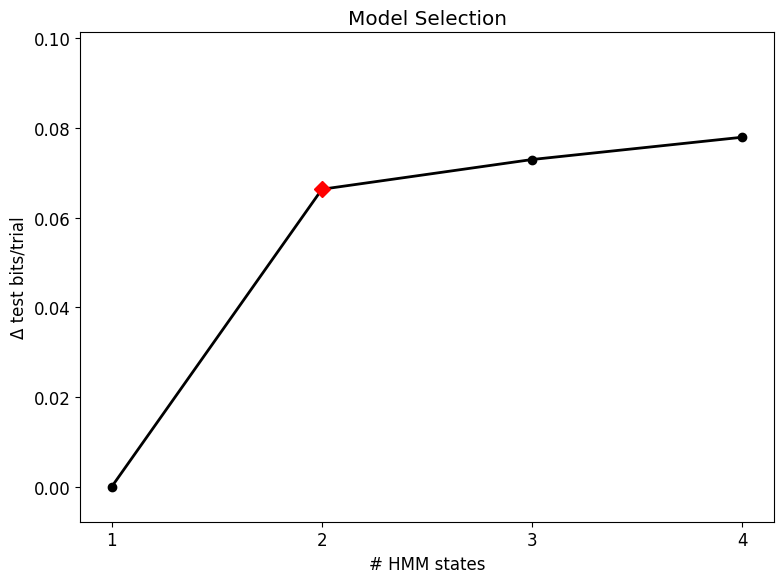

In [76]:
### Plot to be used

fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ vs K=1 curve
ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
        color='black', label='Δ test bits/trial')

# Mark selections

ax.plot(K_1se,  delta_bpt[K_1se - 1],  marker='D', markersize=8, color='red', linestyle='None',
        label=f'1-SE: K={K_1se}')



# y-range
y_min = np.nanmin(delta_bpt)
y_max = np.nanmax(delta_bpt)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test bits/trial')
ax.set_title('Model Selection')
ax.set_xticks(Ks)
ax.grid(False)  # Turn off grid for cleaner look



#ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## separted by Monkey

In [62]:
## separte by monkey

# --- Robust scalar extractor for weird nested numpy/list wrappers ---
def _extract_scalar(x):
    """
    Unwrap values like array(array(['paula'], dtype='<U5'), dtype=object) -> 'paula'
    or array(1235, dtype=uint16) -> 1235.
    Keeps unwrapping while size==1 for np.ndarray or len==1 for lists.
    """
    while True:
        if isinstance(x, np.ndarray):
            if x.shape == ():               # 0-d array
                x = x.item()
            elif x.size == 1:               # 1-element array
                x = x.item()
            else:
                break
        elif isinstance(x, (list, tuple)) and len(x) == 1:
            x = x[0]
        else:
            break
    return x

def get_subject_from_session_meta(sess_meta):
    """
    sess_meta is a dict with numpy arrays, e.g. sess_meta['subject'] is a nested array.
    Returns lowercase subject string.
    """
    if not isinstance(sess_meta, dict):
        raise ValueError("Expected dict in data['session'][i].")
    if 'subject' not in sess_meta:
        raise ValueError("No 'subject' key in data['session'][i].")

    raw = sess_meta['subject']
    subj = _extract_scalar(raw)
    return str(subj).strip().lower()

# --- Verify aligned lengths ---
n_sessions_trial = len(data['trial'])
n_sessions_meta  = len(data['session'])
if n_sessions_trial != n_sessions_meta:
    raise ValueError(f"Length mismatch: data['trial']={n_sessions_trial} vs data['session']={n_sessions_meta}")

# --- Collect indices per subject using data['session'] ---
paula_idx, rex_idx = [], []
for i in range(n_sessions_meta):
    subj = get_subject_from_session_meta(data['session'][i])
    if subj == "paula":
        paula_idx.append(i)
    elif subj == "rex":
        rex_idx.append(i)

print(f"Found {len(paula_idx)} Paula sessions and {len(rex_idx)} Rex sessions.")

# --- Build subject-specific trial DataFrame lists from data['trial'] ---
paula_sessions = [data['trial'][i] for i in paula_idx]
rex_sessions   = [data['trial'][i] for i in rex_idx]

# --- Process per session with your existing function ---
processed_paula = [process_session_data(df) for df in paula_sessions] if paula_sessions else []
processed_rex   = [process_session_data(df) for df in rex_sessions]   if rex_sessions   else []

# --- Prepare GLM-HMM inputs (sessionwise) ---
if processed_paula:
    inpts_paula, choices_paula, lens_paula = prepare_data_for_glmhmm_sessionwise(processed_paula)
    inpts_paula_concat   = [np.concatenate(inpts_paula, axis=0)]
    choices_paula_concat = [np.concatenate(choices_paula, axis=0)]
    input_dim_paula = inpts_paula_concat[0].shape[1]
    print("PAULA — Num sessions:", len(inpts_paula))
    print("PAULA — Trials per session:", lens_paula)
else:
    inpts_paula_concat, choices_paula_concat, lens_paula, input_dim_paula = [], [], [], None
    print("PAULA — No sessions found.")

if processed_rex:
    inpts_rex, choices_rex, lens_rex = prepare_data_for_glmhmm_sessionwise(processed_rex)
    inpts_rex_concat   = [np.concatenate(inpts_rex, axis=0)]
    choices_rex_concat = [np.concatenate(choices_rex, axis=0)]
    input_dim_rex = inpts_rex_concat[0].shape[1]
    print("REX   — Num sessions:", len(inpts_rex))
    print("REX   — Trials per session:", lens_rex)
else:
    inpts_rex_concat, choices_rex_concat, lens_rex, input_dim_rex = [], [], [], None
    print("REX   — No sessions found.")

# --- Shared modeling hyperparameters ---
num_states     = 2
obs_dim        = 1
num_categories = 2
N_iters        = 3000
tolerance      = 10**-0.15

# --- Initialize one HMM per subject (only if that subject exists) ---
models = {}
if input_dim_paula is not None:
    models["paula"] = ssm.HMM(num_states, obs_dim, input_dim_paula,
                              observations="input_driven_obs", transitions="standard")
if input_dim_rex is not None:
    models["rex"] = ssm.HMM(num_states, obs_dim, input_dim_rex,
                            observations="input_driven_obs", transitions="standard")

# Example to fit Paula:
# if "paula" in models:
#     new_glmhmm_paula = models["paula"]
#     # Fit using inpts_paula_concat, choices_paula_concat, lens_paula, N_iters, tolerance, etc.


Found 29 Paula sessions and 16 Rex sessions.
PAULA — Num sessions: 29
PAULA — Trials per session: [1151, 1338, 1082, 1222, 721, 1457, 1511, 1289, 1110, 1227, 1576, 1597, 1291, 1228, 1322, 1338, 986, 1577, 1336, 1493, 1298, 1789, 1579, 1510, 883, 1601, 1224, 1303, 1148]
REX   — Num sessions: 16
REX   — Trials per session: [1381, 1440, 1096, 1457, 969, 1321, 891, 1404, 1164, 1084, 1186, 1084, 1212, 1198, 1020, 1272]


In [65]:
paula_idx


[0,
 1,
 2,
 3,
 6,
 7,
 8,
 11,
 14,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 36,
 40]

In [64]:
rex_idx


[4, 5, 9, 10, 12, 13, 15, 16, 35, 37, 38, 39, 41, 42, 43, 44]

## Model slection for REX

In [135]:
inpts = inpts_paula
true_choices = choices_paula

In [ ]:

LOG2 = np.log(2.0)

def MLE_hmm_fit(num_states, training_inpts, training_choices, test_inpts, test_choices, seed=None):
    """
    Fit a GLM-HMM and return the fitted model + train/test log-likelihood
    in **bits per trial**.
    """
    if seed is not None:
        np.random.seed(seed)

    # Ensure shapes/dtypes
    training_choices = [np.array(y).reshape(-1, 1).astype(int) for y in training_choices]
    test_choices     = [np.array(y).reshape(-1, 1).astype(int) for y in test_choices]

    num_categories = len(np.unique(np.concatenate(training_choices)))
    input_dim = training_inpts[0].shape[1]

    # for 1 state use standard transitions
    if num_states == 1:
        hmm = ssm.HMM(
            K=1,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="standard",
        )
    else:
        # for >1 state use sticky transitions
        hmm = ssm.HMM(
            K=num_states,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="sticky",
            transition_kwargs=dict(alpha=2.0, kappa=0.0),  # hyperparameters
        )

    
    train_lls = hmm.fit(
            training_choices,
            inputs=training_inpts,
            method="em",
            num_iters=3000,
            tolerance=1e-3,
        )

    n_train = np.concatenate(training_inpts).shape[0]
    n_test  = np.concatenate(test_inpts).shape[0]

    # Convert from nats/trial → bits/trial
    train_bpt = (train_lls[-1] / n_train) / LOG2
    test_bpt  = (hmm.log_probability(test_choices, test_inpts) / n_test) / LOG2

    return hmm, train_bpt, test_bpt



# -----------------------------
# TQDM helper for joblib
# -----------------------------
@contextmanager
def tqdm_joblib(tqdm_object):
    from joblib import parallel

    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()


# -----------------------------
# Cross-validated sweep
# -----------------------------
# User-provided:
# true_choices : list of arrays, one per session
# inpts        : list of arrays, one per session
# (Optional) data: list of DataFrames per session (not used anymore)

max_states = 4
nKfold = 5
initializations = 5  # many inits per (fold, K)
kf = KFold(n_splits=nKfold, shuffle=True, random_state=42)

# Pre-allocate containers for the "best-per-fold" models and LLs
Best_HMM = np.full((max_states, nKfold), None, dtype=object)
Best_train_LL = np.full((max_states, nKfold), np.nan, dtype=float)
Best_test_LL = np.full((max_states, nKfold), np.nan, dtype=float)

# Also store all-inits test LLs if you want to inspect dispersion later
AllInits_test_LL = np.full((initializations, max_states, nKfold), np.nan, dtype=float)

# Prepare all jobs: each job = (fold, K, init_seed, train/test splits)
jobs = []
for fold_id, (train_index, test_index) in enumerate(kf.split(true_choices)):
    training_choices = [true_choices[i] for i in train_index]
    test_choices = [true_choices[i] for i in test_index]
    training_inpts = [inpts[i] for i in train_index]
    test_inpts = [inpts[i] for i in test_index]

    # set deterministic seeds per (fold, K, init)
    for K in range(1, max_states + 1):
        for z in range(initializations):
            seed = 10_000 * fold_id + 100 * K + z
            jobs.append((fold_id, K, z, seed, training_inpts, training_choices, test_inpts, test_choices))

# Run all fits in parallel
def _run_one(fold_id, K, z, seed, tr_in, tr_ch, te_in, te_ch):
    hmm, tr_ll, te_ll = MLE_hmm_fit(K, tr_in, tr_ch, te_in, te_ch, seed=seed)
    return fold_id, K, z, hmm, tr_ll, te_ll

with tqdm_joblib(tqdm(total=len(jobs), desc="Fitting GLM-HMMs (CV × K × inits)")):
    results = Parallel(n_jobs=-1, verbose=0)(
        delayed(_run_one)(*args) for args in jobs
    )

# Collect results and pick the best init per (fold, K) by test LL
for fold_id, K, z, hmm, tr_ll, te_ll in results:
    AllInits_test_LL[z, K - 1, fold_id] = te_ll
    # If this is the best so far for (K, fold), update
    if np.isnan(Best_test_LL[K - 1, fold_id]) or te_ll > Best_test_LL[K - 1, fold_id]:
        Best_test_LL[K - 1, fold_id] = te_ll
        Best_train_LL[K - 1, fold_id] = tr_ll
        Best_HMM[K - 1, fold_id] = hmm

# -----------------------------
# Model selection over K
# -----------------------------
def plateau(data_1d, threshold=0.001):
    """
    Given a 1D array of scores over K, return the K at which the last
    improvement above threshold occurs; if none, return 1.
    """
    diffs = np.diff(data_1d)
    ind = np.where(diffs > threshold)[0]
    return ind[np.argmax(data_1d[ind + 1])] + 1 if len(ind) > 0 else 1

# Average test LL across folds for each K using the best-inits
mean_test_LL_by_K = np.nanmean(Best_test_LL, axis=1)  # shape: (max_states,)
selected_num_states = plateau(mean_test_LL_by_K)

# Example: retrieve the best model per fold at the selected K
Kstar = selected_num_states
HMMs_per_fold = [Best_HMM[Kstar - 1, f] for f in range(nKfold)]
TestLL_per_fold = Best_test_LL[Kstar - 1, :]
TrainLL_per_fold = Best_train_LL[Kstar - 1, :]

# If you want a single representative model (e.g., best fold at K*):
best_fold_idx = int(np.nanargmax(TestLL_per_fold))
Best_overall_HMM = HMMs_per_fold[best_fold_idx]


'''
    
        hmm = ssm.HMM(
            K=num_states,
            D=1,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(C=num_categories),
            transitions="standard",
        )
'''

Fitting GLM-HMMs (CV × K × inits):  11%|█████                                         | 11/100 [01:03<19:20, 13.04s/it]


Consecutive K comparisons (Δ bits/trial across folds):
  Pair (K→K+1)  Δ bits/trial  p (sign-flip)  reject Holm (α=0.05)  p_adj Holm
0          1→2      0.047143         0.0625                 False      0.1875
1          2→3     -0.008620         0.0625                 False      0.1875
2          3→4     -0.014003         0.0625                 False      0.1875

Selections:
  • Max mean bits/trial: K* = 2
  • 1-SE rule:           K* = 2
  • Last significant Δ:  K* = 1 (Holm-corrected)


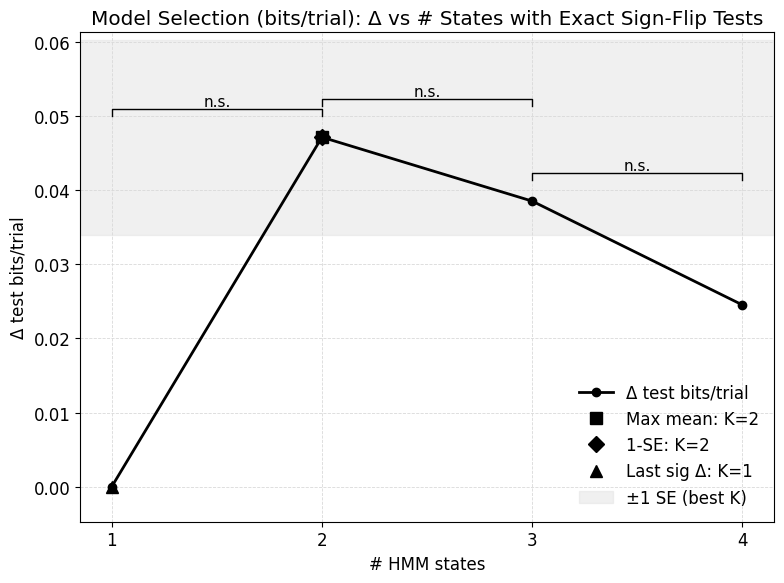

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

# ------------------------------------------------------------
# Inputs expected in scope from your pipeline:
#   - Best_test_LL: shape (max_states, n_folds), values are bits/trial (best init per fold)
#   - max_states: int
#   - nKfold: int (number of folds)
# ------------------------------------------------------------

# ---------- Helper: exact sign-flip permutation test (two-sided) ----------
def sign_flip_pvalue(diffs):
    """
    Exact two-sided sign-flip test for mean of paired differences.
    Works well for tiny sample sizes (e.g., 3 folds).
    diffs: 1D array of per-fold differences (K+1 - K) in bits/trial.
    Returns: p-value in [0,1].
    """
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    n = diffs.size
    if n == 0:
        return np.nan
    # observed statistic: absolute mean
    t_obs = np.abs(np.mean(diffs))
    # enumerate all 2^n sign flips
    # (for n>20 you'd Monte Carlo, but here n is tiny)
    count = 0
    total = 0
    for signs in product([-1.0, 1.0], repeat=n):
        total += 1
        t = np.abs(np.mean(diffs * np.array(signs)))
        if t >= t_obs - 1e-15:
            count += 1
    return count / total

# ---------- Stats over K ----------
mean_bpt = np.nanmean(Best_test_LL, axis=1)                  # (K,)
sem_bpt  = np.nanstd(Best_test_LL, axis=1, ddof=1) / np.sqrt(
    np.sum(np.isfinite(Best_test_LL), axis=1)
)

# Δ bits/trial vs K=1 (for plotting)
delta_bpt = mean_bpt - mean_bpt[0]

# Default (threshold-free): K with max mean bits/trial
K_max = int(np.nanargmax(mean_bpt)) + 1
best_val = mean_bpt[K_max - 1]
best_se  = sem_bpt[K_max - 1]

# 1-SE rule: smallest K whose mean ≥ (best − SE_best)
eligible = np.where(mean_bpt >= (best_val - best_se))[0]
K_1se = int(eligible[0]) + 1 if eligible.size else K_max

# Exact sign-flip tests for consecutive pairs (K -> K+1)
raw_p = []
for k in range(max_states - 1):
    diffs = Best_test_LL[k + 1, :] - Best_test_LL[k, :]  # per-fold Δ bits/trial
    mask = np.isfinite(diffs)
    if np.sum(mask) >= 1:  # need at least 1 fold with finite values
        p = sign_flip_pvalue(diffs[mask])
    else:
        p = np.nan
    raw_p.append(p)

# Holm–Bonferroni correction (more powerful than Bonferroni)
def holm_bonferroni(pvals):
    """
    Returns boolean array 'reject' after Holm correction at alpha=0.05,
    plus adjusted p-values.
    """
    pvals = np.array(pvals, dtype=float)
    m = np.sum(np.isfinite(pvals))
    if m == 0:
        return np.zeros_like(pvals, dtype=bool), pvals
    order = np.argsort(np.where(np.isfinite(pvals), pvals, np.inf))
    reject = np.zeros_like(pvals, dtype=bool)
    adj_p = np.full_like(pvals, np.nan, dtype=float)
    alpha = 0.05
    # step-down procedure
    for rank, idx in enumerate(order, start=1):
        if not np.isfinite(pvals[idx]):
            continue
        threshold = alpha / (m - rank + 1)
        if pvals[idx] <= threshold:
            reject[idx] = True
        # adjusted p-value (Holm) for reporting
        adj_p[idx] = max( (m - rank + 1) * pvals[idx], 0.0 )
    # enforce monotonicity on adjusted p's in sorted order
    # (optional cosmetic; not required for reject decisions)
    last = -np.inf
    for idx in order:
        if np.isfinite(adj_p[idx]):
            adj_p[idx] = max(adj_p[idx], last)
            last = adj_p[idx]
    return reject, adj_p

reject_holm, p_adj_holm = holm_bonferroni(raw_p)

# Choose K by "last significant improvement": pick the largest K such that K-1 -> K is significant
# Then prefer that K; if none significant, pick K=1 (or fall back to 1-SE)
sig_pairs = np.where(reject_holm)[0]  # indices of pairs K->K+1 that are significant
if sig_pairs.size > 0:
    K_last_sig = int(sig_pairs.max() + 2)   # pair index k corresponds to K=k+1
else:
    K_last_sig = 1

# ---------- Report ----------
df_tests = pd.DataFrame({
    "Pair (K→K+1)": [f"{k+1}→{k+2}" for k in range(max_states - 1)],
    "Δ bits/trial": np.round(mean_bpt[1:] - mean_bpt[:-1], 6),
    "p (sign-flip)": np.round(raw_p, 6),
    "reject Holm (α=0.05)": reject_holm,
    "p_adj Holm": np.round(p_adj_holm, 6),
})
print("\nConsecutive K comparisons (Δ bits/trial across folds):")
print(df_tests)

print(f"\nSelections:")
print(f"  • Max mean bits/trial: K* = {K_max}")
print(f"  • 1-SE rule:           K* = {K_1se}")
print(f"  • Last significant Δ:  K* = {K_last_sig} (Holm-corrected)")

# ---------- Plot in black with significance + 1-SE band ----------
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ vs K=1 curve
ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
        color='black', label='Δ test bits/trial')

# Mark selections
ax.plot(K_max,  delta_bpt[K_max - 1],  marker='s', markersize=9, color='black', linestyle='None',
        label=f'Max mean: K={K_max}')
ax.plot(K_1se,  delta_bpt[K_1se - 1],  marker='D', markersize=8, color='black', linestyle='None',
        label=f'1-SE: K={K_1se}')
ax.plot(K_last_sig, delta_bpt[K_last_sig - 1], marker='^', markersize=9, color='black', linestyle='None',
        label=f'Last sig Δ: K={K_last_sig}')

# 1-SE shaded band around best K’s mean (horizontal band at Δ for best K)
best_delta = delta_bpt[K_max - 1]
ax.axhspan(best_delta - best_se, best_delta + best_se, color='0.9', alpha=0.6, label='±1 SE (best K)')

# y-range
y_min = np.nanmin(delta_bpt)
y_max = np.nanmax(delta_bpt)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test bits/trial')
ax.set_title('Model Selection (bits/trial): Δ vs # States with Exact Sign-Flip Tests')
ax.set_xticks(Ks)

# significance helpers
def sig_label_from_p(p):
    if not np.isfinite(p): return "n.s."
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def add_sig_bracket(ax, x1, x2, y, h, text, weight=False):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.3 if weight else 1.0, c='black')
    ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom', fontsize=11, color='black')

# draw brackets between consecutive K’s using *adjusted* p-values for labeling
base_offset = 0.06 * y_range
stack_step  = 0.03 * y_range
h_bracket   = 0.02 * y_range
for k in range(max_states - 1):
    x1, x2 = k + 1, k + 2
    pair_top = np.nanmax([delta_bpt[k], delta_bpt[k + 1]])
    y = pair_top + base_offset + (k % 2) * stack_step
    lbl = sig_label_from_p(p_adj_holm[k])  # label by Holm-adjusted p
    add_sig_bracket(ax, x1, x2, y, h_bracket, lbl, weight=reject_holm[k])

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

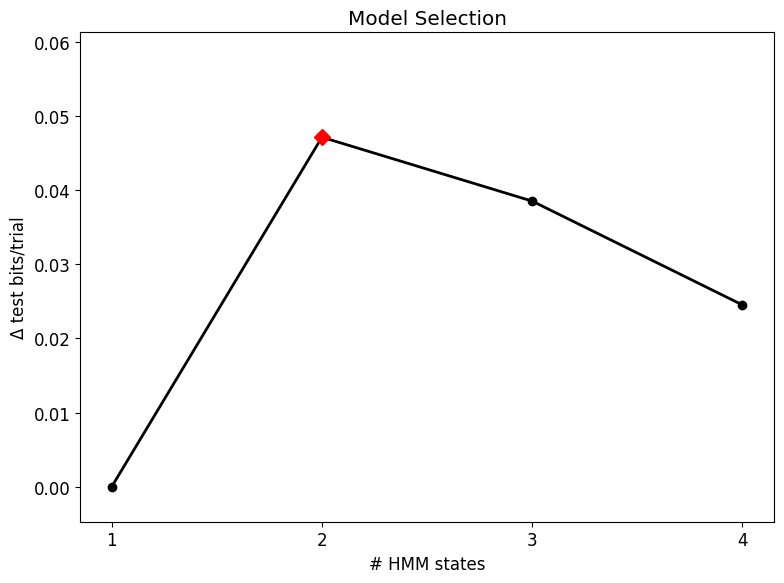

In [133]:
### Plot to be used

fig, ax = plt.subplots(figsize=(8, 6))
Ks = np.arange(1, max_states + 1)

# Δ vs K=1 curve
ax.plot(Ks, delta_bpt, marker='o', linestyle='-', linewidth=2, markersize=6,
        color='black', label='Δ test bits/trial')

# Mark selections

ax.plot(K_1se,  delta_bpt[K_1se - 1],  marker='D', markersize=8, color='red', linestyle='None',
        label=f'1-SE: K={K_1se}')



# y-range
y_min = np.nanmin(delta_bpt)
y_max = np.nanmax(delta_bpt)
if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
    y_min, y_max = 0.0, 1.0
y_range = max(y_max - y_min, 1e-6)
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

ax.set_xlabel('# HMM states')
ax.set_ylabel('Δ test bits/trial')
ax.set_title('Model Selection')
ax.set_xticks(Ks)
ax.grid(False)  # Turn off grid for cleaner look



#ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [134]:
#let's save the results for rex
with open('rex_model_selection_results.pkl', 'wb') as f:
    pickle.dump({
        'Best_HMM': Best_HMM,
        'Best_train_LL': Best_train_LL,
        'Best_test_LL': Best_test_LL,
        'AllInits_test_LL': AllInits_test_LL,
        'mean_test_LL_by_K': mean_test_LL_by_K,
        'selected_num_states': selected_num_states,
        'Kstar_models': HMMs_per_fold,
        'Kstar_train_bpt': TrainLL_per_fold,
        'Kstar_test_bpt': TestLL_per_fold,
        'Best_overall_HMM': Best_overall_HMM
    }, f)

In [126]:
# let's save the results for paula
with open('paula_model_selection_results.pkl', 'wb') as f:
    pickle.dump({
        'Best_HMM': Best_HMM,
        'Best_train_LL': Best_train_LL,
        'Best_test_LL': Best_test_LL,
        'AllInits_test_LL': AllInits_test_LL,
        'mean_test_LL_by_K': mean_test_LL_by_K,
        'selected_num_states': selected_num_states,
        'Kstar_models': HMMs_per_fold,
        'Kstar_train_bpt': TrainLL_per_fold,
        'Kstar_test_bpt': TestLL_per_fold,
        'Best_overall_HMM': Best_overall_HMM
    }, f)

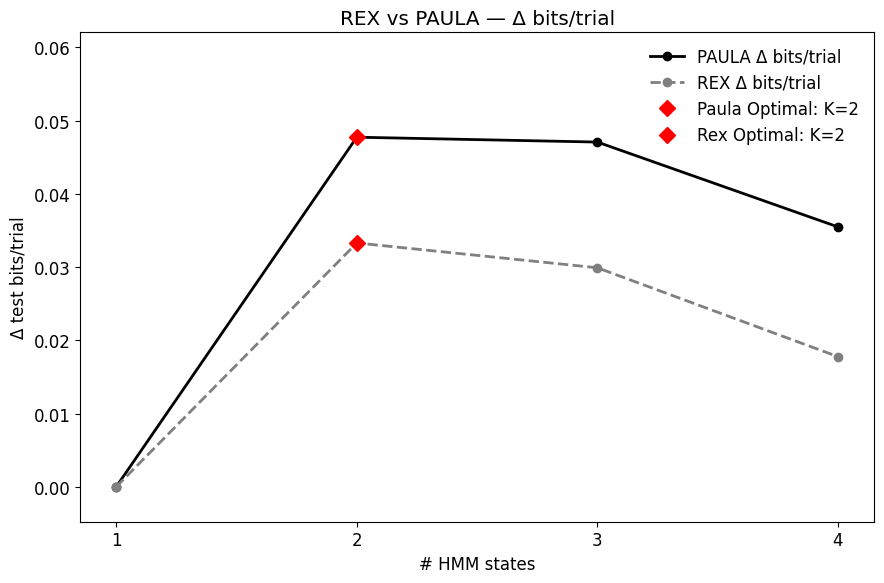

Ks: [1 2 3 4]
PAULA 1-SE K: 2
REX   1-SE K: 2


In [129]:
##
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

def plot_two_subjects_model_selection(
    rex_pkl: str,
    paula_pkl: str,
    *,
    title: str = "Model Selection (Δ bits/trial) — REX vs PAULA",
    show: bool = True
):
    """
    Load model-selection result pickles for REX and PAULA, compute Δ bits/trial vs K=1,
    compute 1-SE selection per subject, and plot both curves on one figure.

    Parameters
    ----------
    rex_pkl : str
        Path to REX results pickle (as saved in your code).
    paula_pkl : str
        Path to PAULA results pickle (as saved in your code).
    title : str
        Plot title.
    show : bool
        Whether to call plt.show().

    Returns
    -------
    fig, ax, out : (Figure, Axes, dict)
        out = {
            "Ks": np.ndarray,
            "rex":  {"mean": ..., "sem": ..., "delta": ..., "K_1se": int},
            "paula":{"mean": ..., "sem": ..., "delta": ..., "K_1se": int},
        }
    """
    def _load(p):
        if not os.path.exists(p):
            raise FileNotFoundError(f"Pickle not found: {p}")
        with open(p, "rb") as f:
            return pickle.load(f)

    def _extract_stats(d):
        """
        Robustly compute mean/SEM across folds from the saved dict.
        Prefers 'Best_test_LL' (bits/trial per (K, fold)).
        Falls back to 'mean_test_LL_by_K' if needed (then SEM is NaN).
        """
        if "Best_test_LL" in d and isinstance(d["Best_test_LL"], np.ndarray):
            best = d["Best_test_LL"].astype(float)  # shape: (K, n_folds)
            mean = np.nanmean(best, axis=1)
            counts = np.sum(np.isfinite(best), axis=1)
            sem = np.nanstd(best, axis=1, ddof=1) / np.sqrt(np.maximum(counts, 1))
        elif "Best_test_bpt" in d and isinstance(d["Best_test_bpt"], np.ndarray):
            best = d["Best_test_bpt"].astype(float)
            mean = np.nanmean(best, axis=1)
            counts = np.sum(np.isfinite(best), axis=1)
            sem = np.nanstd(best, axis=1, ddof=1) / np.sqrt(np.maximum(counts, 1))
        elif "mean_test_LL_by_K" in d and isinstance(d["mean_test_LL_by_K"], np.ndarray):
            mean = d["mean_test_LL_by_K"].astype(float)   # (K,)
            sem = np.full_like(mean, np.nan, dtype=float) # unknown without per-fold values
        else:
            raise KeyError("Could not find 'Best_test_LL' or 'mean_test_LL_by_K' in results dict.")

        delta = mean - mean[0]  # Δ vs K=1
        # 1-SE rule
        K_max = int(np.nanargmax(mean)) + 1
        best_val = mean[K_max - 1]
        best_se  = sem[K_max - 1] if np.isfinite(sem[K_max - 1]) else 0.0
        eligible = np.where(mean >= (best_val - best_se))[0]
        K_1se = int(eligible[0]) + 1 if eligible.size else K_max
        return mean, sem, delta, K_1se

    # Load
    rex_d    = _load(rex_pkl)
    paula_d  = _load(paula_pkl)

    # Stats
    rex_mean,   rex_sem,   rex_delta,   rex_K1 = _extract_stats(rex_d)
    paula_mean, paula_sem, paula_delta, paula_K1 = _extract_stats(paula_d)

    # Align K range (use the minimum shared K if they differ)
    K_rex   = rex_mean.shape[0]
    K_paula = paula_mean.shape[0]
    Kmin    = min(K_rex, K_paula)
    Ks      = np.arange(1, Kmin + 1)

    rex_delta   = rex_delta[:Kmin]
    paula_delta = paula_delta[:Kmin]

    # Plot (clean, minimal)
    fig, ax = plt.subplots(figsize=(9, 6))

    # Curves
    ax.plot(Ks, paula_delta, marker='o', linestyle='-', linewidth=2, markersize=6,
            color='black', label='PAULA Δ bits/trial')
    ax.plot(Ks, rex_delta, marker='o', linestyle='--', linewidth=2, markersize=6,
            color='gray', label='REX Δ bits/trial')

    # 1-SE markers
    if 1 <= paula_K1 <= Kmin:
        ax.plot(paula_K1, paula_delta[paula_K1 - 1], marker='D', markersize=8,
                linestyle='None', color='red', label=f'Paula Optimal: K={paula_K1}')  # ULA 1-SE
    if 1 <= rex_K1 <= Kmin:
        ax.plot(rex_K1, rex_delta[rex_K1 - 1], marker='D', markersize=8,
                linestyle='None', color='red', label=f'Rex Optimal: K={rex_K1}')

    # Axes & style
    y_min = np.nanmin([np.nanmin(rex_delta), np.nanmin(paula_delta)])
    y_max = np.nanmax([np.nanmax(rex_delta), np.nanmax(paula_delta)])
    if not np.isfinite(y_min) or not np.isfinite(y_max) or y_min == y_max:
        y_min, y_max = 0.0, 1.0
    y_range = max(y_max - y_min, 1e-6)
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.3 * y_range)

    ax.set_xlabel('# HMM states')
    ax.set_ylabel('Δ test bits/trial')
    ax.set_title(title)
    ax.set_xticks(Ks)
    ax.grid(False)
    ax.legend(frameon=False)
    plt.tight_layout()

    if show:
        plt.show()

    return fig, ax, {
        "Ks": Ks,
        "rex":   {"mean": rex_mean[:Kmin], "sem": rex_sem[:Kmin], "delta": rex_delta, "K_1se": rex_K1},
        "paula": {"mean": paula_mean[:Kmin], "sem": paula_sem[:Kmin], "delta": paula_delta, "K_1se": paula_K1},
    }
fig, ax, out = plot_two_subjects_model_selection(
    "rex_model_selection_results.pkl",
    "paula_model_selection_results.pkl",
    title="REX vs PAULA — Δ bits/trial"
)

print("Ks:", out["Ks"])
print("PAULA 1-SE K:", out["paula"]["K_1se"])
print("REX   1-SE K:", out["rex"]["K_1se"])
